# Segment-Level Analysis — New Toy Model Validation

Validate the `lhcb_velo_toy` package ([github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model))
at the **segment level**, replicating the analysis from `track_density_test_local.ipynb`.

**Key questions:**
1. Do true segment-pair angles cluster near zero, well below the $\varepsilon$ threshold?
2. How does the true/false angle separation change with $\sigma_{\mathrm{scatt}}$ and $\sigma_{\mathrm{res}}$?
3. What fraction of true pairs are accepted ($\theta \le \varepsilon$) vs false pairs that leak in?
4. How does segment-level performance degrade with increasing track multiplicity?

**Fixed parameters**: $\gamma = 3$, $\delta = 1.0$, scale $= 3.0$,
$\theta_{\mathrm{min}} = 1.5 \times 10^{-5}$ rad, 5 modules, $\Delta z = 33$ mm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy.solvers import SimpleHamiltonianFast, get_tracks
from lhcb_velo_toy.analysis import EventValidator

OUT_DIR = Path("outputs/segment_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUT_DIR / "cache"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("All imports successful.")


All imports successful.


## 1. Constants & Detector Geometry

In [2]:
# ── Detector ──────────────────────────────────────────────────────
DZ_MM     = 33.0
N_MODULES = 5
Z_FIRST   = 33              # matches reference notebook
HALF_X    = 40.0             # 80 mm full module (reference)
HALF_Y    = 40.0

# ── Hamiltonian / reconstruction ─────────────────────────────────
GAMMA     = 3.0
DELTA     = 1.0
SCALE     = 3.0
THETA_MIN = 1.5e-5

# ── Angular cone settings ────────────────────────────────────────
ANGLE_SETTINGS = [0.02, 0.2]

# ── Primary vertex spread ────────────────────────────────────────
PV_SIGMA  = {"x": 0, "y": 0, "z": 1}   # reference notebook values

# ── Build geometry ───────────────────────────────────────────────
z_positions = [Z_FIRST + i * DZ_MM for i in range(N_MODULES)]
geo = PlaneGeometry(
    module_id=list(range(N_MODULES)),
    lx=[HALF_X] * N_MODULES,
    ly=[HALF_Y] * N_MODULES,
    z=z_positions,
)

print(f"Detector: {N_MODULES} modules at z = {z_positions} mm")
print(f"Scale = {SCALE}, θ_min = {THETA_MIN}")

Detector: 5 modules at z = [33.0, 66.0, 99.0, 132.0, 165.0] mm
Scale = 3.0, θ_min = 1.5e-05


## 2. Helper Functions

In [3]:
def compute_epsilon(sigma_res, sigma_scatt, dz=DZ_MM, scale=SCALE,
                    theta_min=THETA_MIN):
    """Angular acceptance threshold: epsilon = sqrt(2*theta_s^2 + 12*theta_r^2 + 2*theta_min^2)."""
    theta_s = scale * sigma_scatt
    theta_r = np.arctan((scale * sigma_res) / dz) if dz != 0 else 0.0
    return float(np.sqrt(2 * theta_s**2 + 12 * theta_r**2 + 2 * theta_min**2))


def safe_generate(n_tracks, measurement_error=0.0, collision_noise=1e-8,
                  phi_max=0.2, theta_max=0.2, max_retries=20):
    """Generate event, retrying until every track has >= 3 hits."""
    for _ in range(max_retries):
        gen = StateEventGenerator(
            detector_geometry=geo,
            events=1,
            n_particles=[n_tracks],
            phi_min=-phi_max, phi_max=phi_max,
            theta_min=-theta_max, theta_max=theta_max,
            measurement_error=measurement_error,
            collision_noise=collision_noise,
        )
        gen.generate_random_primary_vertices(PV_SIGMA)
        gen.generate_particles(
            [[{"type": "pion", "mass": 139.6, "q": 1}] * n_tracks]
        )
        event = gen.generate_complete_events()
        if event.tracks and min(len(t.hit_ids) for t in event.tracks) >= 3:
            return event
    return event  # best effort


def pairwise_angle(h_prev, h_mid, h_next):
    """Angle between segments (prev->mid) and (mid->next)."""
    v1 = np.array([h_mid.x - h_prev.x, h_mid.y - h_prev.y, h_mid.z - h_prev.z])
    v2 = np.array([h_next.x - h_mid.x, h_next.y - h_mid.y, h_next.z - h_mid.z])
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    cos_a = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return float(np.arccos(cos_a))


def collect_segment_pair_angles(event):
    """Collect pairwise angles for ALL segment pairs sharing a middle hit.

    For each middle hit in module i, considers all incoming segments from
    module i-1 and all outgoing segments to module i+1. A pair is 'true'
    if both segments belong to the same truth track.

    Returns (true_angles, false_angles) as lists of floats (radians).
    """
    # Build set of true segments from truth tracks
    true_seg_set = set()
    for trk in event.tracks:
        hids = trk.hit_ids
        for k in range(len(hids) - 1):
            true_seg_set.add((hids[k], hids[k + 1]))

    # Group hits by module
    hits_by_module = {}
    for h in event.hits:
        hits_by_module.setdefault(h.module_id, []).append(h)
    sorted_mod_ids = sorted(hits_by_module.keys())

    true_angles = []
    false_angles = []

    # For each middle module, iterate all (prev, mid, next) triplets
    for mi in range(1, len(sorted_mod_ids) - 1):
        mod_prev = sorted_mod_ids[mi - 1]
        mod_mid  = sorted_mod_ids[mi]
        mod_next = sorted_mod_ids[mi + 1]

        for h_mid in hits_by_module[mod_mid]:
            for h_prev in hits_by_module[mod_prev]:
                seg_in_true = (h_prev.hit_id, h_mid.hit_id) in true_seg_set
                for h_next in hits_by_module[mod_next]:
                    seg_out_true = (h_mid.hit_id, h_next.hit_id) in true_seg_set
                    angle = pairwise_angle(h_prev, h_mid, h_next)
                    # True pair = both segments from same truth track
                    if (seg_in_true and seg_out_true and
                            h_prev.track_id is not None and
                            h_prev.track_id == h_mid.track_id == h_next.track_id):
                        true_angles.append(angle)
                    else:
                        false_angles.append(angle)

    return true_angles, false_angles


def compute_segment_metrics(true_angles, false_angles, epsilon):
    """Compute segment-level acceptance metrics for a given epsilon threshold."""
    true_arr  = np.array(true_angles)
    false_arr = np.array(false_angles)

    n_true  = len(true_arr)
    n_false = len(false_arr)

    true_accepted  = int(np.sum(true_arr <= epsilon))  if n_true > 0  else 0
    false_accepted = int(np.sum(false_arr <= epsilon)) if n_false > 0 else 0
    total_accepted = true_accepted + false_accepted

    segment_efficiency = true_accepted / n_true if n_true > 0 else 0.0
    segment_false_rate = false_accepted / total_accepted if total_accepted > 0 else 0.0

    return {
        "n_true": n_true,
        "n_false": n_false,
        "true_accepted": true_accepted,
        "false_accepted": false_accepted,
        "segment_efficiency": segment_efficiency,
        "segment_false_rate": segment_false_rate,
    }


def se(a):
    """Standard error of the mean (Bessel-corrected)."""
    return np.std(a, ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0


print("Helper functions defined.")

Helper functions defined.


## 2b. Numba-Accelerated Segment Metrics Kernel

Drop-in replacement for `collect_segment_pair_angles` + `compute_segment_metrics`.
Uses Numba JIT compilation with parallel execution for ~100× speedup on the O(T³)
triplet enumeration. Validated against the pure-Python reference implementation below.

In [4]:
# ============================================================================
# Numba-Accelerated Segment Metrics Kernel
# ============================================================================
import math
from numba import njit, prange

@njit
def _cos_angle_inner(v1x, v1y, v1z, n1, v2x, v2y, v2z):
    """Cosine of angle between two vectors; v1 already has norm n1."""
    n2 = math.sqrt(v2x * v2x + v2y * v2y + v2z * v2z)
    if n1 == 0.0 or n2 == 0.0:
        return 1.0
    c = (v1x * v2x + v1y * v2y + v1z * v2z) / (n1 * n2)
    return max(-1.0, min(1.0, c))


@njit
def _count_one_mid(i, px, py, pz, mx, my, mz, nx_, ny, nz,
                   p_tid, m_tid, n_tid, cos_eps):
    """Count true/false/accepted for a single middle-hit index i."""
    loc_nt = 0
    loc_nf = 0
    loc_ta = 0
    loc_fa = 0
    mid_tid = m_tid[i]
    for j in range(len(px)):
        v1x = mx[i] - px[j]
        v1y = my[i] - py[j]
        v1z = mz[i] - pz[j]
        n1 = math.sqrt(v1x * v1x + v1y * v1y + v1z * v1z)
        seg_in_true = (p_tid[j] >= 0) and (p_tid[j] == mid_tid)
        for k in range(len(nx_)):
            v2x = nx_[k] - mx[i]
            v2y = ny[k] - my[i]
            v2z = nz[k] - mz[i]
            ca = _cos_angle_inner(v1x, v1y, v1z, n1, v2x, v2y, v2z)
            is_true = seg_in_true and (mid_tid == n_tid[k])
            if is_true:
                loc_nt += 1
                if ca >= cos_eps:
                    loc_ta += 1
            else:
                loc_nf += 1
                if ca >= cos_eps:
                    loc_fa += 1
    return loc_nt, loc_nf, loc_ta, loc_fa


@njit(parallel=True)
def _segment_counts_module(px, py, pz, mx, my, mz, nx_, ny, nz,
                           p_tid, m_tid, n_tid, cos_eps):
    """Count true/false & accepted triplets for one middle module."""
    n_m = len(mx)
    nt_arr = np.zeros(n_m, dtype=np.int64)
    nf_arr = np.zeros(n_m, dtype=np.int64)
    ta_arr = np.zeros(n_m, dtype=np.int64)
    fa_arr = np.zeros(n_m, dtype=np.int64)

    for i in prange(n_m):
        _nt, _nf, _ta, _fa = _count_one_mid(
            i, px, py, pz, mx, my, mz, nx_, ny, nz,
            p_tid, m_tid, n_tid, cos_eps)
        nt_arr[i] = _nt
        nf_arr[i] = _nf
        ta_arr[i] = _ta
        fa_arr[i] = _fa

    return nt_arr.sum(), nf_arr.sum(), ta_arr.sum(), fa_arr.sum()


def fast_segment_metrics(event, epsilon):
    """Drop-in replacement for collect_segment_pair_angles + compute_segment_metrics.

    Returns the same dict as compute_segment_metrics but runs ~100x faster via Numba.
    """
    cos_eps = math.cos(epsilon)

    # Group hits by module
    hits_by_mod = {}
    for h in event.hits:
        hits_by_mod.setdefault(h.module_id, []).append(h)
    sorted_mods = sorted(hits_by_mod.keys())

    # Convert to numpy arrays per module
    def _arrays(hlist):
        x = np.array([h.x for h in hlist], dtype=np.float64)
        y = np.array([h.y for h in hlist], dtype=np.float64)
        z = np.array([h.z for h in hlist], dtype=np.float64)
        tid = np.array([h.track_id if h.track_id is not None else -1
                        for h in hlist], dtype=np.int64)
        return x, y, z, tid

    mod_arrays = {m: _arrays(hits_by_mod[m]) for m in sorted_mods}

    n_true = n_false = true_accepted = false_accepted = 0
    for mi in range(1, len(sorted_mods) - 1):
        prev = mod_arrays[sorted_mods[mi - 1]]
        mid  = mod_arrays[sorted_mods[mi]]
        nxt  = mod_arrays[sorted_mods[mi + 1]]
        nt, nf, ta, fa = _segment_counts_module(
            prev[0], prev[1], prev[2],
            mid[0],  mid[1],  mid[2],
            nxt[0],  nxt[1],  nxt[2],
            prev[3], mid[3],  nxt[3],
            cos_eps,
        )
        n_true += nt
        n_false += nf
        true_accepted += ta
        false_accepted += fa

    total_accepted = true_accepted + false_accepted
    seg_eff = true_accepted / n_true if n_true > 0 else 0.0
    seg_fr  = false_accepted / total_accepted if total_accepted > 0 else 0.0

    return {
        "n_true": int(n_true),
        "n_false": int(n_false),
        "true_accepted": int(true_accepted),
        "false_accepted": int(false_accepted),
        "segment_efficiency": seg_eff,
        "segment_false_rate": seg_fr,
    }


# -- Warm-up JIT & validate against pure-Python --
_warmup = safe_generate(10, measurement_error=0.0, collision_noise=1e-4,
                        phi_max=0.2, theta_max=0.2)
_eps = compute_epsilon(0.0, 1e-4)
_m_fast = fast_segment_metrics(_warmup, _eps)

_ta_py, _fa_py = collect_segment_pair_angles(_warmup)
_m_py = compute_segment_metrics(_ta_py, _fa_py, _eps)

print("Numba JIT compiled & validated:")
for k in ["n_true", "n_false", "true_accepted", "false_accepted"]:
    match = "OK" if _m_fast[k] == _m_py[k] else "MISMATCH"
    print(f"  {k:20s}: fast={_m_fast[k]:6d}  py={_m_py[k]:6d}  {match}")
print(f"  seg_efficiency     : fast={_m_fast['segment_efficiency']:.6f}  py={_m_py['segment_efficiency']:.6f}")
print(f"  seg_false_rate     : fast={_m_fast['segment_false_rate']:.6f}  py={_m_py['segment_false_rate']:.6f}")

Numba JIT compiled & validated:
  n_true              : fast=    30  py=    30  OK
  n_false             : fast=  2970  py=  2970  OK
  true_accepted       : fast=    30  py=    30  OK
  false_accepted      : fast=     0  py=     0  OK
  seg_efficiency     : fast=1.000000  py=1.000000
  seg_false_rate     : fast=0.000000  py=0.000000


## Experiment Overview

All experiments share the same **global geometry**:

| Parameter | Value |
|-----------|-------|
| Module spacing (Δz) | 33.0 mm |
| N modules | 5 |
| Z positions | [33, 66, 99, 132, 165] mm |
| Module half-width (x, y) | 40.0 mm × 40.0 mm |
| PV σ | x = 0, y = 0, z = 1 mm |
| θ_min | 1.5 × 10⁻⁵ rad |
| Scale factor (ε formula) | 3.0 |

The **ε formula** computes the acceptance threshold as:

$$\varepsilon = \sqrt{2\,(\text{scale}\cdot\sigma_s)^2 \;+\; 12\,\arctan^2\!\left(\frac{\text{scale}\cdot\sigma_{\text{res}}}{\Delta z}\right) \;+\; 2\,\theta_{\min}^2}$$

where $\theta_s = \text{scale} \cdot \sigma_s$ and $\theta_r = \arctan(\text{scale} \cdot \sigma_{\text{res}} / \Delta z)$.
See `compute_epsilon()` in §2 for the implementation.

---

### Standard-Range Experiments (§3–§11)

| § | Experiment | Sweep | n_tracks | σ_scatt (rad) | σ_res (mm) | φ_max = θ_max | ε Mode | Events / Repeats |
|---|-----------|-------|----------|---------------|------------|---------------|--------|-----------------|
| 3 | Single-event baseline | — (single point) | 20 | 1 × 10⁻⁴ | 0.0 | 0.02 | Formula | 1 |
| 4 | Scattering histograms | σ_scatt | 20 | [0.05 – 1.0] mrad (7 values) | 0.0 | 0.02 | Formula | 10 |
| 5 | Scattering efficiency | σ_scatt × n_tracks × φ | [10, 20, 50, 100] | [0.05 – 1.0] mrad (7 values) | 0.0 | [0.02, 0.2] | Formula | 10 |
| 6 | Resolution sweep | σ_res × n_tracks × φ | [10, 20, 50, 100] | 1 × 10⁻⁴ (fixed) | [0.0 – 0.05] (7 values) | [0.02, 0.2] | Formula | 10 |
| 7 | Density scan | n_tracks | 5–100 (step 5) | 1 × 10⁻⁴ | 0.0 | 0.2 | Formula | 5 |
| 8 | ROC acceptance curves | threshold (0–10 mrad) | 20 | [0.05 – 1.0] mrad (7 values) | 0.0 | 0.2 | Formula (marks operating pts) | 10 |
| 10 | Fixed-epsilon | n_tracks | [20 – 180, step 20] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 10b | Old-params comparison | n_tracks | [20 – 180, step 20] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 11 | Zero-noise benchmark | n_tracks × regime | 5–100 (step 5) | ≈ 0 (1 × 10⁻⁸) | 0.0 | dense: 0.02, non-dense: 0.2 | Formula (≈ √2·θ_min) | 20 |

### Extended-Range Experiments (§12, Numba-accelerated)

| § | Experiment | Extends | n_tracks | σ_scatt (rad) | σ_res (mm) | φ_max = θ_max | ε Mode | Events / Repeats |
|---|-----------|---------|----------|---------------|------------|---------------|--------|-----------------|
| 12e | Ext. fixed-epsilon (single-event) | — | [20–180 step 20] + [200–1000 step 100] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 12c | Ext. resolution sweep | §6 | [10, 20, 50, 100, 200, 500, 1000] | 1 × 10⁻⁴ (fixed) | [0.0 – 0.05] (7 values) | [0.02, 0.2] | Formula | 10 |
| 12d | Ext. density scan | §7 | 5–100 (step 5) + 150–1000 (step 50) | 1 × 10⁻⁴ | 0.0 | 0.2 | Formula | 5 |
| 12e | Ext. fixed-epsilon | §10 | [20–180 step 20] + [200–1000 step 100] | 1 × 10⁻⁴ | 0.005 | 0.2 | **Fixed (2.0 mrad)** | 20 |
| 12f | Ext. zero-noise | §11 | 5–100 (step 5) + 150–1000 (step 50) | ≈ 0 | 0.0 | dense: 0.02, non-dense: 0.2 | Formula (≈ √2·θ_min) | 20 |

**Shared sweep values:**

- `SIGMA_SCATT_VALUES` = [0.5×10⁻⁴, 1×10⁻⁴, 2×10⁻⁴, 4×10⁻⁴, 6×10⁻⁴, 8×10⁻⁴, 1×10⁻³] rad = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0] mrad- `ANGLE_SETTINGS` = [0.02, 0.2] rad
- `SIGMA_RES_VALUES` = [0.0, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05] mm

## 3. Single-Event Baseline

Generate one clean event and display segment-level metrics.

| Parameter | Value |
|-----------|-------|
| n_tracks | 20 |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.02 rad |
| ε mode | **Formula** |
| Sweep | None (single event) |

Event: 20 tracks, 100 hits
True pairs: 60, False pairs: 23940
Epsilon: 0.425 mrad


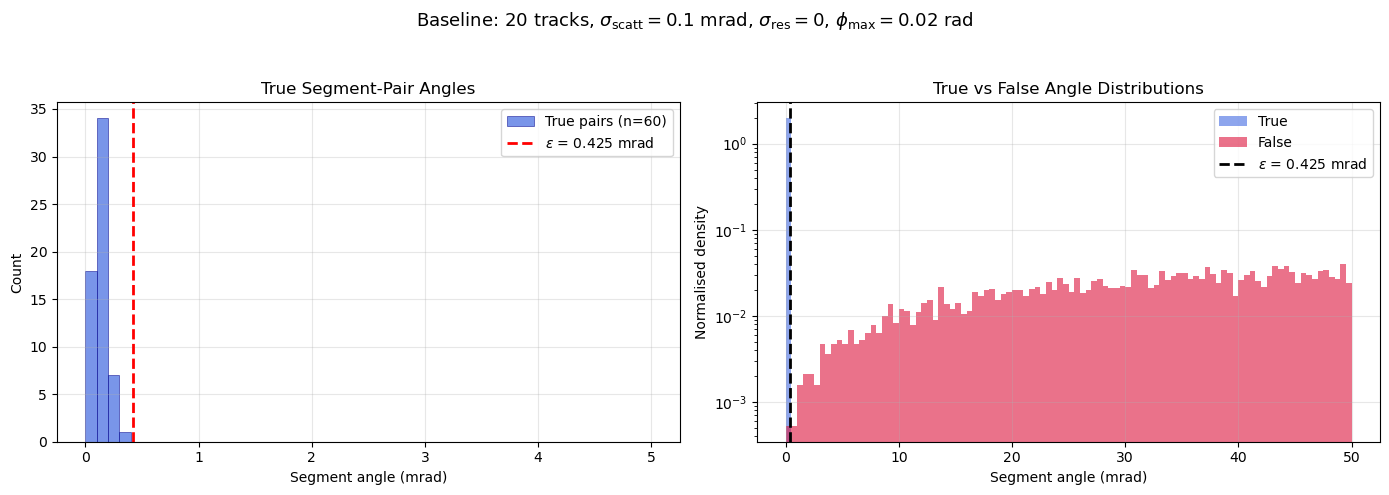


Segment efficiency: 1.000
Segment false rate: 0.016
True accepted: 60/60
False accepted: 1/23940


In [5]:
# ── Low-noise baseline: 20 tracks, small angular cone ────────────
np.random.seed(42)
event_clean = safe_generate(20, measurement_error=0.0, collision_noise=1e-4,
                            phi_max=0.02, theta_max=0.02)
true_angles_clean, false_angles_clean = collect_segment_pair_angles(event_clean)
epsilon_clean = compute_epsilon(0.0, 1e-4)

print(f"Event: {len(event_clean.tracks)} tracks, {len(event_clean.hits)} hits")
print(f"True pairs: {len(true_angles_clean)}, False pairs: {len(false_angles_clean)}")
print(f"Epsilon: {epsilon_clean*1e3:.3f} mrad")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# True angles
bins = np.linspace(0, 5, 51)
ax1.hist(np.array(true_angles_clean) * 1e3, bins=bins, alpha=0.7,
         color='royalblue', edgecolor='darkblue', linewidth=0.5,
         label=f'True pairs (n={len(true_angles_clean)})')
ax1.axvline(epsilon_clean * 1e3, color='red', linestyle='--', linewidth=2,
            label=rf'$\varepsilon$ = {epsilon_clean*1e3:.3f} mrad')
ax1.set_xlabel('Segment angle (mrad)')
ax1.set_ylabel('Count')
ax1.set_title('True Segment-Pair Angles')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Both: true vs false overlap
bins_wide = np.linspace(0, 50, 101)
ax2.hist(np.array(true_angles_clean) * 1e3, bins=bins_wide, alpha=0.6,
         color='royalblue', density=True, label='True')
ax2.hist(np.array(false_angles_clean) * 1e3, bins=bins_wide, alpha=0.6,
         color='crimson', density=True, label='False')
ax2.axvline(epsilon_clean * 1e3, color='black', linestyle='--', linewidth=2,
            label=rf'$\varepsilon$ = {epsilon_clean*1e3:.3f} mrad')
ax2.set_xlabel('Segment angle (mrad)')
ax2.set_ylabel('Normalised density')
ax2.set_title('True vs False Angle Distributions')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

fig.suptitle(r'Baseline: 20 tracks, $\sigma_{\mathrm{scatt}}=0.1$ mrad, '
             r'$\sigma_{\mathrm{res}}=0$, $\phi_{\max}=0.02$ rad', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(OUT_DIR / 'baseline_angle_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

metrics_clean = compute_segment_metrics(true_angles_clean, false_angles_clean, epsilon_clean)
print(f"\nSegment efficiency: {metrics_clean['segment_efficiency']:.3f}")
print(f"Segment false rate: {metrics_clean['segment_false_rate']:.3f}")
print(f"True accepted: {metrics_clean['true_accepted']}/{metrics_clean['n_true']}")
print(f"False accepted: {metrics_clean['false_accepted']}/{metrics_clean['n_false']}")

## 4. Scattering Angle Histograms

True- and false-pair angle distributions for varying σ_scatt, with ε threshold overlay.

| Parameter | Value |
|-----------|-------|
| Swept | σ_scatt ∈ [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0] mrad |
| n_tracks | 20 |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.02 rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [6]:
SIGMA_SCATT_VALUES = [0.5e-4, 1e-4, 2e-4, 4e-4, 6e-4, 8e-4, 1e-3]
N_TRACKS_HIST = 20
N_EVENTS_HIST = 10
PHI_MAX_HIST  = 0.02

_cache_file = CACHE_DIR / "scatt_angle_results.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        scatt_angle_results = pickle.load(f)
    print(f"Loaded {len(scatt_angle_results)} scattering histogram results from cache")
else:
    scatt_angle_results = []

    for si, sigma_s in enumerate(SIGMA_SCATT_VALUES):
        epsilon = compute_epsilon(0.0, sigma_s)
        all_true, all_false = [], []

        for ev_i in range(N_EVENTS_HIST):
            np.random.seed(si * 1000 + ev_i)
            event = safe_generate(N_TRACKS_HIST, measurement_error=0.0,
                                  collision_noise=sigma_s,
                                  phi_max=PHI_MAX_HIST, theta_max=PHI_MAX_HIST)
            ta, fa = collect_segment_pair_angles(event)
            all_true.extend(ta)
            all_false.extend(fa)

        metrics = compute_segment_metrics(all_true, all_false, epsilon)
        scatt_angle_results.append({
            "sigma_scatt": sigma_s,
            "sigma_scatt_mrad": sigma_s * 1e3,
            "epsilon": epsilon,
            "true_angles": np.array(all_true),
            "false_angles": np.array(all_false),
            **metrics,
        })

        print(f"  sigma_scatt={sigma_s*1e3:.2f} mrad  eps={epsilon*1e3:.3f} mrad  "
              f"seg_eff={metrics['segment_efficiency']:.3f}  "
              f"false_rate={metrics['segment_false_rate']:.3f}  "
              f"true={metrics['n_true']}  false={metrics['n_false']}")

    with open(_cache_file, "wb") as f:
        pickle.dump(scatt_angle_results, f)
    print(f"\nDone & saved: {len(scatt_angle_results)} scattering values x {N_EVENTS_HIST} events")

Loaded 7 scattering histogram results from cache


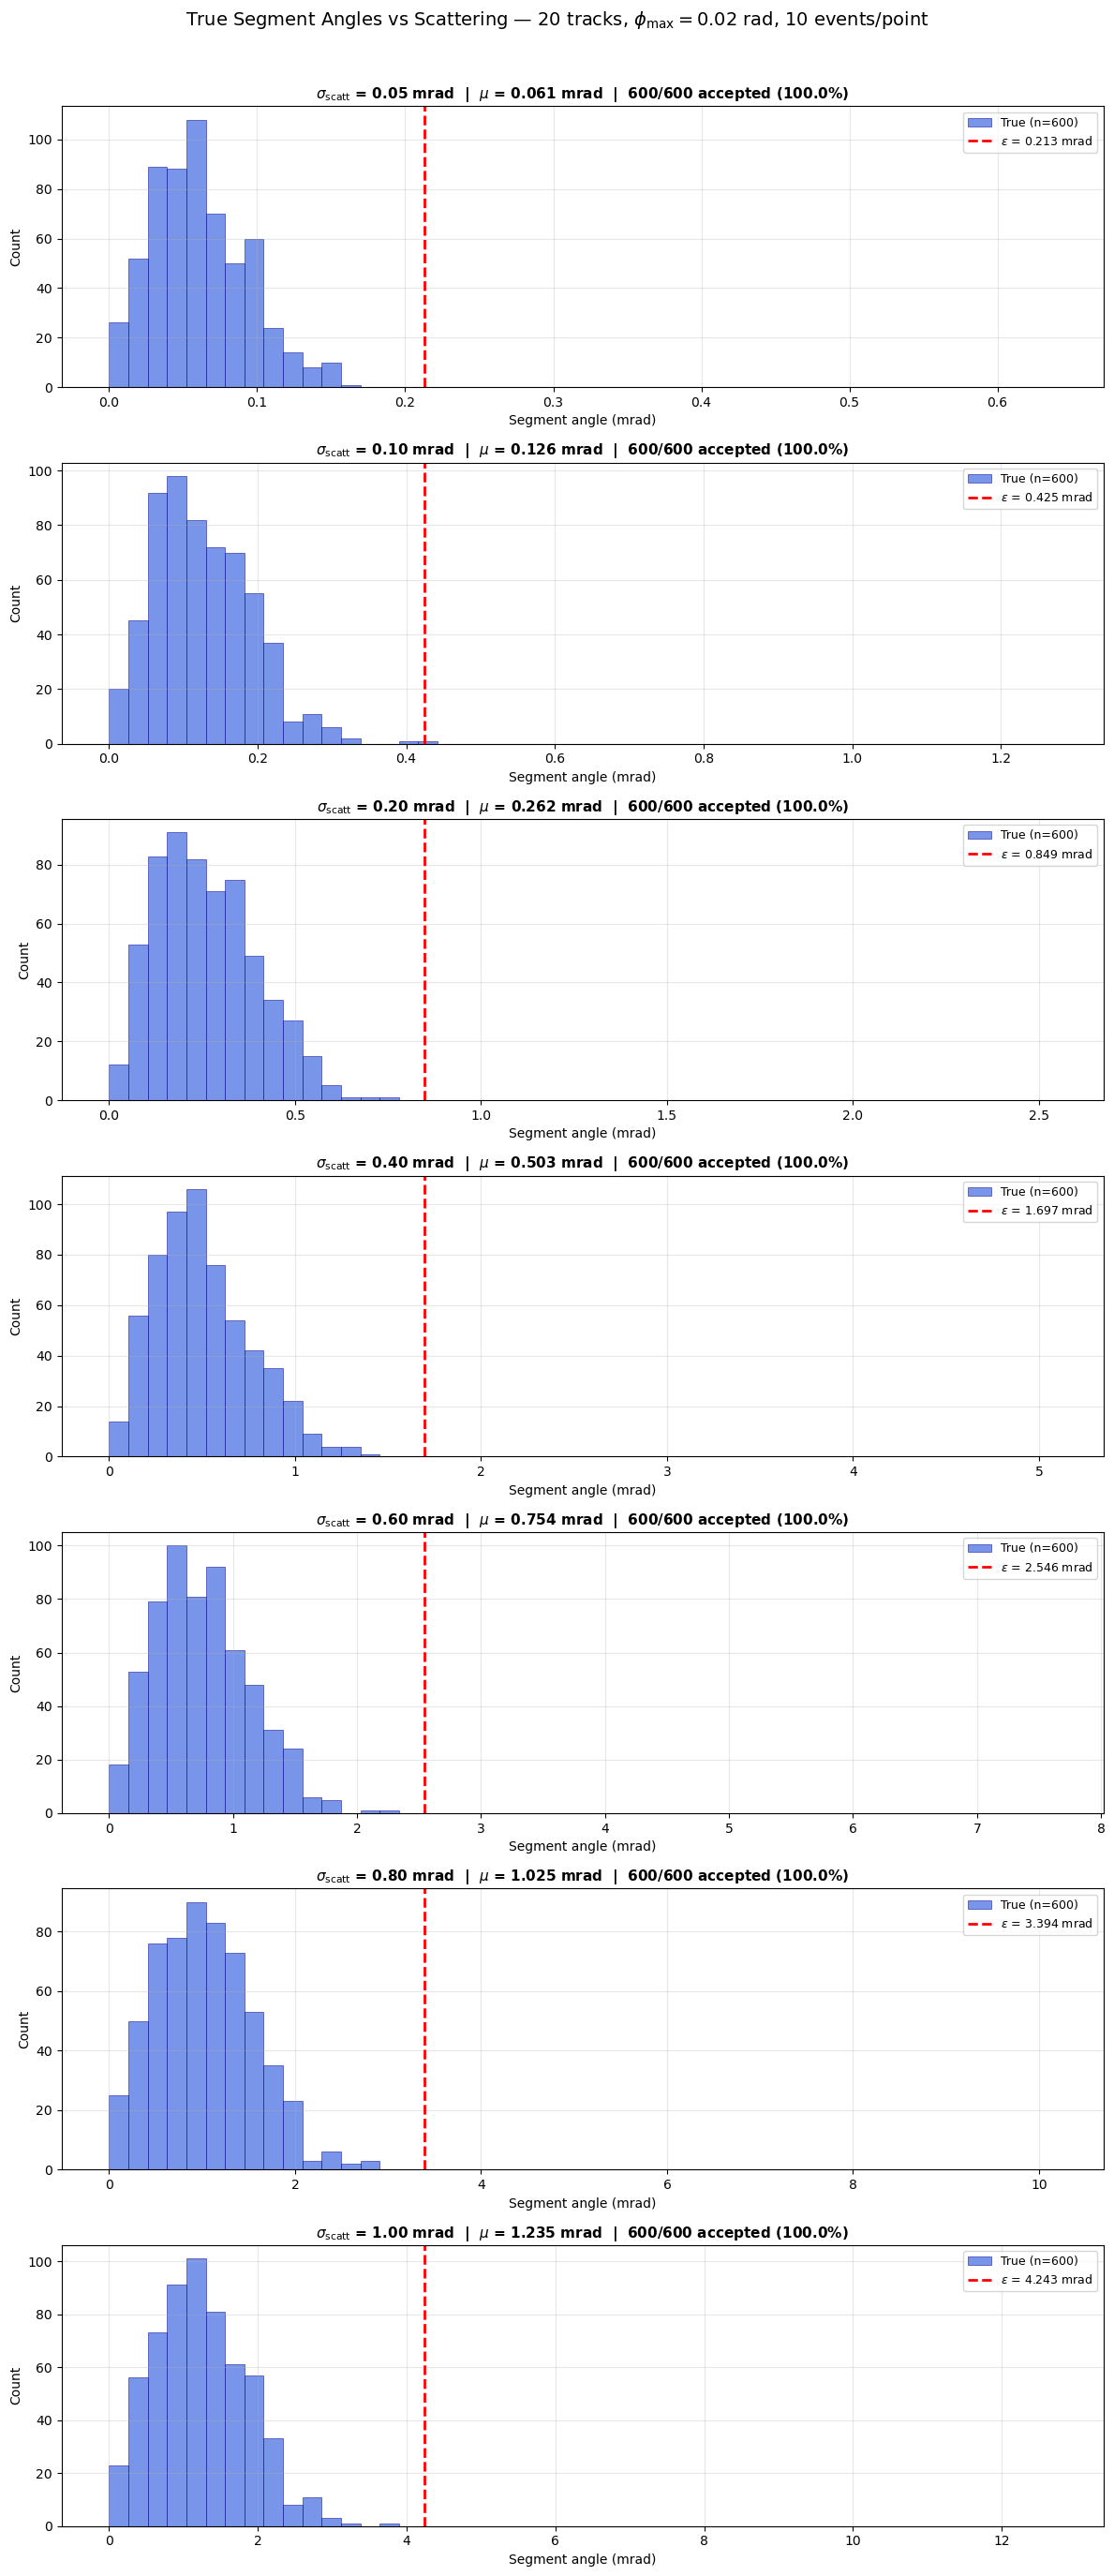

In [7]:
n_plots = len(scatt_angle_results)
fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4 * n_plots))
if n_plots == 1:
    axes = [axes]

for idx, result in enumerate(scatt_angle_results):
    ax = axes[idx]
    true_mrad = result["true_angles"] * 1e3
    epsilon_mrad = result["epsilon"] * 1e3

    # Auto-range: up to max(3*epsilon, 99th percentile of true)
    x_max = max(3 * epsilon_mrad,
                np.percentile(true_mrad, 99) if len(true_mrad) > 0 else 5)
    bins = np.linspace(0, x_max, 50)

    ax.hist(true_mrad, bins=bins, alpha=0.7, color='royalblue',
            edgecolor='darkblue', linewidth=0.5, label=f'True (n={result["n_true"]})')
    ax.axvline(epsilon_mrad, color='red', linestyle='--', linewidth=2,
               label=rf'$\varepsilon$ = {epsilon_mrad:.3f} mrad')

    accepted = result["true_accepted"]
    n_true   = result["n_true"]
    ax.set_title(
        rf'$\sigma_{{\mathrm{{scatt}}}}$ = {result["sigma_scatt_mrad"]:.2f} mrad  |  '
        rf'$\mu$ = {np.mean(true_mrad):.3f} mrad  |  '
        f'{accepted}/{n_true} accepted ({result["segment_efficiency"]*100:.1f}%)',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Segment angle (mrad)')
    ax.set_ylabel('Count')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(rf'True Segment Angles vs Scattering — {N_TRACKS_HIST} tracks, '
             rf'$\phi_{{\max}}={PHI_MAX_HIST}$ rad, {N_EVENTS_HIST} events/point',
             fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DIR / 'scattering_sweep_histograms.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'scattering_sweep_histograms.pdf', bbox_inches='tight')
plt.show()

## 5. Segment Efficiency & False Rate vs Scattering

Efficiency and false rate as a function of σ_scatt, for multiple track counts and both angular cones.

| Parameter | Value |
|-----------|-------|
| Swept | σ_scatt × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100] |
| σ_scatt | [0.05 – 1.0] mrad (7 values) |
| σ_res | 0.0 mm |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [8]:
TRACK_COUNTS   = [10, 20, 50, 100]
N_EVENTS_STATS = 10

TRACK_COLORS = {10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d"}
TRACK_FMTS   = {10: "o-",     20: "s--",     50: "D:",      100: "^-."}

_cache_file = CACHE_DIR / "df_seg_scatt.csv"
if _cache_file.exists():
    df_seg_scatt = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_scatt from cache: {len(df_seg_scatt)} rows")
else:
    seg_rows = []

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS:
            for si, sigma_s in enumerate(SIGMA_SCATT_VALUES):
                epsilon = compute_epsilon(0.0, sigma_s)

                for rep in range(N_EVENTS_STATS):
                    np.random.seed(rep + n_trk * 100 + si * 10000)
                    event = safe_generate(n_trk, measurement_error=0.0,
                                          collision_noise=sigma_s,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    seg_rows.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_scatt": sigma_s,
                        "sigma_scatt_mrad": sigma_s * 1e3,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })

            print(f"  phi_max={phi_max}  n_tracks={n_trk:3d}  done")

    df_seg_scatt = pd.DataFrame(seg_rows)
    df_seg_scatt.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_scatt)} rows collected & saved")

Loaded df_seg_scatt from cache: 560 rows


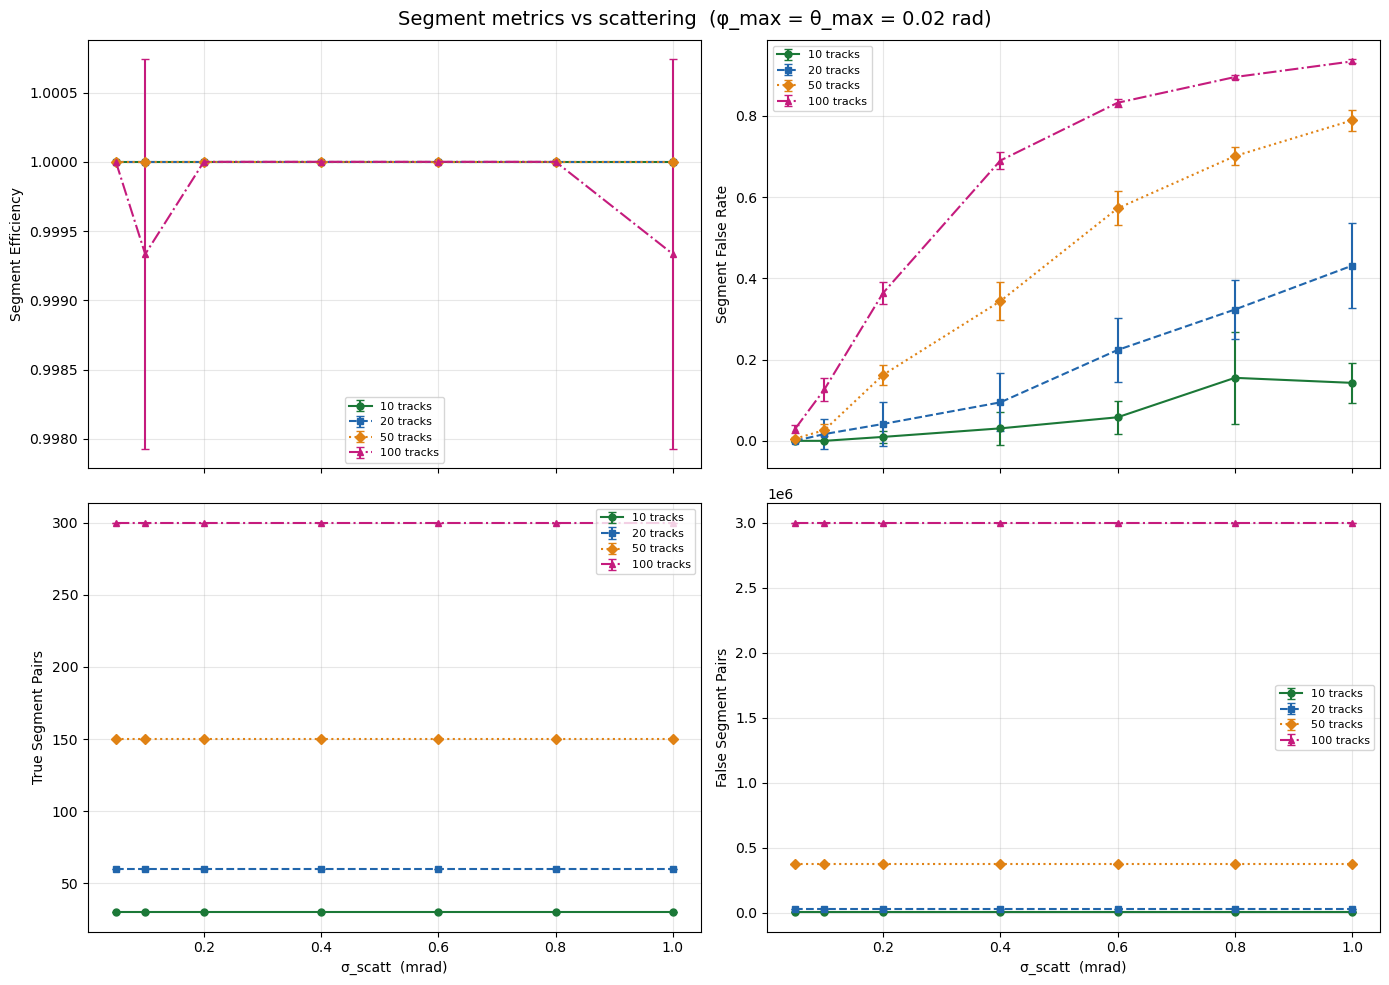

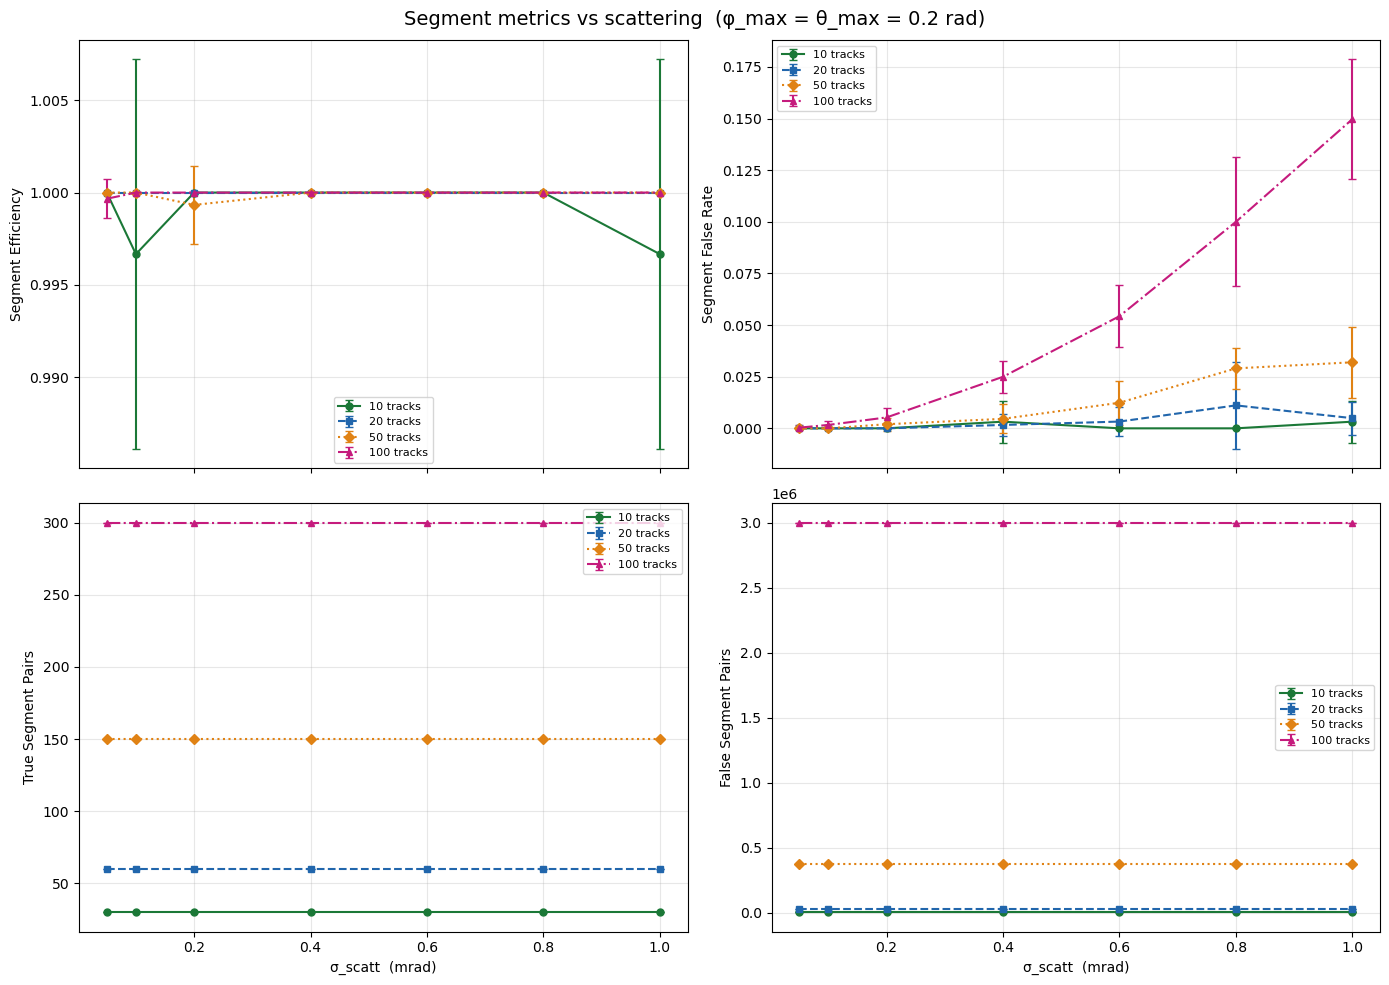

In [9]:
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_scatt[df_seg_scatt["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs scattering  (φ_max = θ_max = {phi_max} rad)",
                 fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",           "True Segment Pairs"),
               ("n_false",          "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_scatt_mrad")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_scatt  (mrad)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'scattering_sweep_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'scattering_sweep_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

## 6. Segment Efficiency & False Rate vs Hit Resolution

Same sweep structure as §5 but varying σ_res at fixed σ_scatt.

| Parameter | Value |
|-----------|-------|
| Swept | σ_res × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100] |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad, fixed) |
| σ_res | [0.0, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05] mm |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [10]:
SIGMA_RES_VALUES   = [0.0, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05]
SIGMA_SCATT_FIXED  = 1e-4

_cache_file = CACHE_DIR / "df_seg_res.csv"
if _cache_file.exists():
    df_seg_res = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_res from cache: {len(df_seg_res)} rows")
else:
    res_rows = []

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS:
            for ri, sigma_r in enumerate(SIGMA_RES_VALUES):
                epsilon = compute_epsilon(sigma_r, SIGMA_SCATT_FIXED)

                for rep in range(N_EVENTS_STATS):
                    np.random.seed(rep + n_trk * 100 + ri * 10000)
                    event = safe_generate(n_trk, measurement_error=sigma_r,
                                          collision_noise=SIGMA_SCATT_FIXED,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    res_rows.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_res": sigma_r,
                        "sigma_res_mm": sigma_r,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })

            print(f"  phi_max={phi_max}  n_tracks={n_trk:3d}  done")

    df_seg_res = pd.DataFrame(res_rows)
    df_seg_res.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_res)} rows collected & saved")

Loaded df_seg_res from cache: 560 rows


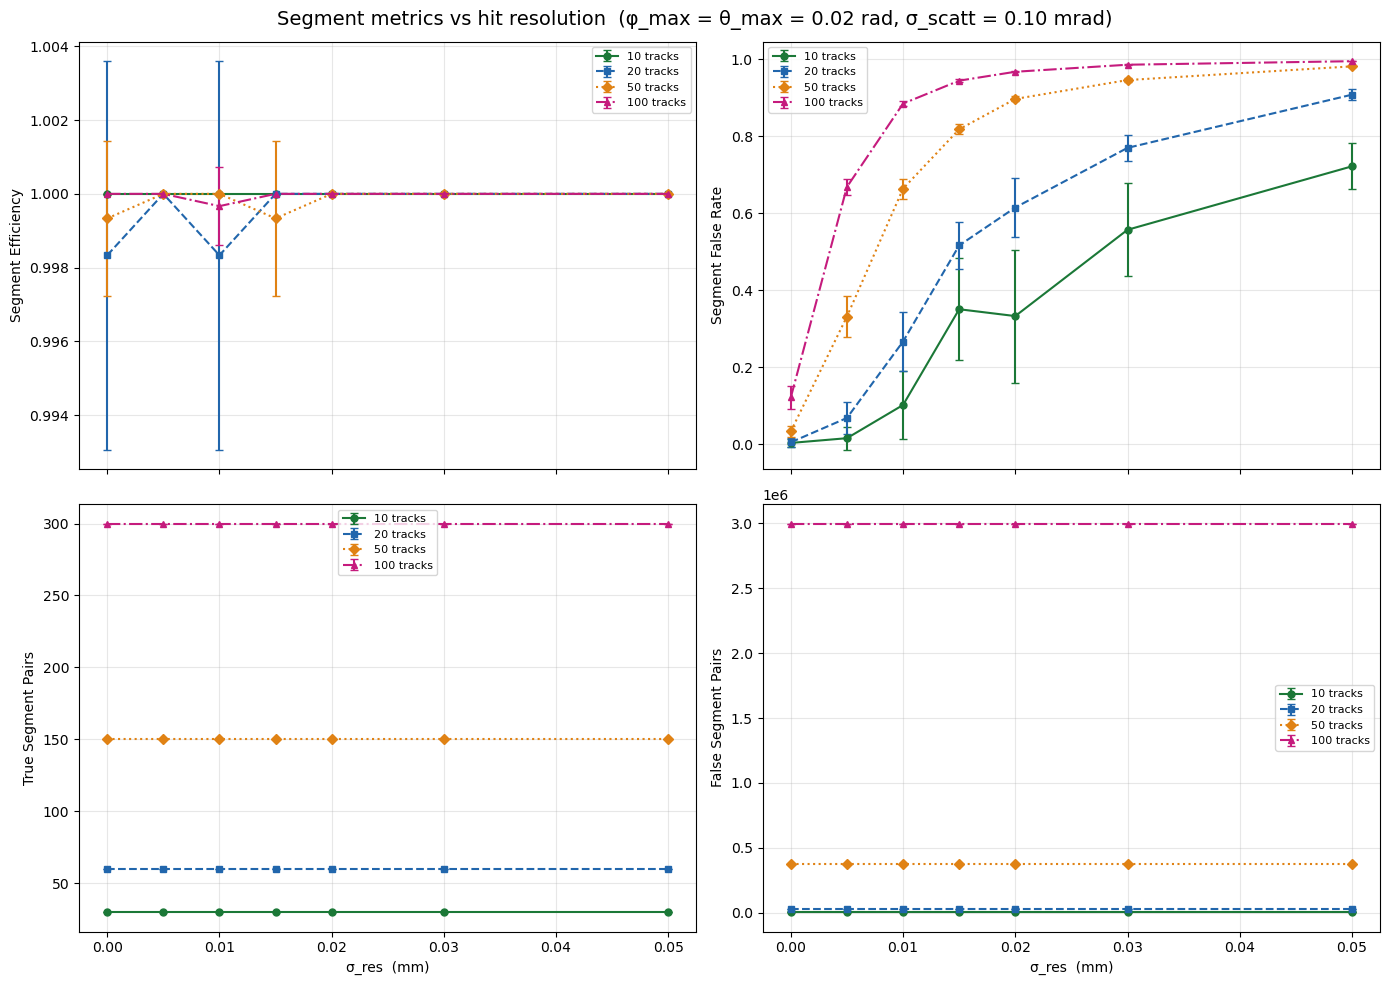

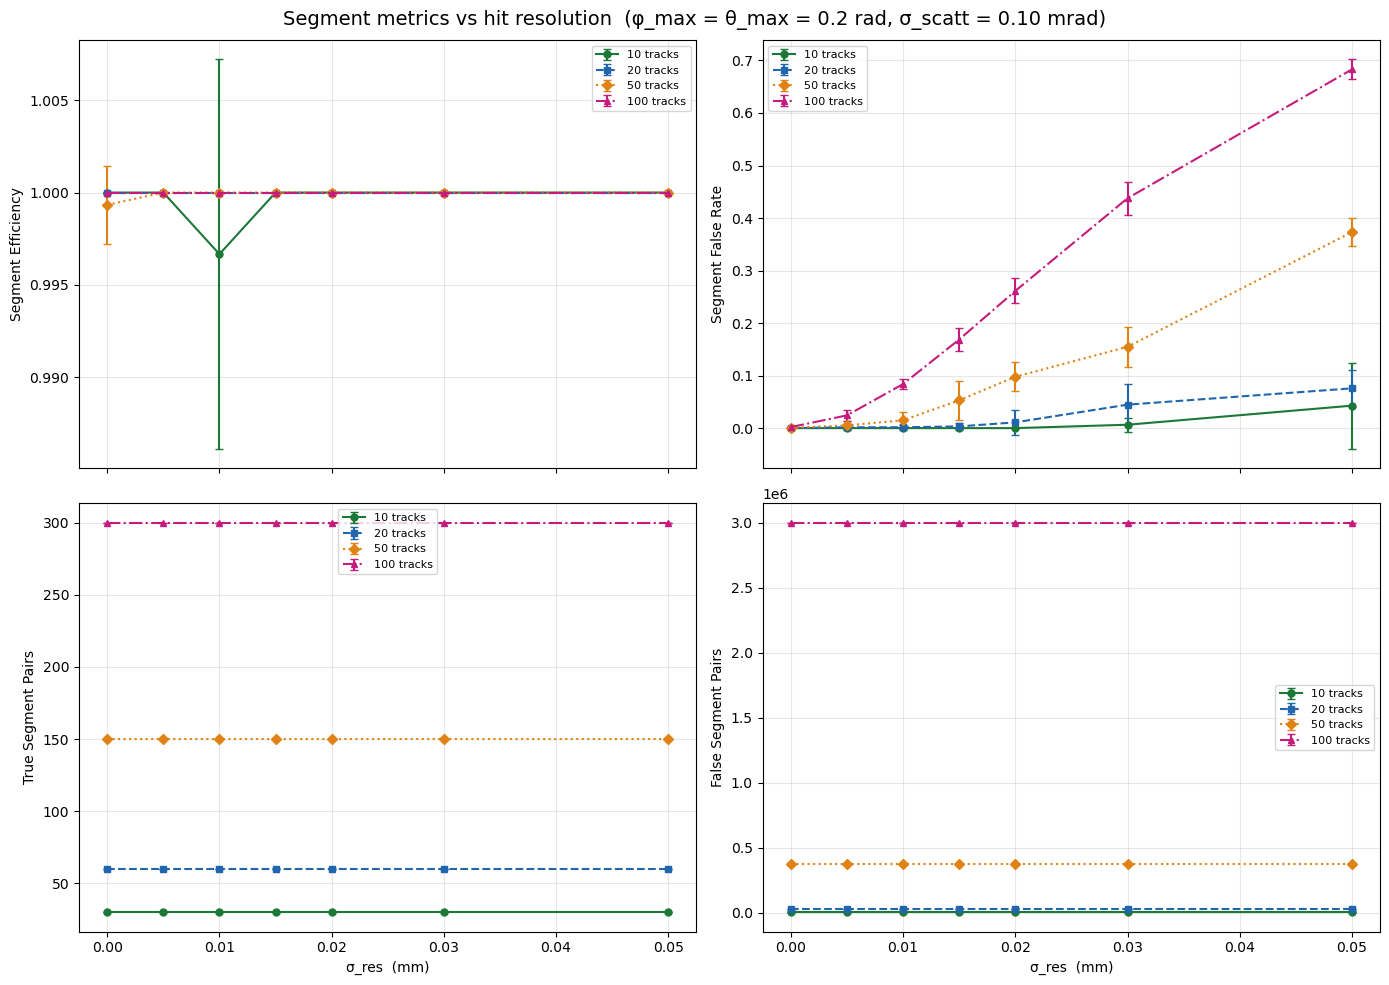

In [11]:
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_res[df_seg_res["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs hit resolution  (φ_max = θ_max = {phi_max} rad, "
                 f"σ_scatt = {SIGMA_SCATT_FIXED*1e3:.2f} mrad)", fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",            "True Segment Pairs"),
               ("n_false",           "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_res_mm")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS[n_trk], color=TRACK_COLORS[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_res  (mm)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'resolution_sweep_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'resolution_sweep_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

## 7. Track Density Scan

Segment metrics vs track count at fixed low noise. True pairs grow ∝ n, false pairs grow ∝ n².

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks |
| n_tracks | 5–100 (step 5) |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Formula** |
| Events per point | 5 |

In [12]:
DENSITY_TRACKS    = list(range(5, 105, 5))
N_EVENTS_DENSITY  = 5
SIGMA_SCATT_DENS  = 1e-4
SIGMA_RES_DENS    = 0.0
PHI_MAX_DENS      = 0.2

epsilon_dens = compute_epsilon(SIGMA_RES_DENS, SIGMA_SCATT_DENS)

_cache_file = CACHE_DIR / "df_density.csv"
if _cache_file.exists():
    df_density = pd.read_csv(_cache_file)
    print(f"Loaded df_density from cache: {len(df_density)} rows")
else:
    density_rows = []

    for n_trk in DENSITY_TRACKS:
        for rep in range(N_EVENTS_DENSITY):
            np.random.seed(rep + n_trk * 100)
            event = safe_generate(n_trk, measurement_error=SIGMA_RES_DENS,
                                  collision_noise=SIGMA_SCATT_DENS,
                                  phi_max=PHI_MAX_DENS, theta_max=PHI_MAX_DENS)
            m = fast_segment_metrics(event, epsilon_dens)
            density_rows.append({
                "n_tracks": n_trk,
                "repeat": rep,
                "epsilon": epsilon_dens,
                **m,
            })

        print(f"  n_tracks={n_trk:3d}  done")

    df_density = pd.DataFrame(density_rows)
    df_density.to_csv(_cache_file, index=False)
    print(f"\n{len(df_density)} rows collected & saved")

Loaded df_density from cache: 100 rows


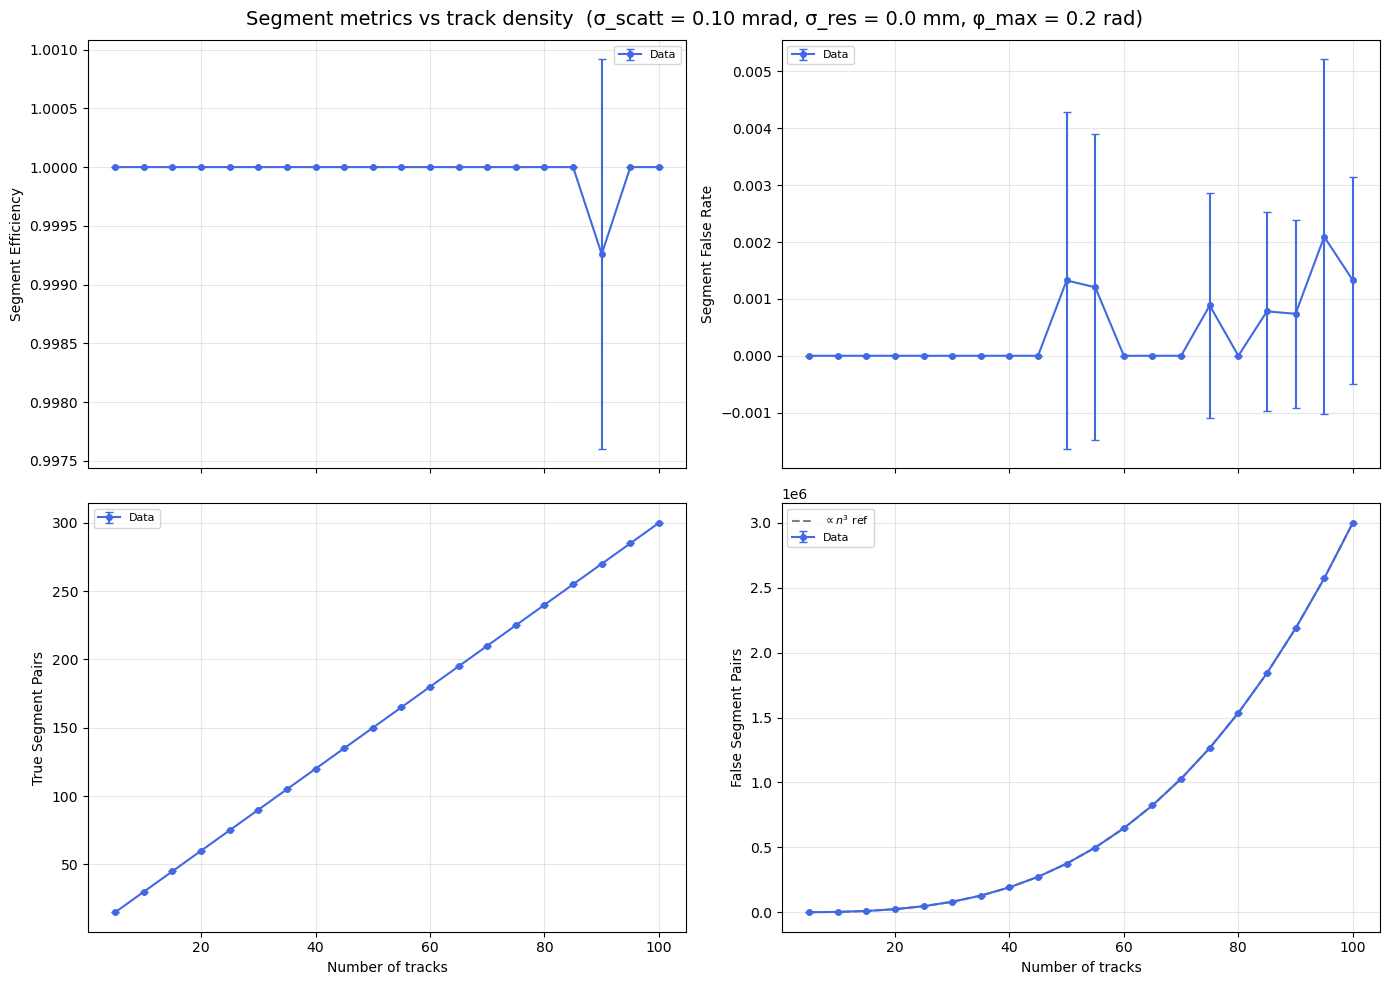

In [13]:
grp = df_density.groupby("n_tracks")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle(f"Segment metrics vs track density  (σ_scatt = {SIGMA_SCATT_DENS*1e3:.2f} mrad, "
             f"σ_res = {SIGMA_RES_DENS} mm, φ_max = {PHI_MAX_DENS} rad)", fontsize=14)

metrics = [("segment_efficiency", "Segment Efficiency"),
           ("segment_false_rate", "Segment False Rate"),
           ("n_true",            "True Segment Pairs"),
           ("n_false",           "False Segment Pairs")]

for ax, (col, label) in zip(axes.flat, metrics):
    mean = grp[col].mean()
    std  = grp[col].std()
    ax.errorbar(mean.index, mean.values, yerr=std.values,
                fmt="o-", color="royalblue", capsize=3, ms=4, label="Data")

    # Reference line for n_false: n³ scaling (triplet combinatorics)
    if col == "n_false":
        n_arr = mean.index.values.astype(float)
        # Fit scale factor from the last point
        c = mean.values[-1] / n_arr[-1]**3 if n_arr[-1] > 0 else 1
        ax.plot(n_arr, c * n_arr**3, "k--", alpha=0.5, label=r"$\propto n^3$ ref")

    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Number of tracks")

fig.tight_layout()
fig.savefig(OUT_DIR / 'density_scan.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'density_scan.pdf', bbox_inches='tight')
plt.show()

## 8. Acceptance Curves (ROC-style)

For each σ_scatt, sweep the acceptance threshold from 0–10 mrad and plot the true/false acceptance fraction. The formula ε marks the operating point.

| Parameter | Value |
|-----------|-------|
| Swept | threshold (0–10 mrad, 200 steps) × σ_scatt |
| n_tracks | 20 |
| σ_scatt | [0.05 – 1.0] mrad (7 values) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Formula** (operating-point markers) |
| Events per σ_scatt | 10 |

Loaded roc_data from cache: 7 scattering values


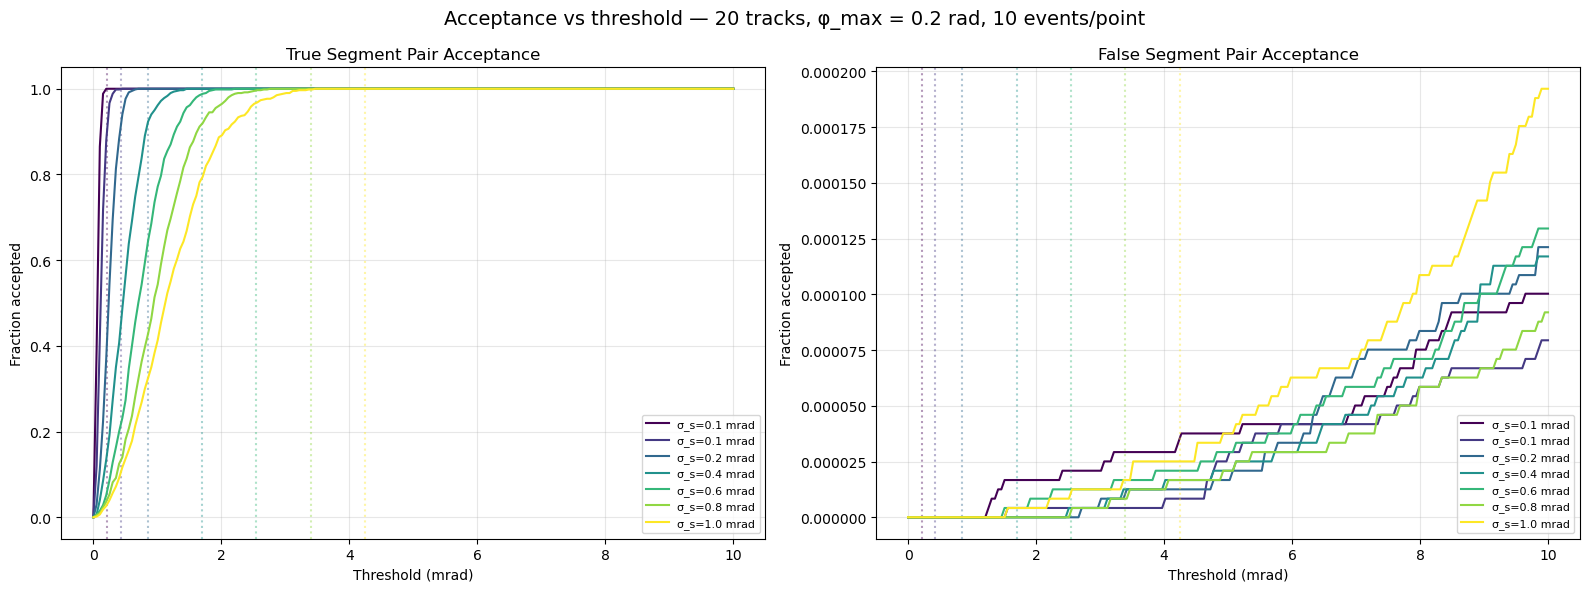

In [14]:
N_TRACKS_ROC = 20
N_EVENTS_ROC = 10
PHI_MAX_ROC  = 0.2
THRESHOLDS   = np.linspace(0, 10e-3, 200)  # 0 to 10 mrad

# Collect raw angles for each scattering value
_cache_file = CACHE_DIR / "roc_data.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        roc_data = pickle.load(f)
    print(f"Loaded roc_data from cache: {len(roc_data)} scattering values")
else:
    roc_data = {}
    for si, sigma_s in enumerate(SIGMA_SCATT_VALUES):
        all_true, all_false = [], []
        for ev_i in range(N_EVENTS_ROC):
            np.random.seed(si * 1000 + ev_i)
            event = safe_generate(N_TRACKS_ROC, measurement_error=0.0,
                                  collision_noise=sigma_s,
                                  phi_max=PHI_MAX_ROC, theta_max=PHI_MAX_ROC)
            ta, fa = collect_segment_pair_angles(event)
            all_true.extend(ta)
            all_false.extend(fa)
        roc_data[sigma_s] = (np.array(all_true), np.array(all_false))
        print(f"  σ_scatt={sigma_s*1e3:.2f} mrad  true={len(all_true)}  false={len(all_false)}")

    with open(_cache_file, "wb") as f:
        pickle.dump(roc_data, f)
    print("ROC data saved to cache")

# Plot acceptance curves
cmap = plt.cm.viridis
colors = [cmap(i / max(1, len(SIGMA_SCATT_VALUES) - 1))
          for i in range(len(SIGMA_SCATT_VALUES))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for sigma_s, color in zip(SIGMA_SCATT_VALUES, colors):
    true_arr, false_arr = roc_data[sigma_s]
    epsilon = compute_epsilon(0.0, sigma_s)

    true_frac  = [np.mean(true_arr <= th) if len(true_arr) > 0 else 0
                  for th in THRESHOLDS]
    false_frac = [np.mean(false_arr <= th) if len(false_arr) > 0 else 0
                  for th in THRESHOLDS]

    label = f"σ_s={sigma_s*1e3:.1f} mrad"
    ax1.plot(THRESHOLDS * 1e3, true_frac, color=color, label=label)
    ax2.plot(THRESHOLDS * 1e3, false_frac, color=color, label=label)

    # Mark the epsilon operating point
    ax1.axvline(epsilon * 1e3, color=color, linestyle=':', alpha=0.4)
    ax2.axvline(epsilon * 1e3, color=color, linestyle=':', alpha=0.4)

ax1.set_title("True Segment Pair Acceptance", fontsize=12)
ax1.set_xlabel("Threshold (mrad)")
ax1.set_ylabel("Fraction accepted")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(True, alpha=0.3)

ax2.set_title("False Segment Pair Acceptance", fontsize=12)
ax2.set_xlabel("Threshold (mrad)")
ax2.set_ylabel("Fraction accepted")
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Acceptance vs threshold — {N_TRACKS_ROC} tracks, "
             f"φ_max = {PHI_MAX_ROC} rad, {N_EVENTS_ROC} events/point", fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / 'acceptance_curves.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'acceptance_curves.pdf', bbox_inches='tight')
plt.show()

## 9. Summary Tables & CSV Export

Aggregate mean ± std for each configuration and save to CSV for downstream use.

In [15]:
agg_cols = ["segment_efficiency", "segment_false_rate", "n_true", "n_false"]

# ── Scattering sweep summary ─────────────────────────────────────
print("=" * 80)
print("SCATTERING SWEEP SUMMARY")
print("=" * 80)
summary_scatt = (df_seg_scatt
    .groupby(["phi_max", "n_tracks", "sigma_scatt_mrad"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_scatt.round(4))

# ── Resolution sweep summary ─────────────────────────────────────
print("\n" + "=" * 80)
print("RESOLUTION SWEEP SUMMARY")
print("=" * 80)
summary_res = (df_seg_res
    .groupby(["phi_max", "n_tracks", "sigma_res_mm"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_res.round(4))

# ── Density scan summary ─────────────────────────────────────────
print("\n" + "=" * 80)
print("DENSITY SCAN SUMMARY")
print("=" * 80)
summary_dens = (df_density
    .groupby("n_tracks")[agg_cols]
    .agg(["mean", "std"])
)
display(summary_dens.round(4))

SCATTERING SWEEP SUMMARY


segment_efficiency          \
                                                mean     std   
phi_max n_tracks sigma_scatt_mrad                              
0.02    10       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        20       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        50       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        100      0.05                         1.0000  0.0000   
                 0.10                         0.9993  0.0014   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         0.9993  0.0014   
0.20    10       0.05                         1.0000  0.0000   
                 0.10                         0.9967  0.0105   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         0.9967  0.0105   
        20       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        50       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         0.9993  0.0021   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   
        100      0.05                         0.9997  0.0011   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
                 0.80                         1.0000  0.0000   
                 1.00                         1.0000  0.0000   

                                  segment_false_rate         n_true       \
                                                mean     std   mean  std   
phi_max n_tracks sigma_scatt_mrad                                          
0.02    10       0.05        


RESOLUTION SWEEP SUMMARY


segment_efficiency         segment_false_rate  \
                                            mean     std               mean   
phi_max n_tracks sigma_res_mm                                                 
0.02    10       0.000                    1.0000  0.0000             0.0032   
                 0.005                    1.0000  0.0000             0.0155   
                 0.010                    1.0000  0.0000             0.1017   
                 0.015                    1.0000  0.0000             0.3503   
                 0.020                    1.0000  0.0000             0.3326   
                 0.030                    1.0000  0.0000             0.5566   
                 0.050                    1.0000  0.0000             0.7214   
        20       0.000                    0.9983  0.0053             0.0049   
                 0.005                    1.0000  0.0000             0.0681   
                 0.010                    0.9983  0.0053             0.2666   
                 0.015                    1.0000  0.0000             0.5160   
                 0.020                    1.0000  0.0000             0.6145   
                 0.030                    1.0000  0.0000             0.7694   
                 0.050                    1.0000  0.0000             0.9074   
        50       0.000                    0.9993  0.0021             0.0333   
                 0.005                    1.0000  0.0000             0.3314   
                 0.010                    1.0000  0.0000             0.6634   
                 0.015                    0.9993  0.0021             0.8175   
                 0.020                    1.0000  0.0000             0.8964   
                 0.030                    1.0000  0.0000             0.9454   
                 0.050                    1.0000  0.0000             0.9810   
        100      0.000                    1.0000  0.0000             0.1216   
                 0.005                    1.0000  0.0000             0.6680   
                 0.010                    0.9997  0.0011             0.8842   
                 0.015                    1.0000  0.0000             0.9438   
                 0.020                    1.0000  0.0000             0.9669   
                 0.030                    1.0000  0.0000             0.9852   
                 0.050                    1.0000  0.0000             0.9944   
0.20    10       0.000                    1.0000  0.0000             0.0000   
                 0.005                    1.0000  0.0000             0.0000   
                 0.010                    0.9967  0.0105             0.0000   
                 0.015                    1.0000  0.0000             0.0000   
                 0.020                    1.0000  0.0000             0.0000   
                 0.030                    1.0000  0.0000             0.0065   
                 0.050                    1.0000  0.0000             0.0428   
        20       0.000                    1.0000  0.0000             0.0000   
                 0.005                    1.0000  0.0000             0.0016   
                 0.010                    1.0000  0.0000             0.0016   
                 0.015                    1.0000  0.0000             0.0033   
                 0.020                    1.0000  0.0000             0.0110   
                 0.030                    1.0000  0.0000             0.0446   
                 0.050                    1.0000  0.0000             0.0757   
        50       0.000                    0.9993  0.0021             0.0007   
                 0.005                    1.0000  0.0000             0.0052   
                 0.010                    1.0000  0.0000             0.0149   
                 0.015                    1.0000  0.0000             0.0529   
                 0.020                    1.0000  0.0000             0.0978   
                 0.030                    1.0000  0.0000             0.1548   
 


DENSITY SCAN SUMMARY


segment_efficiency         segment_false_rate         n_true       \
                       mean     std               mean     std   mean  std   
n_tracks                                                                     
5                    1.0000  0.0000             0.0000  0.0000   15.0  0.0   
10                   1.0000  0.0000             0.0000  0.0000   30.0  0.0   
15                   1.0000  0.0000             0.0000  0.0000   45.0  0.0   
20                   1.0000  0.0000             0.0000  0.0000   60.0  0.0   
25                   1.0000  0.0000             0.0000  0.0000   75.0  0.0   
30                   1.0000  0.0000             0.0000  0.0000   90.0  0.0   
35                   1.0000  0.0000             0.0000  0.0000  105.0  0.0   
40                   1.0000  0.0000             0.0000  0.0000  120.0  0.0   
45                   1.0000  0.0000             0.0000  0.0000  135.0  0.0   
50                   1.0000  0.0000             0.0013  0.0030  150.0  0.0   
55                   1.0000  0.0000             0.0012  0.0027  165.0  0.0   
60                   1.0000  0.0000             0.0000  0.0000  180.0  0.0   
65                   1.0000  0.0000             0.0000  0.0000  195.0  0.0   
70                   1.0000  0.0000             0.0000  0.0000  210.0  0.0   
75                   1.0000  0.0000             0.0009  0.0020  225.0  0.0   
80                   1.0000  0.0000             0.0000  0.0000  240.0  0.0   
85                   1.0000  0.0000             0.0008  0.0017  255.0  0.0   
90                   0.9993  0.0017             0.0007  0.0017  270.0  0.0   
95                   1.0000  0.0000             0.0021  0.0031  285.0  0.0   
100                  1.0000  0.0000             0.0013  0.0018  300.0  0.0   

            n_false       
               mean  std  
n_tracks                  
5             360.0  0.0  
10           2970.0  0.0  
15          10080.0  0.0  
20          23940.0  0.0  
25          46800.0  0.0  
30          80910.0  0.0  
35         128520.0  0.0  
40         191880.0  0.0  
45         273240.0  0.0  
50         374850.0  0.0  
55         498960.0  0.0  
60         647820.0  0.0  
65         823680.0  0.0  
70        1028790.0  0.0  
75        1265400.0  0.0  
80        1535760.0  0.0  
85        1842120.0  0.0  
90        2186730.0  0.0  
95        2571840.0  0.0  
100       2999700.0  0.0

In [16]:
# Save per-event DataFrames
df_seg_scatt.to_csv(OUT_DIR / "segment_scattering_sweep.csv", index=False)
df_seg_res.to_csv(OUT_DIR / "segment_resolution_sweep.csv", index=False)
df_density.to_csv(OUT_DIR / "segment_density_scan.csv", index=False)

print(f"Saved CSVs to {OUT_DIR}/")
for f in sorted(OUT_DIR.glob("*.csv")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Saved CSVs to outputs/segment_analysis/
  segment_density_scan.csv  (5.0 KB)
  segment_density_scan_ext.csv  (11.4 KB)
  segment_resolution_sweep.csv  (40.6 KB)
  segment_resolution_sweep_ext.csv  (77.9 KB)
  segment_scattering_sweep.csv  (39.5 KB)
  segment_scattering_sweep_ext.csv  (76.5 KB)
  segment_zero_noise_ext.csv  (106.4 KB)


## 10. Fixed-Epsilon Segment Efficiency (Triplet Angles, Old-Style Generation)

Segment efficiency and false rate vs track density with a **fixed** ε threshold.
Uses **triplet kink angles** (accelerated Hamiltonian) but matches the old notebook's
event generation **exactly**: multi-event with 20 tracks/event, 160 mm modules, MIP particles,
PV σ = {x:1, y:1, z:1}. The **only** difference from §10b is the angle method.

| Parameter | Value |
|-----------|-------|
| Swept | n_events (1–50 → 20–1000 total tracks) |
| Tracks per event | 20 |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.005 mm |
| φ_min, φ_max | −0.2, +0.2 rad |
| θ_min, θ_max | default (−0.2, +0.2 rad) |
| ε mode | **Fixed = 2.0 mrad** |
| lx, ly | 80 mm (half-width → 160 mm full module) |
| module_id | [1, 2, 3, 4, 5] |
| PV sigma | x = 1, y = 1, z = 1 mm |
| Repeats | 50 (≤100 tracks), 10 (101–500), 5 (>500) |
| Particle | MIP, mass = 0.511, q = 1 |
| Angle method | **Triplet kink angles** (fast_segment_metrics) |

In [17]:
# ============================================================================
# FIXED-EPSILON DATA COLLECTION — triplet angles, old-style multi-event gen
# ============================================================================
import time as _time

FIXED_RESOLUTION  = 0.005      # 5 µm
FIXED_SCATTERING  = 0.0001     # 0.1 mrad in radians
FIXED_EPSILON     = 0.002      # 2 mrad in radians
TRACKS_PER_EVENT  = 20
EVENT_COUNTS      = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45, 50]
FIXED_TRACK_COUNTS = [n * TRACKS_PER_EVENT for n in EVENT_COUNTS]
N_REPEATS_FIXED   = 50  # for ≤100 tracks; reduced at higher multiplicities

# ── Build geometry matching old notebook ──
_NEW_HALF  = 80.0   # 160 mm full module (matches old)
geo_new = PlaneGeometry(
    module_id=list(range(1, N_MODULES + 1)),
    lx=[_NEW_HALF] * N_MODULES,
    ly=[_NEW_HALF] * N_MODULES,
    z=z_positions,
)

# ── Use SAME PV sigma as old notebook to isolate angle method ──
NEW_PV_SIGMA = {"x": 1, "y": 1, "z": 1}

print("=" * 80)
print("SEGMENT-LEVEL EFFICIENCY (fixed ε = 2 mrad, triplet angles)")
print("=" * 80)
print(f"σ_res = {FIXED_RESOLUTION} mm, σ_scatt = {FIXED_SCATTERING} rad")
print(f"Epsilon threshold: {FIXED_EPSILON*1000:.1f} mrad")
print(f"Geometry: module = {_NEW_HALF*2}×{_NEW_HALF*2} mm², z = {z_positions}")
print(f"Track counts: {FIXED_TRACK_COUNTS}")
print(f"PV sigma: {NEW_PV_SIGMA}")
print("=" * 80)

_cache_file = CACHE_DIR / "segment_efficiency_results.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        segment_efficiency_results = pickle.load(f)
    _existing_tracks = {r['total_tracks'] for r in segment_efficiency_results}
    _needed = [n for n in EVENT_COUNTS
               if n * TRACKS_PER_EVENT not in _existing_tracks]
    if _needed:
        print(f"Loaded {len(segment_efficiency_results)} cached entries, "
              f"need {len(_needed)} more: "
              f"{[n*TRACKS_PER_EVENT for n in _needed]}")
    else:
        print(f"Loaded segment_efficiency_results from cache: "
              f"{len(segment_efficiency_results)} entries (all done)")
        _needed = []
else:
    segment_efficiency_results = []
    _needed = EVENT_COUNTS
    print("No cache — generating all configurations")

if _needed:
    _t0 = _time.time()
    for n_events in _needed:
        total_tracks = n_events * TRACKS_PER_EVENT
        n_particles_per_event = [TRACKS_PER_EVENT] * n_events

        # Match old notebook repeat schedule
        if total_tracks <= 100:
            nr_target = 50
        elif total_tracks <= 500:
            nr_target = 10
        else:
            nr_target = 5

        per_repeat_data = []
        _t1 = _time.time()

        for repeat in range(nr_target):
            np.random.seed(repeat + n_events * 1000)

            gen = StateEventGenerator(
                detector_geometry=geo_new,
                phi_min=-0.2,
                phi_max=0.2,
                # theta not set → defaults to ±0.2
                events=n_events,
                n_particles=n_particles_per_event,
                measurement_error=float(FIXED_RESOLUTION),
                collision_noise=float(FIXED_SCATTERING),
            )

            gen.generate_random_primary_vertices(NEW_PV_SIGMA)

            event_particles = [
                [{"type": "MIP", "mass": 0.511, "q": 1}
                 for _ in range(total_tracks)]
                for _ in range(n_events)
            ]
            gen.generate_particles(event_particles)
            event = gen.generate_complete_events()

            m = fast_segment_metrics(event, FIXED_EPSILON)

            per_repeat_data.append({
                'n_true': m['n_true'],
                'n_false': m['n_false'],
                'true_accepted': m['true_accepted'],
                'false_accepted': m['false_accepted'],
                'seg_efficiency': m['segment_efficiency'],
                'seg_false_rate': m['segment_false_rate'],
            })

        # Per-repeat arrays
        n_true_per    = np.array([r['n_true'] for r in per_repeat_data])
        n_false_per   = np.array([r['n_false'] for r in per_repeat_data])
        true_acc_per  = np.array([r['true_accepted'] for r in per_repeat_data])
        false_acc_per = np.array([r['false_accepted'] for r in per_repeat_data])
        eff_per       = np.array([r['seg_efficiency'] for r in per_repeat_data])
        fr_per        = np.array([r['seg_false_rate'] for r in per_repeat_data])
        nr = len(per_repeat_data)

        segment_efficiency_results.append({
            'total_tracks': total_tracks,
            'n_repeats': nr,
            'seg_efficiency_mean': np.mean(eff_per),
            'seg_efficiency_se': np.std(eff_per, ddof=1) / np.sqrt(nr),
            'seg_false_rate_mean': np.mean(fr_per),
            'seg_false_rate_se': np.std(fr_per, ddof=1) / np.sqrt(nr),
            'n_true_mean': np.mean(n_true_per),
            'n_true_se': np.std(n_true_per, ddof=1) / np.sqrt(nr),
            'n_false_mean': np.mean(n_false_per),
            'n_false_se': np.std(n_false_per, ddof=1) / np.sqrt(nr),
            'true_acc_mean': np.mean(true_acc_per),
            'true_acc_se': np.std(true_acc_per, ddof=1) / np.sqrt(nr),
            'false_acc_mean': np.mean(false_acc_per),
            'false_acc_se': np.std(false_acc_per, ddof=1) / np.sqrt(nr),
            'per_repeat': per_repeat_data,
        })

        _dt = _time.time() - _t1
        print(f"  [{total_tracks:4d} tracks, {n_events:2d} events, {nr:2d} repeats]  "
              f"eff={np.mean(eff_per)*100:.2f}%  fr={np.mean(fr_per)*100:.2f}%  "
              f"({_dt:.1f}s)")

    # Sort by total_tracks before saving
    segment_efficiency_results.sort(key=lambda r: r['total_tracks'])

    with open(_cache_file, "wb") as f:
        pickle.dump(segment_efficiency_results, f)
    print(f"\n{'='*80}")
    print(f"Done & saved ({_time.time()-_t0:.0f}s total, "
          f"{len(segment_efficiency_results)} configs)")
    print(f"{'='*80}")

SEGMENT-LEVEL EFFICIENCY (fixed ε = 2 mrad, triplet angles)
σ_res = 0.005 mm, σ_scatt = 0.0001 rad
Epsilon threshold: 2.0 mrad
Geometry: module = 160.0×160.0 mm², z = [33.0, 66.0, 99.0, 132.0, 165.0]
Track counts: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
PV sigma: {'x': 1, 'y': 1, 'z': 1}
Loaded segment_efficiency_results from cache: 18 entries (all done)


Saved to outputs/segment_analysis/fixed_epsilon_segment_efficiency.png
Saved to outputs/segment_analysis/fixed_epsilon_segment_efficiency.pdf


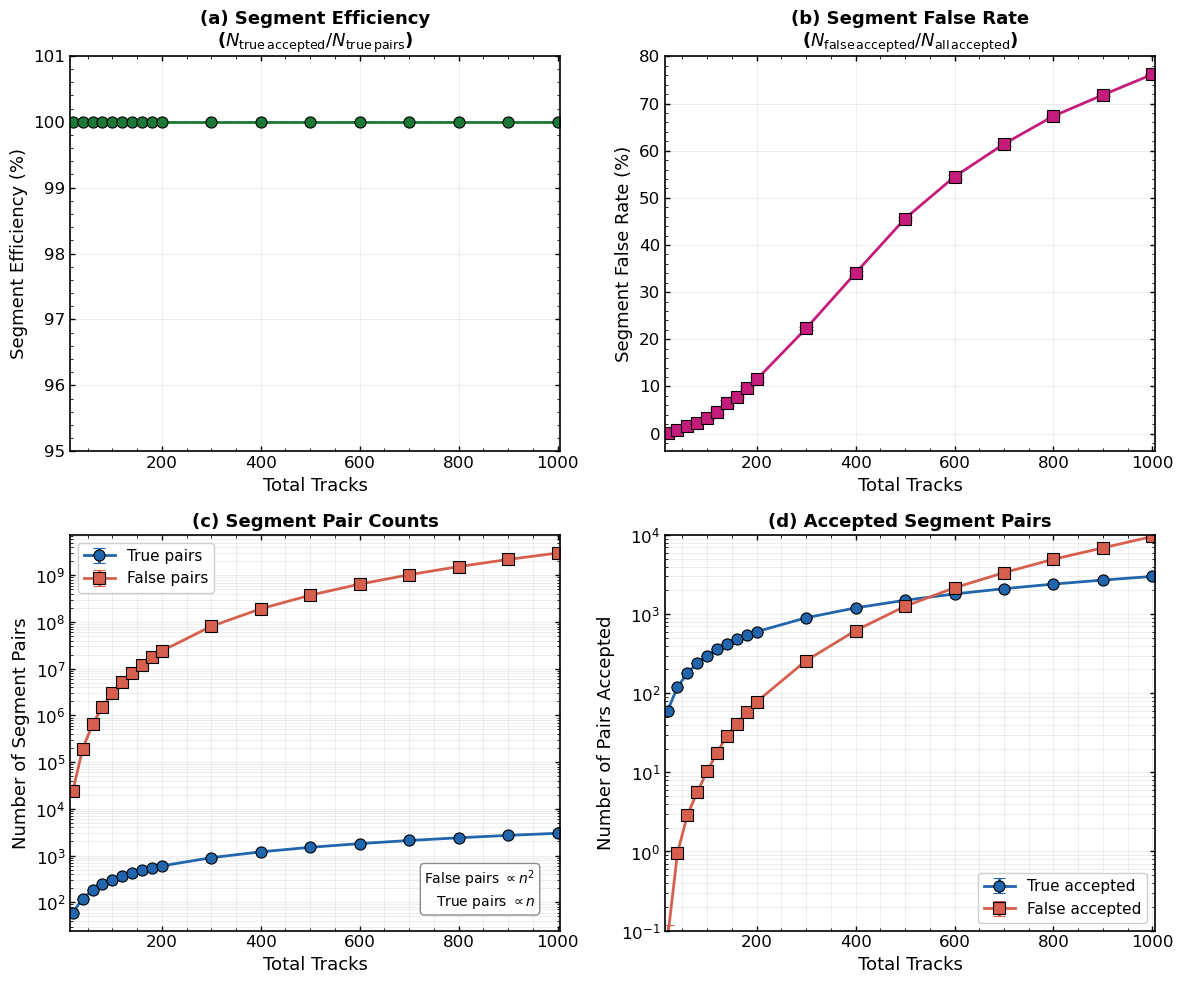


SEGMENT-LEVEL EFFICIENCY SUMMARY TABLE (per-repeat mean ± SE)
Tracks     Reps   Seg Eff          False Rate       True Pairs         False Pairs        True Acc         False Acc       
----------------------------------------------------------------------------------------------------------------------------------
20         50     100.00% ± 0.00%  0.13% ± 0.06%    60 ± 0.0           23940 ± 0.0        60 ± 0.0         0.1 ± 0.0       
40         50     100.00% ± 0.00%  0.79% ± 0.12%    120 ± 0.0          191880 ± 0.0       120 ± 0.0        1.0 ± 0.2       
60         50     100.00% ± 0.00%  1.56% ± 0.22%    180 ± 0.0          647820 ± 0.0       180 ± 0.0        2.9 ± 0.4       
80         50     100.00% ± 0.00%  2.28% ± 0.13%    240 ± 0.0          1535760 ± 0.0      240 ± 0.0        5.6 ± 0.3       
100        50     100.00% ± 0.00%  3.32% ± 0.14%    300 ± 0.0          2999700 ± 0.0      300 ± 0.0        10.3 ± 0.4      
120        10     100.00% ± 0.00%  4.66% ± 0.48%    360 ± 0.0 

In [18]:
# ============================================================================
# SEGMENT EFFICIENCY: Visualization (Paper-Ready with Error Bars)
# ============================================================================

# Paper-ready plot settings
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'lines.linewidth': 2,
    'lines.markersize': 8,
})

if len(segment_efficiency_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Color scheme
    color_true = '#2166ac'
    color_false = '#d6604d'
    color_eff = '#1b7837'
    color_false_rate = '#c51b7d'

    track_counts   = np.array([r['total_tracks'] for r in segment_efficiency_results])
    seg_eff        = np.array([r['seg_efficiency_mean'] * 100 for r in segment_efficiency_results])
    seg_eff_err    = np.array([r['seg_efficiency_se'] * 100 for r in segment_efficiency_results])
    false_rate     = np.array([r['seg_false_rate_mean'] * 100 for r in segment_efficiency_results])
    false_rate_err = np.array([r['seg_false_rate_se'] * 100 for r in segment_efficiency_results])
    n_true_mean    = np.array([r['n_true_mean'] for r in segment_efficiency_results])
    n_true_se      = np.array([r['n_true_se'] for r in segment_efficiency_results])
    n_false_mean   = np.array([r['n_false_mean'] for r in segment_efficiency_results])
    n_false_se     = np.array([r['n_false_se'] for r in segment_efficiency_results])
    true_acc_mean  = np.array([r['true_acc_mean'] for r in segment_efficiency_results])
    true_acc_se    = np.array([r['true_acc_se'] for r in segment_efficiency_results])
    false_acc_mean = np.array([r['false_acc_mean'] for r in segment_efficiency_results])
    false_acc_se   = np.array([r['false_acc_se'] for r in segment_efficiency_results])

    # Plot 1: Segment Efficiency with error bars
    ax1 = axes[0, 0]
    ax1.errorbar(track_counts, seg_eff, yerr=seg_eff_err,
                fmt='o-', color=color_eff, capsize=5, capthick=1.5,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8)
    ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.set_xlabel('Total Tracks', fontsize=13)
    ax1.set_ylabel('Segment Efficiency (%)', fontsize=13)
    ax1.set_title('(a) Segment Efficiency\n($N_{\\mathrm{true\\,accepted}} / N_{\\mathrm{true\\,pairs}}$)',
                 fontsize=13, fontweight='bold')
    ax1.set_ylim(95, 101)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.minorticks_on()
    ax1.tick_params(which='both', direction='in', top=True, right=True)
    ax1.set_xlim(min(track_counts) - 5, max(track_counts) + 5)

    # Plot 2: False Rate with error bars (per-repeat mean ± SE)
    ax2 = axes[0, 1]
    ax2.errorbar(track_counts, false_rate, yerr=false_rate_err,
                fmt='s-', color=color_false_rate, capsize=5, capthick=1.5,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8)
    ax2.set_xlabel('Total Tracks', fontsize=13)
    ax2.set_ylabel('Segment False Rate (%)', fontsize=13)
    ax2.set_title('(b) Segment False Rate\n($N_{\\mathrm{false\\,accepted}} / N_{\\mathrm{all\\,accepted}}$)',
                 fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.minorticks_on()
    ax2.tick_params(which='both', direction='in', top=True, right=True)
    ax2.set_xlim(min(track_counts) - 5, max(track_counts) + 5)

    # Plot 3: Pair counts (log scale with error bars)
    ax3 = axes[1, 0]
    ax3.errorbar(track_counts, n_true_mean, yerr=n_true_se,
                fmt='o-', color=color_true, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='True pairs')
    ax3.errorbar(track_counts, n_false_mean, yerr=n_false_se,
                fmt='s-', color=color_false, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='False pairs')
    ax3.set_yscale('log')
    ax3.set_xlabel('Total Tracks', fontsize=13)
    ax3.set_ylabel('Number of Segment Pairs', fontsize=13)
    ax3.set_title('(c) Segment Pair Counts', fontsize=13, fontweight='bold')
    ax3.legend(loc='upper left', framealpha=0.95)
    ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
    ax3.minorticks_on()
    ax3.tick_params(which='both', direction='in', top=True, right=True)
    ax3.set_xlim(min(track_counts) - 5, max(track_counts) + 5)

    ax3.text(0.95, 0.05, 'False pairs $\\propto n^2$\nTrue pairs $\\propto n$',
            transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Plot 4: Accepted pairs (log scale with error bars)
    ax4 = axes[1, 1]
    false_acc_plot = np.where(false_acc_mean > 0, false_acc_mean, 0.5)
    false_acc_se_plot = np.where(false_acc_mean > 0, false_acc_se, 0)

    ax4.errorbar(track_counts, true_acc_mean, yerr=true_acc_se,
                fmt='o-', color=color_true, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='True accepted')
    ax4.errorbar(track_counts, false_acc_plot, yerr=false_acc_se_plot,
                fmt='s-', color=color_false, capsize=4, capthick=1.2,
                linewidth=2, markersize=8, markeredgecolor='black',
                markeredgewidth=0.8, label='False accepted')
    ax4.set_yscale('log')
    ax4.set_xlabel('Total Tracks', fontsize=13)
    ax4.set_ylabel('Number of Pairs Accepted', fontsize=13)
    ax4.set_title('(d) Accepted Segment Pairs', fontsize=13, fontweight='bold')
    ax4.legend(loc='lower right', framealpha=0.95)
    ax4.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
    ax4.minorticks_on()
    ax4.tick_params(which='both', direction='in', top=True, right=True)
    ax4.set_xlim(min(track_counts) - 5, max(track_counts) + 5)
    ax4.set_ylim(0.1, 1e4)

    plt.tight_layout()

    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency.pdf',
                format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    print(f"Saved to {OUT_DIR / 'fixed_epsilon_segment_efficiency.png'}")
    print(f"Saved to {OUT_DIR / 'fixed_epsilon_segment_efficiency.pdf'}")

    plt.show()

    # Print summary table
    print("\n" + "=" * 130)
    print("SEGMENT-LEVEL EFFICIENCY SUMMARY TABLE (per-repeat mean ± SE)")
    print("=" * 130)
    print(f"{'Tracks':<10} {'Reps':<6} {'Seg Eff':<16} {'False Rate':<16} "
          f"{'True Pairs':<18} {'False Pairs':<18} {'True Acc':<16} {'False Acc':<16}")
    print("-" * 130)
    for r in segment_efficiency_results:
        eff_str = f"{r['seg_efficiency_mean']*100:.2f}% ± {r['seg_efficiency_se']*100:.2f}%"
        fr_str = f"{r['seg_false_rate_mean']*100:.2f}% ± {r['seg_false_rate_se']*100:.2f}%"
        true_p_str = f"{r['n_true_mean']:.0f} ± {r['n_true_se']:.1f}"
        false_p_str = f"{r['n_false_mean']:.0f} ± {r['n_false_se']:.1f}"
        true_a_str = f"{r['true_acc_mean']:.0f} ± {r['true_acc_se']:.1f}"
        false_a_str = f"{r['false_acc_mean']:.1f} ± {r['false_acc_se']:.1f}"
        print(f"{r['total_tracks']:<10} {r['n_repeats']:<6} {eff_str:<16} {fr_str:<16} "
              f"{true_p_str:<18} {false_p_str:<18} {true_a_str:<16} {false_a_str:<16}")

## 10b. Exact Reproduction of Old Notebook (track_density_test_local.ipynb)

Reproduces the fixed-ε experiment from the old reference notebook **exactly**, including:
- Multi-event generation (20 tracks per event, each event with its own PV)
- Old detector geometry (160 mm modules, `lx = ly = 80` half-width)
- PV sigma `{"x": 1, "y": 1, "z": 1}`
- Pairwise segment direction-vector angles (not triplet angles)
- MIP particles (mass = 0.511 MeV)

| Parameter | Value |
|-----------|-------|
| Swept | n_events (1–50 → total 20–1000 tracks) |
| Tracks per event | 20 |
| σ_scatt | 1 × 10⁻⁴ rad |
| σ_res | 0.005 mm |
| φ_min, φ_max | −0.2, +0.2 rad |
| θ_min, θ_max | default (−0.2, +0.2 rad) |
| ε mode | **Fixed = 2.0 mrad** |
| lx, ly | 80 mm (half-width → 160 mm full module) |
| PV sigma | x = 1, y = 1, z = 1 mm |
| Repeats | 50 (≤100 tracks), 10 (101–500), 5 (>500) |
| Particle | MIP, mass = 0.511, q = 1 |
| Angle method | Pairwise segment direction vectors |

In [19]:
# ============================================================================
# 10b. EXACT REPRODUCTION OF OLD NOTEBOOK (track_density_test_local.ipynb)
# ============================================================================
from lhcb_velo_toy import get_segments_from_track

# ── Old-notebook detector geometry ──
OLD_HALF_X    = 80.0              # 160 mm full module
OLD_HALF_Y    = 80.0
OLD_DZ_MM     = 33.0
OLD_Z_FIRST   = 33
OLD_N_MODULES = 5
OLD_PV_SIGMA  = {"x": 1, "y": 1, "z": 1}   # 1 mm in ALL directions

old_z_positions = [OLD_Z_FIRST + i * OLD_DZ_MM for i in range(OLD_N_MODULES)]
geo_old = PlaneGeometry(
    module_id=list(range(1, OLD_N_MODULES + 1)),
    lx=[OLD_HALF_X] * OLD_N_MODULES,
    ly=[OLD_HALF_Y] * OLD_N_MODULES,
    z=old_z_positions,
)
print(f"Old geometry: z = {old_z_positions} mm, module = {OLD_HALF_X*2}×{OLD_HALF_Y*2} mm²")
print(f"Old PV sigma: {OLD_PV_SIGMA}")

# ── Old-notebook angle computation (pairwise segment direction vectors) ──
def compute_segment_angles_old(event):
    """Compute pairwise angles between ALL segment direction vectors.

    Matches the old notebook's compute_segment_angles_from_event() exactly:
    iterate over all pairs of segments, compute the angle between their
    normalised direction vectors, classify as true (same track) or false.
    """
    all_segments = []
    segment_to_track = {}

    for track in event.tracks:
        segs = get_segments_from_track(track, event)
        for seg in segs:
            all_segments.append(seg)
            segment_to_track[id(seg)] = track.track_id

    true_angles = []
    false_angles = []

    if len(all_segments) < 2:
        return true_angles, false_angles

    for i in range(len(all_segments)):
        for j in range(i + 1, len(all_segments)):
            seg_i = all_segments[i]
            seg_j = all_segments[j]

            vec_i = np.array(seg_i.to_vect())
            vec_j = np.array(seg_j.to_vect())

            norm_i = np.linalg.norm(vec_i)
            norm_j = np.linalg.norm(vec_j)

            if norm_i == 0 or norm_j == 0:
                continue

            vec_i = vec_i / norm_i
            vec_j = vec_j / norm_j

            cos_angle = np.clip(np.dot(vec_i, vec_j), -1.0, 1.0)
            angle = np.arccos(cos_angle)

            track_i = segment_to_track.get(id(seg_i))
            track_j = segment_to_track.get(id(seg_j))

            if track_i == track_j:
                true_angles.append(angle)
            else:
                false_angles.append(angle)

    return true_angles, false_angles


def compute_segment_metrics_old(true_angles, false_angles, epsilon):
    """Compute acceptance metrics from pairwise segment angles."""
    true_arr  = np.array(true_angles)  if len(true_angles)  > 0 else np.array([])
    false_arr = np.array(false_angles) if len(false_angles) > 0 else np.array([])

    n_true  = len(true_arr)
    n_false = len(false_arr)

    true_accepted  = int(np.sum(true_arr  <= epsilon)) if n_true  > 0 else 0
    false_accepted = int(np.sum(false_arr <= epsilon)) if n_false > 0 else 0
    total_accepted = true_accepted + false_accepted

    segment_efficiency = true_accepted / n_true if n_true > 0 else 0.0
    segment_false_rate = false_accepted / total_accepted if total_accepted > 0 else 0.0

    return {
        "n_true": n_true,
        "n_false": n_false,
        "true_accepted": true_accepted,
        "false_accepted": false_accepted,
        "segment_efficiency": segment_efficiency,
        "segment_false_rate": segment_false_rate,
    }


# ── Old-notebook event generation parameters (extended to 1000 tracks) ──
OLD_TRACKS_PER_EVENT = 20
# 1–10 events (20–200), then 15,20,25,30,35,40,45,50 (300–1000)
OLD_EVENT_COUNTS = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45, 50]

print(f"\nTrack counts: {[n * OLD_TRACKS_PER_EVENT for n in OLD_EVENT_COUNTS]}")
print(f"Epsilon threshold: {FIXED_EPSILON * 1000:.1f} mrad")
print("=" * 80)

# ── Data collection ──
import time as _time
_cache_file = CACHE_DIR / "segment_efficiency_results_oldparams.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        seg_eff_oldparams = pickle.load(f)
    _existing_tracks = {r['total_tracks'] for r in seg_eff_oldparams}
    _needed = [n for n in OLD_EVENT_COUNTS
               if n * OLD_TRACKS_PER_EVENT not in _existing_tracks]
    if _needed:
        print(f"Loaded {len(seg_eff_oldparams)} cached entries, "
              f"need {len(_needed)} more: {[n*OLD_TRACKS_PER_EVENT for n in _needed]}")
    else:
        print(f"Loaded seg_eff_oldparams from cache: {len(seg_eff_oldparams)} entries (all done)")
        _needed = []
else:
    seg_eff_oldparams = []
    _needed = OLD_EVENT_COUNTS
    print("No cache — generating all configurations")

if _needed:
    _t0 = _time.time()
    for n_events in _needed:
        total_tracks = n_events * OLD_TRACKS_PER_EVENT
        n_particles_per_event = [OLD_TRACKS_PER_EVENT] * n_events

        # Fewer repeats for higher multiplicities (O(n²) pairwise is slow)
        if total_tracks <= 100:
            n_repeats = 50
        elif total_tracks <= 500:
            n_repeats = 10
        else:
            n_repeats = 5

        per_repeat_data = []
        _t1 = _time.time()

        for repeat in range(n_repeats):
            np.random.seed(repeat + n_events * 1000)

            seg = StateEventGenerator(
                detector_geometry=geo_old,
                phi_min=-0.2,
                phi_max=0.2,
                # theta NOT set → defaults to ±0.2
                events=n_events,
                n_particles=n_particles_per_event,
                measurement_error=float(FIXED_RESOLUTION),
                collision_noise=float(FIXED_SCATTERING),
            )

            seg.generate_random_primary_vertices(OLD_PV_SIGMA)

            event_particles = [
                [{"type": "MIP", "mass": 0.511, "q": 1}
                 for _ in range(total_tracks)]
                for _ in range(n_events)
            ]
            seg.generate_particles(event_particles)
            event = seg.generate_complete_events()

            true_angles, false_angles = compute_segment_angles_old(event)
            m = compute_segment_metrics_old(true_angles, false_angles, FIXED_EPSILON)

            per_repeat_data.append({
                'n_true': m['n_true'],
                'n_false': m['n_false'],
                'true_accepted': m['true_accepted'],
                'false_accepted': m['false_accepted'],
                'seg_efficiency': m['segment_efficiency'],
                'seg_false_rate': m['segment_false_rate'],
            })

        eff_per = np.array([r['seg_efficiency'] for r in per_repeat_data])
        fr_per  = np.array([r['seg_false_rate']  for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_oldparams.append({
            'total_tracks': total_tracks,
            'n_repeats': nr,
            'seg_efficiency_mean': np.mean(eff_per),
            'seg_efficiency_se':   np.std(eff_per, ddof=1) / np.sqrt(nr),
            'seg_false_rate_mean': np.mean(fr_per),
            'seg_false_rate_se':   np.std(fr_per, ddof=1) / np.sqrt(nr),
            'n_true_mean':    np.mean([r['n_true']          for r in per_repeat_data]),
            'n_true_se':      np.std([r['n_true']           for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'n_false_mean':   np.mean([r['n_false']         for r in per_repeat_data]),
            'n_false_se':     np.std([r['n_false']          for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'true_acc_mean':  np.mean([r['true_accepted']   for r in per_repeat_data]),
            'true_acc_se':    np.std([r['true_accepted']    for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'false_acc_mean': np.mean([r['false_accepted']  for r in per_repeat_data]),
            'false_acc_se':   np.std([r['false_accepted']   for r in per_repeat_data], ddof=1) / np.sqrt(nr),
            'per_repeat': per_repeat_data,
        })

        _dt = _time.time() - _t1
        print(f"  [{total_tracks:4d} tracks, {n_events:2d} events, {nr:2d} repeats]  "
              f"eff={np.mean(eff_per)*100:.2f}%  fr={np.mean(fr_per)*100:.2f}%  "
              f"({_dt:.1f}s)")

    # Sort by total_tracks before saving
    seg_eff_oldparams.sort(key=lambda r: r['total_tracks'])

    with open(_cache_file, "wb") as f:
        pickle.dump(seg_eff_oldparams, f)
    print(f"\n{'='*80}")
    print(f"Done & saved ({_time.time()-_t0:.0f}s total, {len(seg_eff_oldparams)} configs)")
    print(f"{'='*80}")

Old geometry: z = [33.0, 66.0, 99.0, 132.0, 165.0] mm, module = 160.0×160.0 mm²
Old PV sigma: {'x': 1, 'y': 1, 'z': 1}

Track counts: [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
Epsilon threshold: 2.0 mrad
Loaded seg_eff_oldparams from cache: 18 entries (all done)


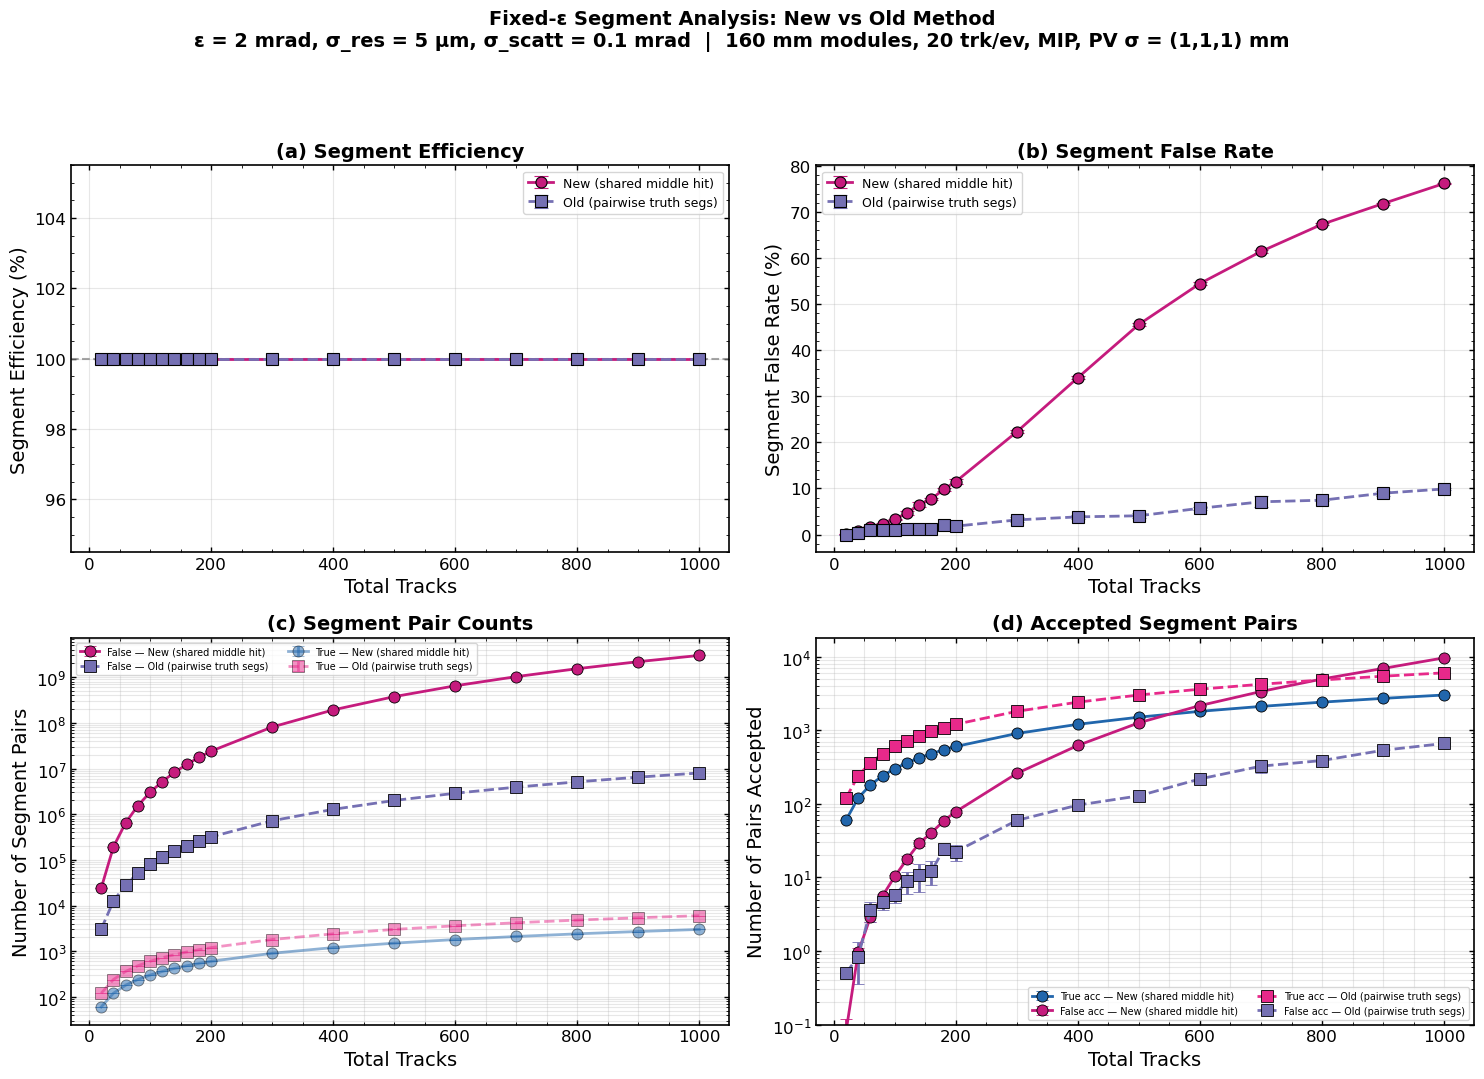


COMPARISON: New (shared middle hit) vs Old (pairwise truth segments)
Tracks   FR (New)         FR (Old)         Eff (New)      Eff (Old)     
------------------------------------------------------------------------------------------
20         0.13%            0.00%          100.00%       100.00%
40         0.79%            0.33%          100.00%       100.00%
60         1.56%            0.94%          100.00%       100.00%
80         2.28%            0.93%          100.00%       100.00%
100        3.32%            0.92%          100.00%       100.00%
120        4.66%            1.19%          100.00%       100.00%
140        6.47%            1.25%          100.00%       100.00%
160        7.74%            1.24%          100.00%       100.00%
180        9.78%            2.15%          100.00%       100.00%
200       11.49%            1.81%          100.00%       100.00%
300       22.31%            3.17%          100.00%       100.00%
400       34.06%            3.83%          100.00% 

In [20]:
# ============================================================================
# 10 vs 10b: COMPARISON PLOT — New (shared middle hit) vs Old (pairwise truth)
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

if len(segment_efficiency_results) > 0 and len(seg_eff_oldparams) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle('Fixed-ε Segment Analysis: New vs Old Method\n'
                 'ε = 2 mrad, σ_res = 5 µm, σ_scatt = 0.1 mrad  |  '
                 '160 mm modules, 20 trk/ev, MIP, PV σ = (1,1,1) mm',
                 fontsize=14, fontweight='bold')

    def _extract(results):
        tc  = np.array([r['total_tracks'] for r in results])
        eff = np.array([r['seg_efficiency_mean'] * 100 for r in results])
        effe= np.array([r['seg_efficiency_se'] * 100 for r in results])
        fr  = np.array([r['seg_false_rate_mean'] * 100 for r in results])
        fre = np.array([r['seg_false_rate_se'] * 100 for r in results])
        ntm = np.array([r['n_true_mean'] for r in results])
        nts = np.array([r['n_true_se'] for r in results])
        nfm = np.array([r['n_false_mean'] for r in results])
        nfs = np.array([r['n_false_se'] for r in results])
        tam = np.array([r['true_acc_mean'] for r in results])
        tas = np.array([r['true_acc_se'] for r in results])
        fam = np.array([r['false_acc_mean'] for r in results])
        fas = np.array([r['false_acc_se'] for r in results])
        return tc, eff, effe, fr, fre, ntm, nts, nfm, nfs, tam, tas, fam, fas

    new = _extract(segment_efficiency_results)
    old = _extract(seg_eff_oldparams)

    c_new   = '#c51b7d'  # magenta — new (triplet / shared middle hit)
    c_old   = '#7570b3'  # lilac  — old (pairwise truth)
    c_new_t = '#2166ac'
    c_old_t = '#e7298a'

    lbl_new = 'New (shared middle hit)'
    lbl_old = 'Old (pairwise truth segs)'

    # ── (a) Segment Efficiency ──
    ax = axes[0, 0]
    ax.errorbar(new[0], new[1], yerr=new[2], fmt='o-',  color=c_new, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_new)
    ax.errorbar(old[0], old[1], yerr=old[2], fmt='s--', color=c_old, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_old)
    ax.axhline(100, color='gray', ls='--', lw=1.5, alpha=0.7)
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Segment Efficiency (%)')
    ax.set_title('(a) Segment Efficiency', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ── (b) False Rate ──
    ax = axes[0, 1]
    ax.errorbar(new[0], new[3], yerr=new[4], fmt='o-',  color=c_new, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_new)
    ax.errorbar(old[0], old[3], yerr=old[4], fmt='s--', color=c_old, capsize=5,
                capthick=1.5, markeredgecolor='black', markeredgewidth=0.8, label=lbl_old)
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Segment False Rate (%)')
    ax.set_title('(b) Segment False Rate', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ── (c) Segment Pair Counts (false) ──
    ax = axes[1, 0]
    ax.errorbar(new[0], new[7], yerr=new[8], fmt='o-', color=c_new, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'False — {lbl_new}')
    ax.errorbar(old[0], old[7], yerr=old[8], fmt='s--', color=c_old, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'False — {lbl_old}')
    ax.errorbar(new[0], new[5], yerr=new[6], fmt='o-', color=c_new_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.5,
                label=f'True — {lbl_new}')
    ax.errorbar(old[0], old[5], yerr=old[6], fmt='s--', color=c_old_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6, alpha=0.5,
                label=f'True — {lbl_old}')
    ax.set_yscale('log')
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Number of Segment Pairs')
    ax.set_title('(c) Segment Pair Counts', fontweight='bold')
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    ax.grid(True, alpha=0.3, which='both')
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    # ── (d) Accepted Pairs ──
    ax = axes[1, 1]
    ax.errorbar(new[0], new[9], yerr=new[10], fmt='o-', color=c_new_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'True acc — {lbl_new}')
    fa_new = np.where(new[11] > 0, new[11], 0.5)
    ax.errorbar(new[0], fa_new, yerr=np.where(new[11] > 0, new[12], 0), fmt='o-',
                color=c_new, capsize=4, capthick=1.2, markeredgecolor='black',
                markeredgewidth=0.6, label=f'False acc — {lbl_new}')
    ax.errorbar(old[0], old[9], yerr=old[10], fmt='s--', color=c_old_t, capsize=4,
                capthick=1.2, markeredgecolor='black', markeredgewidth=0.6,
                label=f'True acc — {lbl_old}')
    fa_old = np.where(old[11] > 0, old[11], 0.5)
    ax.errorbar(old[0], fa_old, yerr=np.where(old[11] > 0, old[12], 0), fmt='s--',
                color=c_old, capsize=4, capthick=1.2, markeredgecolor='black',
                markeredgewidth=0.6, label=f'False acc — {lbl_old}')
    ax.set_yscale('log')
    ax.set_xlabel('Total Tracks')
    ax.set_ylabel('Number of Pairs Accepted')
    ax.set_title('(d) Accepted Segment Pairs', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right', ncol=2)
    ax.grid(True, alpha=0.3, which='both')
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_ylim(0.1, None)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUT_DIR / 'fixed_epsilon_comparison_new_vs_old.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    fig.savefig(OUT_DIR / 'fixed_epsilon_comparison_new_vs_old.pdf',
                bbox_inches='tight', facecolor='white')
    plt.show()

    # ── Difference table ──
    print("\n" + "=" * 90)
    print("COMPARISON: New (shared middle hit) vs Old (pairwise truth segments)")
    print("=" * 90)
    print(f"{'Tracks':<8} {'FR (New)':<16} {'FR (Old)':<16} "
          f"{'Eff (New)':<14} {'Eff (Old)':<14}")
    print("-" * 90)
    for rn in segment_efficiency_results:
        tc = rn['total_tracks']
        m_old = [ro for ro in seg_eff_oldparams if ro['total_tracks'] == tc]
        fn = rn['seg_false_rate_mean'] * 100
        en = rn['seg_efficiency_mean'] * 100
        fo = m_old[0]['seg_false_rate_mean'] * 100 if m_old else float('nan')
        eo = m_old[0]['seg_efficiency_mean'] * 100 if m_old else float('nan')
        print(f"{tc:<8} {fn:6.2f}%          {fo:6.2f}%          "
              f"{en:6.2f}%       {eo:6.2f}%")

In [21]:
# ============================================================================
# Parameter comparison table — New vs Old segment metrics
# ============================================================================
import pandas as pd

params = [
    ("Angle method",        "Triplet kink (shared middle hit)",  "Pairwise segment direction vectors"),
    ("ε threshold",         f"{FIXED_EPSILON*1000:.1f} mrad",    f"{FIXED_EPSILON*1000:.1f} mrad"),
    ("σ_res",               f"{FIXED_RESOLUTION} mm",            f"{FIXED_RESOLUTION} mm"),
    ("σ_scatt",             f"{FIXED_SCATTERING} rad",           f"{FIXED_SCATTERING} rad"),
    ("Module half-width",   f"{_NEW_HALF} mm → {_NEW_HALF*2} mm full",
                            f"{OLD_HALF_X} mm → {OLD_HALF_X*2} mm full"),
    ("N modules",           str(N_MODULES),                      str(OLD_N_MODULES)),
    ("z positions (mm)",    str(z_positions),                     str(old_z_positions)),
    ("PV sigma (mm)",       str(NEW_PV_SIGMA),                   str(OLD_PV_SIGMA)),
    ("Tracks per event",    str(TRACKS_PER_EVENT),               str(OLD_TRACKS_PER_EVENT)),
    ("φ range (rad)",       "−0.2 to +0.2",                     "−0.2 to +0.2"),
    ("θ range (rad)",       "default (−0.2 to +0.2)",           "default (−0.2 to +0.2)"),
    ("Particle type",       "MIP, mass=0.511, q=1",              "MIP, mass=0.511, q=1"),
    ("Repeats",             "50 (≤100T), 10 (101–500T), 5 (>500T)",
                            "50 (≤100T), 10 (101–500T), 5 (>500T)"),
    ("Track count range",   f"{FIXED_TRACK_COUNTS[0]}–{FIXED_TRACK_COUNTS[-1]}",
                            f"{OLD_EVENT_COUNTS[0]*OLD_TRACKS_PER_EVENT}–{OLD_EVENT_COUNTS[-1]*OLD_TRACKS_PER_EVENT}"),
    ("Segment truth def",   "Both segments on same track, share middle hit",
                            "Both segments from same track (truth-only pool)"),
    ("False pair scaling",  "O(T³)",                             "O(T²)"),
]

df = pd.DataFrame(params, columns=["Parameter", "New (§10)", "Old (§10b)"])

# Check which parameters match
match_col = []
for _, new_val, old_val in params:
    match_col.append("✓" if new_val == old_val else "✗ DIFFERS")
df["Match?"] = match_col

print("=" * 100)
print("PARAMETER COMPARISON: New (§10) vs Old (§10b)")
print("=" * 100)

def highlight_diff(row):
    # if row["Match?"] == "✗ DIFFERS":
    #     return ['background-color: #fff3cd'] * len(row)
    return [''] * len(row)

styled = df.style.apply(highlight_diff, axis=1).set_properties(**{
    'text-align': 'left', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
])
display(styled)

PARAMETER COMPARISON: New (§10) vs Old (§10b)


,Parameter,New (§10),Old (§10b),Match?
0,Angle method,Triplet kink (shared middle hit),Pairwise segment direction vectors,✗ DIFFERS
1,ε threshold,2.0 mrad,2.0 mrad,✓
2,σ_res,0.005 mm,0.005 mm,✓
3,σ_scatt,0.0001 rad,0.0001 rad,✓
4,Module half-width,80.0 mm → 160.0 mm full,80.0 mm → 160.0 mm full,✓
5,N modules,5,5,✓
6,z positions (mm),"[33.0, 66.0, 99.0, 132.0, 165.0]","[33.0, 66.0, 99.0, 132.0, 165.0]",✓
7,PV sigma (mm),"{'x': 1, 'y': 1, 'z': 1}","{'x': 1, 'y': 1, 'z': 1}",✓
8,Tracks per event,20,20,✓
9,φ range (rad),−0.2 to +0.2,−0.2 to +0.2,✓


### 10c. Power-Law Fits — Verifying $O(T^3)$ vs $O(T^2)$ Scaling

The **new** method (shared middle hit) enumerates all hit triplets on 3 consecutive
modules → $\sim T^3$ false pairs. The **old** method (pairwise truth segments) pairs
truth-track segments → $\sim T^2$ false pairs.

Fitting $N_\text{false} = a \, T^b$ should yield $b \approx 3$ for new and $b \approx 2$
for old. The number of **accepted** false pairs (passing the $\varepsilon$ cut) should
inherit the same exponent if the acceptance probability per false pair is roughly constant
with track multiplicity.

POWER-LAW FITS:  y = a · T^b

── False Pair COUNTS (total enumerated) ──
  New (shared mid hit): N_false                  a = 2.9999e+00 ± 3.45e-08,  b = 3.0000 ± 0.0000
  Old (pairwise truth): N_false                  a = 7.9041e+00 ± 2.05e-05,  b = 2.0016 ± 0.0000

── False Pair ACCEPTED (passing ε cut) ──
  New (shared mid hit): N_false_accepted         a = 1.1740e-05 ± 6.16e-07,  b = 2.9705 ± 0.0080
  Old (pairwise truth): N_false_accepted         a = 4.5762e-04 ± 1.29e-04,  b = 2.0481 ± 0.0424

── True Pair COUNTS ──
  New (shared mid hit): N_true                   a = 3.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0004
  Old (pairwise truth): N_true                   a = 6.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0002

── True Pair ACCEPTED ──
  New (shared mid hit): N_true_accepted          a = 3.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0004
  Old (pairwise truth): N_true_accepted          a = 6.0000e+00 ± 7.77e-03,  b = 1.0000 ± 0.0002

Quantity                            New (shared mid)     

/tmp/ipykernel_268181/2604545249.py:7: RuntimeWarning: overflow encountered in power
  return a * T**b


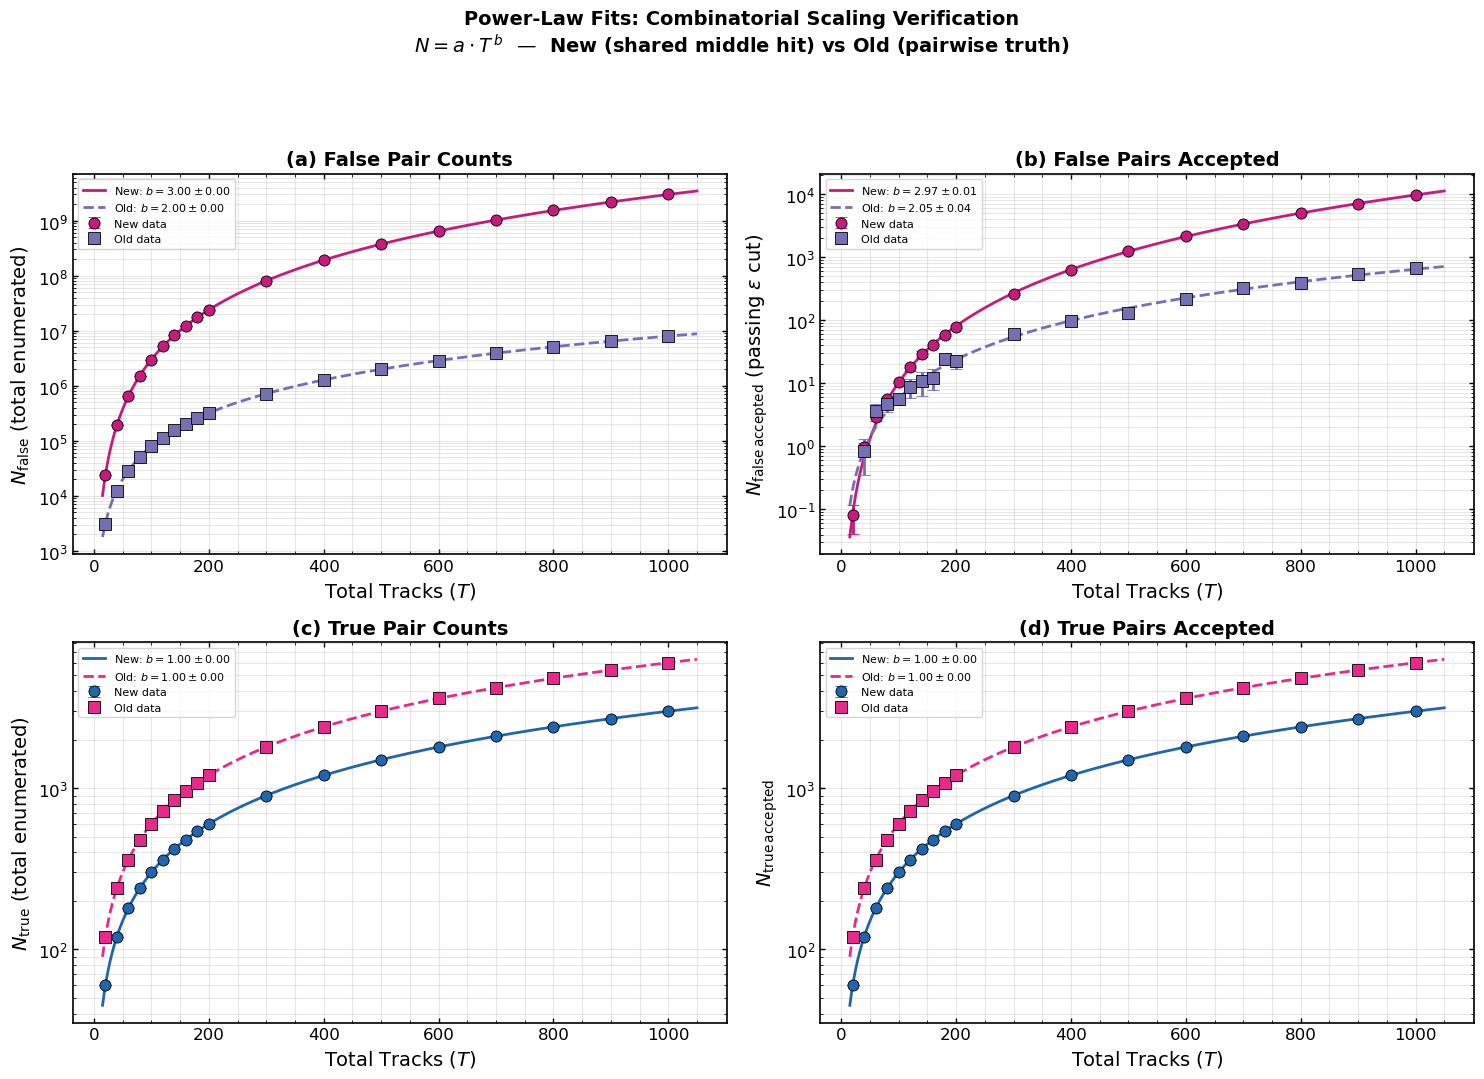

In [22]:
# ============================================================================
# 10c. Power-law fits: N_false ~ a·T^b  and  N_false_accepted ~ a·T^b
# ============================================================================
from scipy.optimize import curve_fit

def power_law(T, a, b):
    return a * T**b

def _extract_for_fit(results):
    tc  = np.array([r['total_tracks'] for r in results], dtype=float)
    nfm = np.array([r['n_false_mean'] for r in results], dtype=float)
    nfs = np.array([r['n_false_se'] for r in results], dtype=float)
    fam = np.array([r['false_acc_mean'] for r in results], dtype=float)
    fas = np.array([r['false_acc_se'] for r in results], dtype=float)
    ntm = np.array([r['n_true_mean'] for r in results], dtype=float)
    nts = np.array([r['n_true_se'] for r in results], dtype=float)
    tam = np.array([r['true_acc_mean'] for r in results], dtype=float)
    tas = np.array([r['true_acc_se'] for r in results], dtype=float)
    return tc, nfm, nfs, fam, fas, ntm, nts, tam, tas

new_tc, new_nf, new_nfs, new_fa, new_fas, new_nt, new_nts, new_ta, new_tas = \
    _extract_for_fit(segment_efficiency_results)
old_tc, old_nf, old_nfs, old_fa, old_fas, old_nt, old_nts, old_ta, old_tas = \
    _extract_for_fit(seg_eff_oldparams)

def _fit(tc, y, ys, label):
    mask = y > 0
    tc_f, y_f, ys_f = tc[mask], y[mask], ys[mask]
    sig = np.where(ys_f > 0, ys_f, 1.0)
    popt, pcov = curve_fit(power_law, tc_f, y_f, p0=[1.0, 2.0], sigma=sig,
                           absolute_sigma=True, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    print(f"  {label:<45s}  a = {popt[0]:.4e} ± {perr[0]:.2e},  "
          f"b = {popt[1]:.4f} ± {perr[1]:.4f}")
    return popt, perr, tc_f, y_f

print("=" * 100)
print("POWER-LAW FITS:  y = a · T^b")
print("=" * 100)
print()
print("── False Pair COUNTS (total enumerated) ──")
fit_new_nf = _fit(new_tc, new_nf, new_nfs, "New (shared mid hit): N_false")
fit_old_nf = _fit(old_tc, old_nf, old_nfs, "Old (pairwise truth): N_false")
print()
print("── False Pair ACCEPTED (passing ε cut) ──")
fit_new_fa = _fit(new_tc, new_fa, new_fas, "New (shared mid hit): N_false_accepted")
fit_old_fa = _fit(old_tc, old_fa, old_fas, "Old (pairwise truth): N_false_accepted")
print()
print("── True Pair COUNTS ──")
fit_new_nt = _fit(new_tc, new_nt, new_nts, "New (shared mid hit): N_true")
fit_old_nt = _fit(old_tc, old_nt, old_nts, "Old (pairwise truth): N_true")
print()
print("── True Pair ACCEPTED ──")
fit_new_ta = _fit(new_tc, new_ta, new_tas, "New (shared mid hit): N_true_accepted")
fit_old_ta = _fit(old_tc, old_ta, old_tas, "Old (pairwise truth): N_true_accepted")

# ── Summary table ──
print()
print("=" * 90)
print(f"{'Quantity':<35s} {'New (shared mid)':<22s} {'Old (pair truth)':<22s} {'Expected':<15s}")
print("-" * 90)
rows = [
    ("N_false (total)",  fit_new_nf,  fit_old_nf,  "3 / 2"),
    ("N_false_accepted", fit_new_fa,  fit_old_fa,  "~3 / ~2"),
    ("N_true (total)",   fit_new_nt,  fit_old_nt,  "1 / 1"),
    ("N_true_accepted",  fit_new_ta,  fit_old_ta,  "1 / 1"),
]
for label, fn, fo, expected in rows:
    print(f"{label:<35s} {fn[0][1]:.3f} ± {fn[1][1]:.3f}         "
          f"{fo[0][1]:.3f} ± {fo[1][1]:.3f}         {expected}")
print("=" * 90)

# ── Plot with fits overlaid ──
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Power-Law Fits: Combinatorial Scaling Verification\n'
             r'$N = a \cdot T^{\,b}$  —  New (shared middle hit) vs Old (pairwise truth)',
             fontsize=14, fontweight='bold')

T_smooth = np.linspace(15, 1050, 300)

c_new   = '#c51b7d'
c_old   = '#7570b3'
c_new_t = '#2166ac'
c_old_t = '#e7298a'

# (a) False pair counts
ax = axes[0, 0]
ax.errorbar(new_tc, new_nf, yerr=new_nfs, fmt='o', color=c_new, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_nf[0]), '-', color=c_new, lw=2,
        label=f'New: $b = {fit_new_nf[0][1]:.2f} \\pm {fit_new_nf[1][1]:.2f}$')
ax.errorbar(old_tc, old_nf, yerr=old_nfs, fmt='s', color=c_old, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_nf[0]), '--', color=c_old, lw=2,
        label=f'Old: $b = {fit_old_nf[0][1]:.2f} \\pm {fit_old_nf[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{false}$ (total enumerated)')
ax.set_title('(a) False Pair Counts', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# (b) False accepted
ax = axes[0, 1]
ax.errorbar(new_tc, new_fa, yerr=new_fas, fmt='o', color=c_new, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_fa[0]), '-', color=c_new, lw=2,
        label=f'New: $b = {fit_new_fa[0][1]:.2f} \\pm {fit_new_fa[1][1]:.2f}$')
ax.errorbar(old_tc, old_fa, yerr=old_fas, fmt='s', color=c_old, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_fa[0]), '--', color=c_old, lw=2,
        label=f'Old: $b = {fit_old_fa[0][1]:.2f} \\pm {fit_old_fa[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{false\\,accepted}$ (passing $\\varepsilon$ cut)')
ax.set_title('(b) False Pairs Accepted', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# (c) True pair counts
ax = axes[1, 0]
ax.errorbar(new_tc, new_nt, yerr=new_nts, fmt='o', color=c_new_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_nt[0]), '-', color=c_new_t, lw=2,
        label=f'New: $b = {fit_new_nt[0][1]:.2f} \\pm {fit_new_nt[1][1]:.2f}$')
ax.errorbar(old_tc, old_nt, yerr=old_nts, fmt='s', color=c_old_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_nt[0]), '--', color=c_old_t, lw=2,
        label=f'Old: $b = {fit_old_nt[0][1]:.2f} \\pm {fit_old_nt[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{true}$ (total enumerated)')
ax.set_title('(c) True Pair Counts', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

# (d) True accepted
ax = axes[1, 1]
ax.errorbar(new_tc, new_ta, yerr=new_tas, fmt='o', color=c_new_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='New data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_new_ta[0]), '-', color=c_new_t, lw=2,
        label=f'New: $b = {fit_new_ta[0][1]:.2f} \\pm {fit_new_ta[1][1]:.2f}$')
ax.errorbar(old_tc, old_ta, yerr=old_tas, fmt='s', color=c_old_t, capsize=4,
            markeredgecolor='black', markeredgewidth=0.6, label='Old data', zorder=5)
ax.plot(T_smooth, power_law(T_smooth, *fit_old_ta[0]), '--', color=c_old_t, lw=2,
        label=f'Old: $b = {fit_old_ta[0][1]:.2f} \\pm {fit_old_ta[1][1]:.2f}$')
ax.set_yscale('log')
ax.set_xlabel('Total Tracks ($T$)')
ax.set_ylabel('$N_\\mathrm{true\\,accepted}$')
ax.set_title('(d) True Pairs Accepted', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / 'scaling_power_law_fits_new_vs_old.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(OUT_DIR / 'scaling_power_law_fits_new_vs_old.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()

In [23]:
# ============================================================================
# Parameter comparison table — Power-law fits (New vs Old)
# ============================================================================
params_pl = [
    ("Angle method",        "Triplet kink (shared middle hit)",  "Pairwise segment direction vectors"),
    ("ε threshold",         f"{FIXED_EPSILON*1000:.1f} mrad",    f"{FIXED_EPSILON*1000:.1f} mrad"),
    ("σ_res",               f"{FIXED_RESOLUTION} mm",            f"{FIXED_RESOLUTION} mm"),
    ("σ_scatt",             f"{FIXED_SCATTERING} rad",           f"{FIXED_SCATTERING} rad"),
    ("Module half-width",   f"{_NEW_HALF} mm → {_NEW_HALF*2} mm full",
                            f"{OLD_HALF_X} mm → {OLD_HALF_X*2} mm full"),
    ("N modules",           str(N_MODULES),                      str(OLD_N_MODULES)),
    ("z positions (mm)",    str(z_positions),                     str(old_z_positions)),
    ("PV sigma (mm)",       str(NEW_PV_SIGMA),                   str(OLD_PV_SIGMA)),
    ("Tracks per event",    str(TRACKS_PER_EVENT),               str(OLD_TRACKS_PER_EVENT)),
    ("φ range (rad)",       "−0.2 to +0.2",                     "−0.2 to +0.2"),
    ("θ range (rad)",       "default (−0.2 to +0.2)",           "default (−0.2 to +0.2)"),
    ("Particle type",       "MIP, mass=0.511, q=1",              "MIP, mass=0.511, q=1"),
    ("Track count range",   f"{FIXED_TRACK_COUNTS[0]}–{FIXED_TRACK_COUNTS[-1]}",
                            f"{OLD_EVENT_COUNTS[0]*OLD_TRACKS_PER_EVENT}–{OLD_EVENT_COUNTS[-1]*OLD_TRACKS_PER_EVENT}"),
    ("Segment truth def",   "Both segments on same track, share middle hit",
                            "Both segments from same track (truth-only pool)"),
    ("False pair scaling",  "O(T³)",                             "O(T²)"),
]

df_pl = pd.DataFrame(params_pl, columns=["Parameter", "New (§10)", "Old (§10b)"])
match_pl = []
for _, nv, ov in params_pl:
    match_pl.append("✓" if nv == ov else "✗ DIFFERS")
df_pl["Match?"] = match_pl

print("=" * 100)
print("PARAMETER COMPARISON: Power-law fits — New (§10) vs Old (§10b)")
print("=" * 100)

styled_pl = df_pl.style.apply(highlight_diff, axis=1).set_properties(**{
    'text-align': 'left', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
])
display(styled_pl)

PARAMETER COMPARISON: Power-law fits — New (§10) vs Old (§10b)


,Parameter,New (§10),Old (§10b),Match?
0,Angle method,Triplet kink (shared middle hit),Pairwise segment direction vectors,✗ DIFFERS
1,ε threshold,2.0 mrad,2.0 mrad,✓
2,σ_res,0.005 mm,0.005 mm,✓
3,σ_scatt,0.0001 rad,0.0001 rad,✓
4,Module half-width,80.0 mm → 160.0 mm full,80.0 mm → 160.0 mm full,✓
5,N modules,5,5,✓
6,z positions (mm),"[33.0, 66.0, 99.0, 132.0, 165.0]","[33.0, 66.0, 99.0, 132.0, 165.0]",✓
7,PV sigma (mm),"{'x': 1, 'y': 1, 'z': 1}","{'x': 1, 'y': 1, 'z': 1}",✓
8,Tracks per event,20,20,✓
9,φ range (rad),−0.2 to +0.2,−0.2 to +0.2,✓


## 11. Zero-Noise Benchmark: Dense vs Non-Dense

Ideal case with zero scattering and zero resolution error. At zero noise, ε reduces to √2·θ_min.

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks × regime |
| n_tracks | 5–100 (step 5) |
| σ_scatt | ≈ 0 (1 × 10⁻⁸ rad) |
| σ_res | 0.0 mm |
| Dense (φ_max) | 0.02 rad |
| Non-dense (φ_max) | 0.2 rad |
| ε mode | **Formula** (≈ √2·θ_min ≈ 0.064 mrad) |
| Repeats per point | 20 |

In [24]:
# ============================================================================
# ZERO-NOISE BENCHMARK: Dense vs Non-Dense
# ============================================================================
ZERO_TRACK_COUNTS = list(range(5, 105, 5))
ZERO_N_REPEATS    = 20
ZERO_SIGMA_RES    = 0.0
ZERO_SIGMA_SCATT  = 1e-8   # effectively zero (generator needs non-zero)
ZERO_CONE_SETTINGS = {
    "dense": 0.02,
    "non_dense":     0.2,
}

epsilon_zero = compute_epsilon(ZERO_SIGMA_RES, ZERO_SIGMA_SCATT)
print(f"Zero-noise ε = {epsilon_zero*1e3:.4f} mrad  (≈ √2 · θ_min)")
print(f"Track counts: {ZERO_TRACK_COUNTS[0]}–{ZERO_TRACK_COUNTS[-1]}, "
      f"{ZERO_N_REPEATS} repeats/point")

_cache_file = CACHE_DIR / "df_zero_noise.csv"
if _cache_file.exists():
    df_zero = pd.read_csv(_cache_file)
    print(f"Loaded df_zero from cache: {len(df_zero)} rows")
else:
    rows = []
    for label, phi_max in ZERO_CONE_SETTINGS.items():
        print(f"\n── {label} (φ_max = {phi_max}) ──")
        for n_trk in ZERO_TRACK_COUNTS:
            for rep in range(ZERO_N_REPEATS):
                np.random.seed(rep + n_trk * 100 + hash(label) % 10**6)
                event = safe_generate(n_trk, measurement_error=ZERO_SIGMA_RES,
                                      collision_noise=ZERO_SIGMA_SCATT,
                                      phi_max=phi_max, theta_max=phi_max)
                m = fast_segment_metrics(event, epsilon_zero)
                rows.append({
                    "regime": label,
                    "phi_max": phi_max,
                    "n_tracks": n_trk,
                    "repeat": rep,
                    "epsilon": epsilon_zero,
                    "n_true": m["n_true"],
                    "n_false": m["n_false"],
                    "true_accepted": m["true_accepted"],
                    "false_accepted": m["false_accepted"],
                    "seg_efficiency": m["segment_efficiency"],
                    "seg_false_rate": m["segment_false_rate"],
                })
            print(f"  n_tracks={n_trk:3d}  done")

    df_zero = pd.DataFrame(rows)
    df_zero.to_csv(_cache_file, index=False)
    print(f"\n{len(df_zero)} rows collected & saved")

Zero-noise ε = 0.0212 mrad  (≈ √2 · θ_min)
Track counts: 5–100, 20 repeats/point
Loaded df_zero from cache: 800 rows


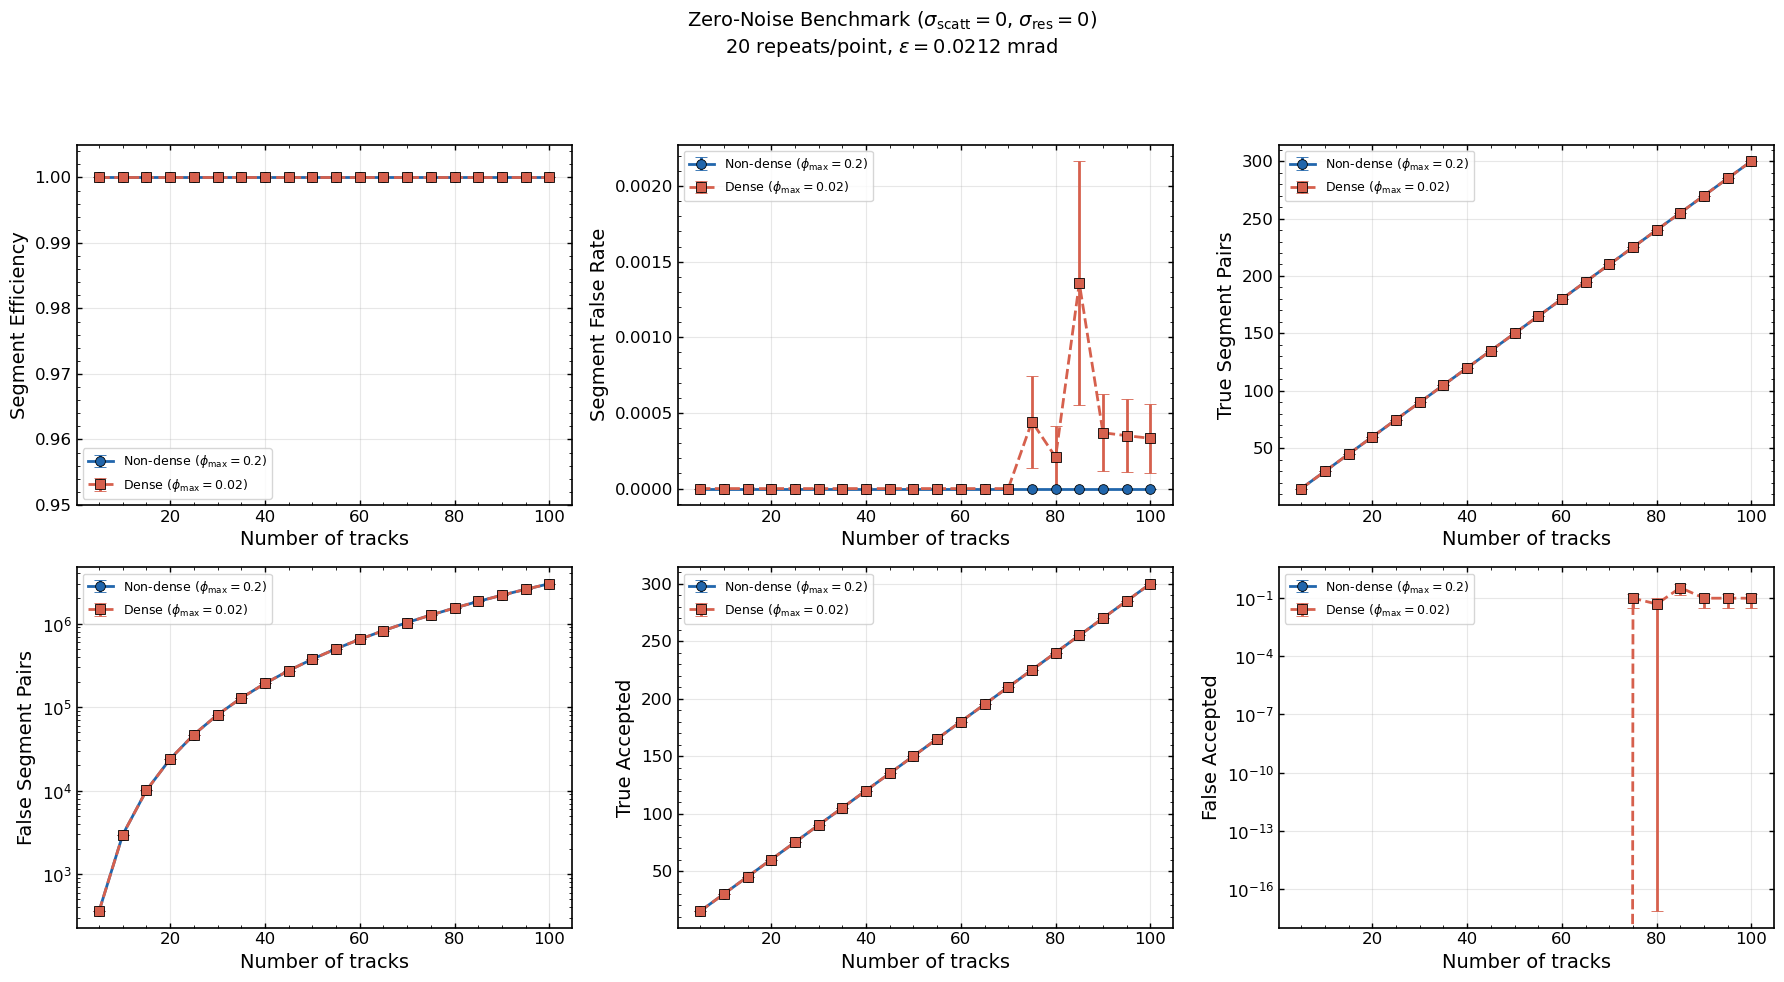


ZERO-NOISE BENCHMARK SUMMARY (per-repeat mean ± SE)

── NON_DENSE (φ_max = 0.2) ──
Tracks   Seg Eff            False Rate         True Pairs       False Pairs      True Acc       False Acc     
----------------------------------------------------------------------------------------------------
5        100.00% ± 0.00%   0.00% ± 0.00%   15 ± 0.0    360 ± 0.0    15 ± 0.0  0.0 ± 0.0
10       100.00% ± 0.00%   0.00% ± 0.00%   30 ± 0.0    2970 ± 0.0    30 ± 0.0  0.0 ± 0.0
15       100.00% ± 0.00%   0.00% ± 0.00%   45 ± 0.0    10080 ± 0.0    45 ± 0.0  0.0 ± 0.0
20       100.00% ± 0.00%   0.00% ± 0.00%   60 ± 0.0    23940 ± 0.0    60 ± 0.0  0.0 ± 0.0
25       100.00% ± 0.00%   0.00% ± 0.00%   75 ± 0.0    46800 ± 0.0    75 ± 0.0  0.0 ± 0.0
30       100.00% ± 0.00%   0.00% ± 0.00%   90 ± 0.0    80910 ± 0.0    90 ± 0.0  0.0 ± 0.0
35       100.00% ± 0.00%   0.00% ± 0.00%   105 ± 0.0    128520 ± 0.0    105 ± 0.0  0.0 ± 0.0
40       100.00% ± 0.00%   0.00% ± 0.00%   120 ± 0.0    191880 ± 0.0    12

In [25]:
# ============================================================================
# ZERO-NOISE BENCHMARK: Visualization
# ============================================================================
regime_colors = {"non_dense": "#2166ac", "dense": "#d6604d"}
regime_labels = {"non_dense": r"Non-dense ($\phi_{\max}=0.2$)",
                 "dense":     r"Dense ($\phi_{\max}=0.02$)"}
regime_fmts   = {"non_dense": "o-", "dense": "s--"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(r"Zero-Noise Benchmark ($\sigma_{\mathrm{scatt}} = 0$, $\sigma_{\mathrm{res}} = 0$)"
             f"\n{ZERO_N_REPEATS} repeats/point, "
             rf"$\varepsilon = {epsilon_zero*1e3:.4f}$ mrad",
             fontsize=14)

metrics = [
    ("seg_efficiency", "Segment Efficiency", True),
    ("seg_false_rate", "Segment False Rate", True),
    ("n_true",         "True Segment Pairs", False),
    ("n_false",        "False Segment Pairs", False),
    ("true_accepted",  "True Accepted",       False),
    ("false_accepted", "False Accepted",       False),
]

for ax, (col, ylabel, is_frac) in zip(axes.flat, metrics):
    for regime in ["non_dense", "dense"]:
        sub = df_zero[df_zero["regime"] == regime]
        grp = sub.groupby("n_tracks")[col]
        mean = grp.mean()
        se   = grp.std(ddof=1) / np.sqrt(grp.count())

        ax.errorbar(mean.index, mean.values, yerr=se.values,
                    fmt=regime_fmts[regime], color=regime_colors[regime],
                    capsize=4, capthick=1.2, linewidth=2, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.6,
                    label=regime_labels[regime])

    ax.set_xlabel("Number of tracks")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)

    if col == "seg_efficiency":
        ax.set_ylim(0.95, 1.005)
    if col in ("n_false", "false_accepted"):
        ax.set_yscale("log")

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / 'zero_noise_benchmark.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'zero_noise_benchmark.pdf', bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "=" * 100)
print("ZERO-NOISE BENCHMARK SUMMARY (per-repeat mean ± SE)")
print("=" * 100)
for regime in ["non_dense", "dense"]:
    sub = df_zero[df_zero["regime"] == regime]
    print(f"\n── {regime.upper()} (φ_max = {ZERO_CONE_SETTINGS[regime]}) ──")
    print(f"{'Tracks':<8} {'Seg Eff':<18} {'False Rate':<18} "
          f"{'True Pairs':<16} {'False Pairs':<16} {'True Acc':<14} {'False Acc':<14}")
    print("-" * 100)
    for n_trk in ZERO_TRACK_COUNTS:
        s = sub[sub["n_tracks"] == n_trk]
        nr = len(s)
        eff = s["seg_efficiency"]
        fr  = s["seg_false_rate"]
        nt  = s["n_true"]
        nf  = s["n_false"]
        ta  = s["true_accepted"]
        fa  = s["false_accepted"]
        print(f"{n_trk:<8} "
              f"{eff.mean()*100:.2f}% ± {eff.std(ddof=1)/np.sqrt(nr)*100:.2f}%   "
              f"{fr.mean()*100:.2f}% ± {fr.std(ddof=1)/np.sqrt(nr)*100:.2f}%   "
              f"{nt.mean():.0f} ± {nt.std(ddof=1)/np.sqrt(nr):.1f}    "
              f"{nf.mean():.0f} ± {nf.std(ddof=1)/np.sqrt(nr):.1f}    "
              f"{ta.mean():.0f} ± {ta.std(ddof=1)/np.sqrt(nr):.1f}  "
              f"{fa.mean():.1f} ± {fa.std(ddof=1)/np.sqrt(nr):.1f}")

Saved to outputs/segment_analysis/zero_noise_benchmark_paper.png
Saved to outputs/segment_analysis/zero_noise_benchmark_paper.pdf


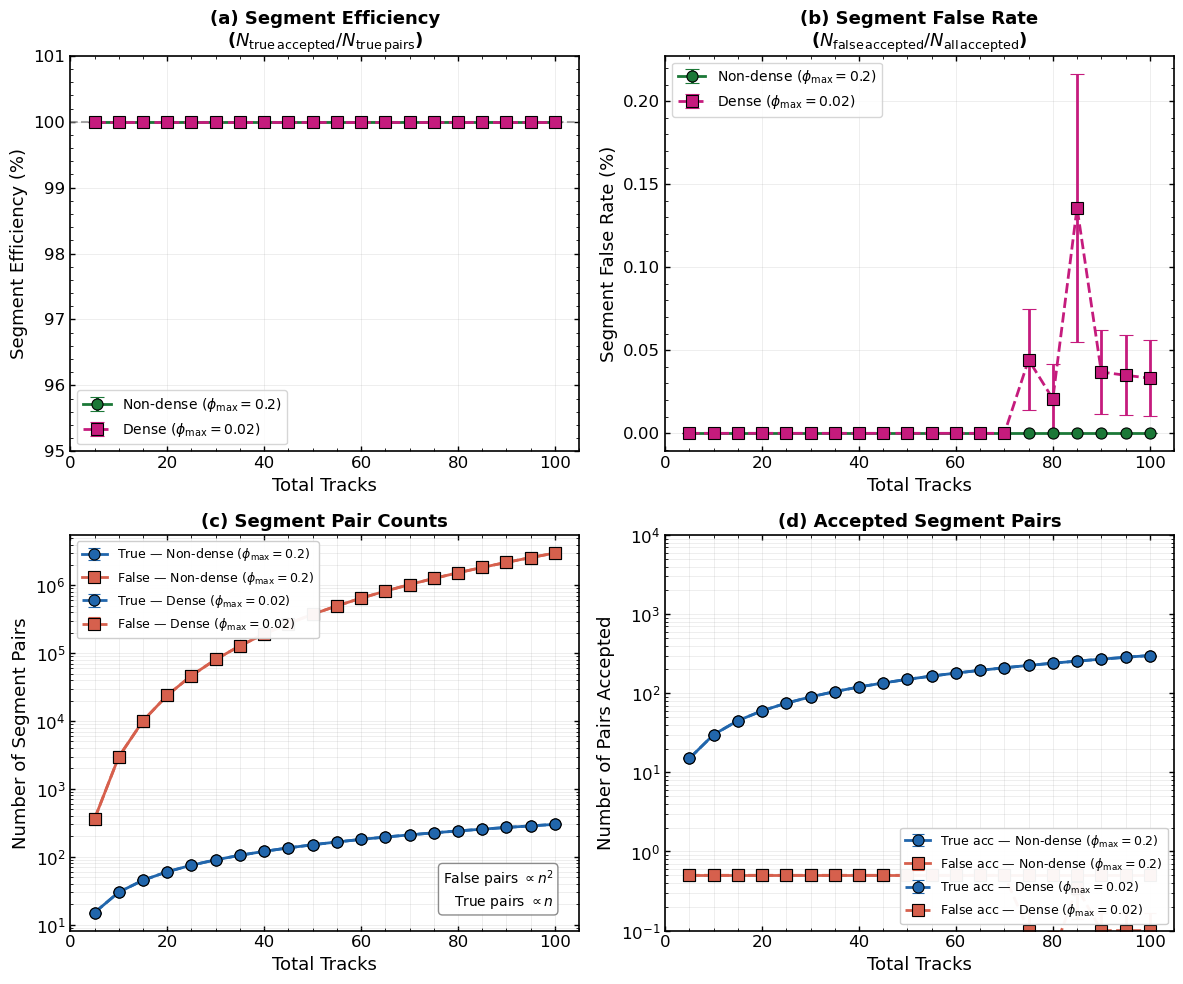

In [26]:
# ============================================================================
# ZERO-NOISE BENCHMARK: Paper-Ready 2×2 Plot (matching §10 style)
# ============================================================================

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'lines.linewidth': 2,
    'lines.markersize': 8,
})

# Aggregate per-repeat mean ± SE for each regime × track count
zero_plot_data = {}
for regime in ["non_dense", "dense"]:
    sub = df_zero[df_zero["regime"] == regime]
    agg = sub.groupby("n_tracks").agg(
        seg_eff_mean=("seg_efficiency", "mean"),
        seg_eff_se=("seg_efficiency", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_rate_mean=("seg_false_rate", "mean"),
        false_rate_se=("seg_false_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_true_mean=("n_true", "mean"),
        n_true_se=("n_true", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_false_mean=("n_false", "mean"),
        n_false_se=("n_false", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        true_acc_mean=("true_accepted", "mean"),
        true_acc_se=("true_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_acc_mean=("false_accepted", "mean"),
        false_acc_se=("false_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    zero_plot_data[regime] = agg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Color scheme — one per regime
colors = {"non_dense": '#1b7837', "dense": '#c51b7d'}
fmts   = {"non_dense": 'o-',     "dense": 's--'}
labels = {"non_dense": r'Non-dense ($\phi_{\max}=0.2$)',
          "dense":     r'Dense ($\phi_{\max}=0.02$)'}

# ── (a) Segment Efficiency ──
ax1 = axes[0, 0]
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    ax1.errorbar(d.index, d["seg_eff_mean"] * 100, yerr=d["seg_eff_se"] * 100,
                 fmt=fmts[regime], color=colors[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels[regime])
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Total Tracks', fontsize=13)
ax1.set_ylabel('Segment Efficiency (%)', fontsize=13)
ax1.set_title('(a) Segment Efficiency\n($N_{\\mathrm{true\\,accepted}} / N_{\\mathrm{true\\,pairs}}$)',
              fontsize=13, fontweight='bold')
ax1.set_ylim(95, 101)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.set_xlim(0, 105)

# ── (b) Segment False Rate ──
ax2 = axes[0, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    ax2.errorbar(d.index, d["false_rate_mean"] * 100, yerr=d["false_rate_se"] * 100,
                 fmt=fmts[regime], color=colors[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels[regime])
ax2.set_xlabel('Total Tracks', fontsize=13)
ax2.set_ylabel('Segment False Rate (%)', fontsize=13)
ax2.set_title('(b) Segment False Rate\n($N_{\\mathrm{false\\,accepted}} / N_{\\mathrm{all\\,accepted}}$)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.set_xlim(0, 105)

# ── (c) Segment Pair Counts ──
ax3 = axes[1, 0]
color_true = '#2166ac'
color_false = '#d6604d'
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    style = '-' if regime == "non_dense" else '--'
    ax3.errorbar(d.index, d["n_true_mean"], yerr=d["n_true_se"],
                 fmt='o' + style, color=color_true, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True — {labels[regime]}')
    ax3.errorbar(d.index, d["n_false_mean"], yerr=d["n_false_se"],
                 fmt='s' + style, color=color_false, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False — {labels[regime]}')
ax3.set_yscale('log')
ax3.set_xlabel('Total Tracks', fontsize=13)
ax3.set_ylabel('Number of Segment Pairs', fontsize=13)
ax3.set_title('(c) Segment Pair Counts', fontsize=13, fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)
ax3.set_xlim(0, 105)
ax3.text(0.95, 0.05, 'False pairs $\\propto n^2$\nTrue pairs $\\propto n$',
         transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# ── (d) Accepted Segment Pairs ──
ax4 = axes[1, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_data[regime]
    style = '-' if regime == "non_dense" else '--'
    ax4.errorbar(d.index, d["true_acc_mean"], yerr=d["true_acc_se"],
                 fmt='o' + style, color=color_true, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True acc — {labels[regime]}')
    false_acc_plot = np.where(d["false_acc_mean"] > 0, d["false_acc_mean"], 0.5)
    false_acc_se_plot = np.where(d["false_acc_mean"] > 0, d["false_acc_se"], 0)
    ax4.errorbar(d.index, false_acc_plot, yerr=false_acc_se_plot,
                 fmt='s' + style, color=color_false, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False acc — {labels[regime]}')
ax4.set_yscale('log')
ax4.set_xlabel('Total Tracks', fontsize=13)
ax4.set_ylabel('Number of Pairs Accepted', fontsize=13)
ax4.set_title('(d) Accepted Segment Pairs', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_xlim(0, 105)
ax4.set_ylim(0.1, 1e4)

plt.tight_layout()
fig.savefig(OUT_DIR / 'zero_noise_benchmark_paper.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(OUT_DIR / 'zero_noise_benchmark_paper.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
print(f"Saved to {OUT_DIR / 'zero_noise_benchmark_paper.png'}")
print(f"Saved to {OUT_DIR / 'zero_noise_benchmark_paper.pdf'}")
plt.show()

## 12. Extended Analysis — Up to 1000 Tracks

Replicates §5–§11 with track counts extended to 1000. Uses the Numba-accelerated
segment-metrics kernel (`fast_segment_metrics`, defined in §2b) to make O(T³) triplet
enumeration tractable.

All extended experiments use the same physics parameters as their standard counterparts
(see overview table above); only the track count ranges are extended.

In [27]:
# fast_segment_metrics is defined in §2b above — no need to re-define here.
print("fast_segment_metrics already available from §2b.")

fast_segment_metrics already available from §2b.


### 12b. Extended Scattering Sweep (extends §5)

| Parameter | Value |
|-----------|-------|
| Swept | σ_scatt × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100, **200, 500, 1000**] |
| σ_scatt | [0.05 – 1.0] mrad (7 values) |
| σ_res | 0.0 mm |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [28]:
# ============================================================================
# 12b. Extended Scattering Sweep Data Collection
# ============================================================================
import time as _time

TRACK_COUNTS_EXT   = [10, 20, 50, 100, 200, 500, 1000]
N_EVENTS_STATS_EXT = 10

TRACK_COLORS_EXT = {
    10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d",
    200: "#7570b3", 500: "#d95f02", 1000: "#e7298a",
}
TRACK_FMTS_EXT = {
    10: "o-", 20: "s--", 50: "D:", 100: "^-.",
    200: "v-", 500: "P--", 1000: "X:",
}

_cache_file = CACHE_DIR / "df_seg_scatt_ext.csv"
if _cache_file.exists():
    df_seg_scatt_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_scatt_ext from cache: {len(df_seg_scatt_ext)} rows")
else:
    seg_rows_ext = []
    t_start = _time.time()

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS_EXT:
            t0 = _time.time()
            for si_ext, sigma_s in enumerate(SIGMA_SCATT_VALUES):
                epsilon = compute_epsilon(0.0, sigma_s)
                for rep in range(N_EVENTS_STATS_EXT):
                    np.random.seed(rep + n_trk * 100 + si_ext * 10000 + 500000)
                    event = safe_generate(n_trk, measurement_error=0.0,
                                          collision_noise=sigma_s,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    seg_rows_ext.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_scatt": sigma_s,
                        "sigma_scatt_mrad": sigma_s * 1e3,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })
            dt = _time.time() - t0
            print(f"  phi_max={phi_max}  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_seg_scatt_ext = pd.DataFrame(seg_rows_ext)
    df_seg_scatt_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_scatt_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Loaded df_seg_scatt_ext from cache: 980 rows


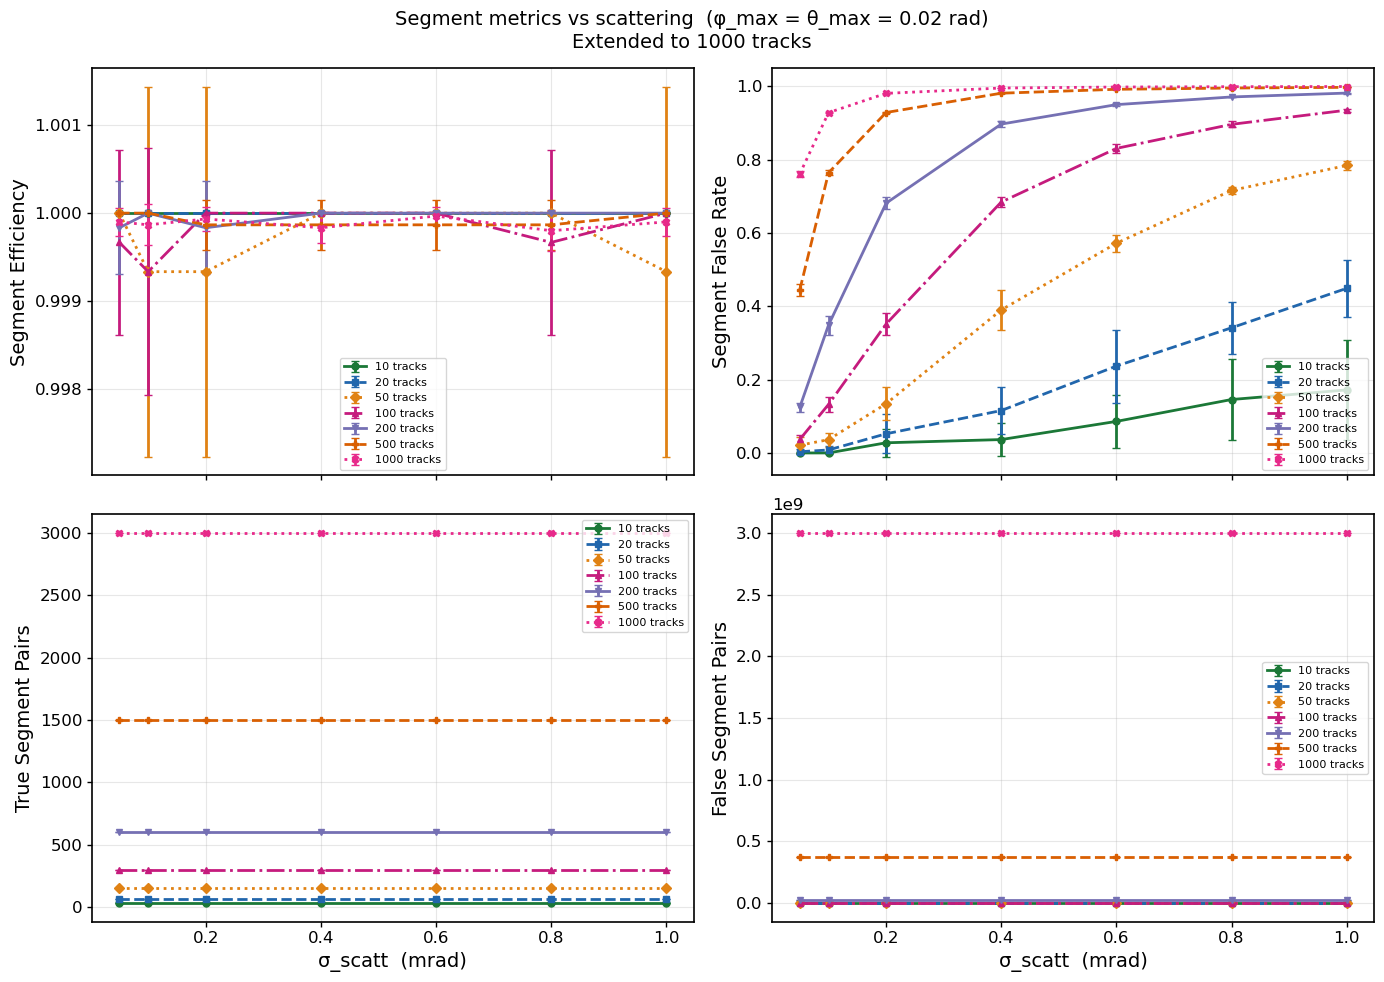

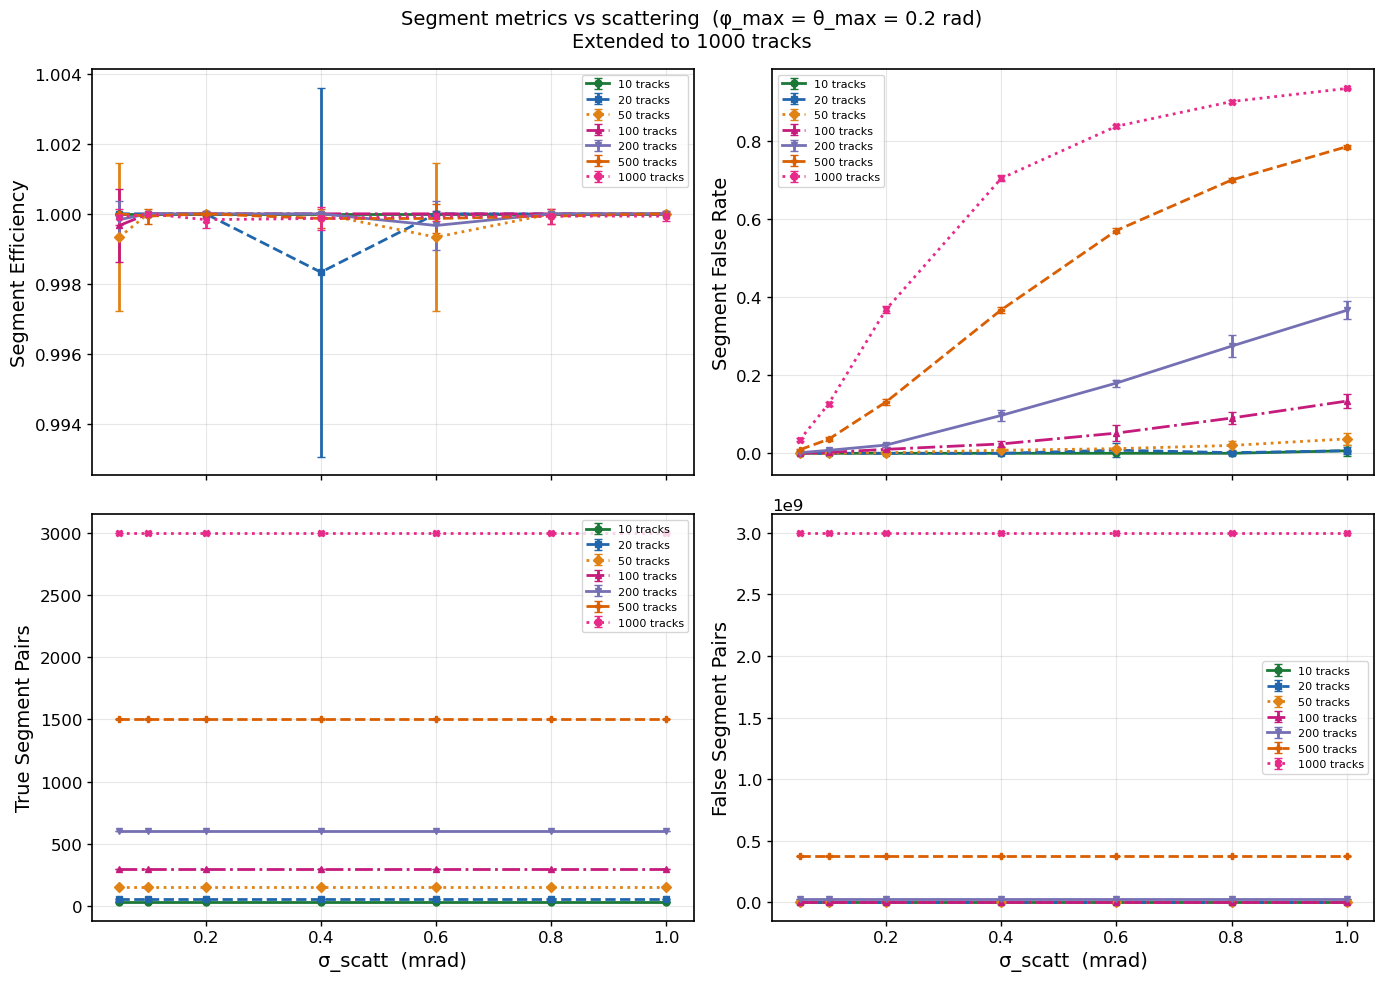

In [29]:
# ============================================================================
# 12b. Extended Scattering Sweep Plots
# ============================================================================
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_scatt_ext[df_seg_scatt_ext["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs scattering  (φ_max = θ_max = {phi_max} rad)"
                 f"\nExtended to 1000 tracks", fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",           "True Segment Pairs"),
               ("n_false",          "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS_EXT:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_scatt_mrad")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS_EXT[n_trk], color=TRACK_COLORS_EXT[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_scatt  (mrad)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'scattering_sweep_ext_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'scattering_sweep_ext_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

### 12c. Extended Resolution Sweep (extends §6)

| Parameter | Value |
|-----------|-------|
| Swept | σ_res × n_tracks × φ_max |
| n_tracks | [10, 20, 50, 100, **200, 500, 1000**] |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad, fixed) |
| σ_res | [0.0 – 0.05] mm (7 values) |
| φ_max = θ_max | [0.02, 0.2] rad |
| ε mode | **Formula** |
| Events per point | 10 |

In [30]:
# ============================================================================
# 12c. Extended Resolution Sweep Data Collection
# ============================================================================
_cache_file = CACHE_DIR / "df_seg_res_ext.csv"
if _cache_file.exists():
    df_seg_res_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_seg_res_ext from cache: {len(df_seg_res_ext)} rows")
else:
    res_rows_ext = []
    t_start = _time.time()

    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS_EXT:
            t0 = _time.time()
            for ri_ext, sigma_r in enumerate(SIGMA_RES_VALUES):
                epsilon = compute_epsilon(sigma_r, SIGMA_SCATT_FIXED)
                for rep in range(N_EVENTS_STATS_EXT):
                    np.random.seed(rep + n_trk * 100 + ri_ext * 10000 + 600000)
                    event = safe_generate(n_trk, measurement_error=sigma_r,
                                          collision_noise=SIGMA_SCATT_FIXED,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    res_rows_ext.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_res": sigma_r,
                        "sigma_res_mm": sigma_r,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })
            dt = _time.time() - t0
            print(f"  phi_max={phi_max}  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_seg_res_ext = pd.DataFrame(res_rows_ext)
    df_seg_res_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_seg_res_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Loaded df_seg_res_ext from cache: 980 rows


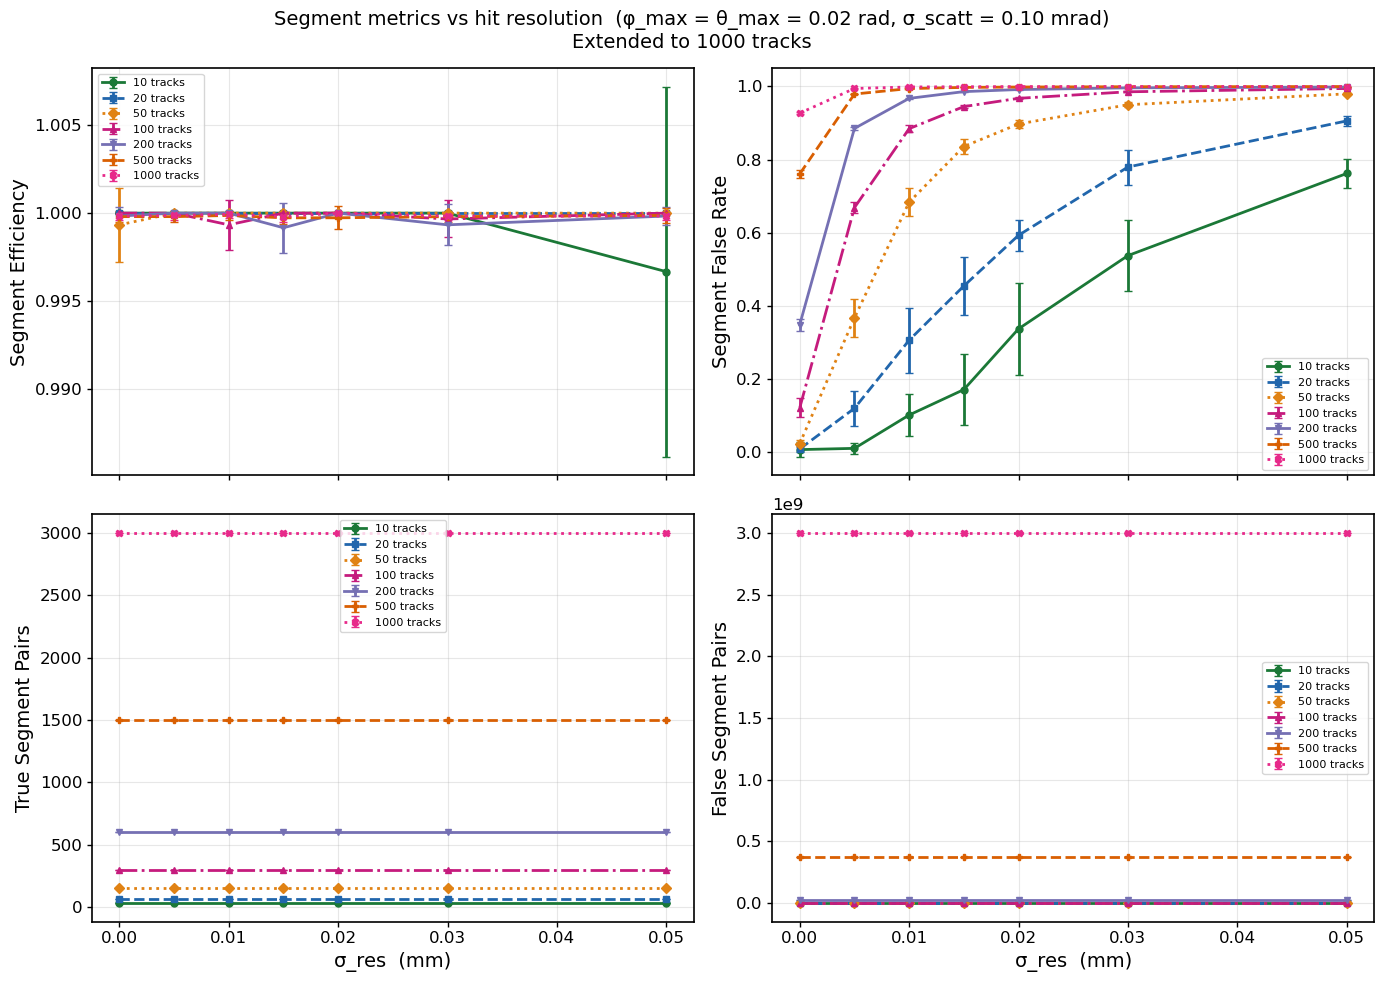

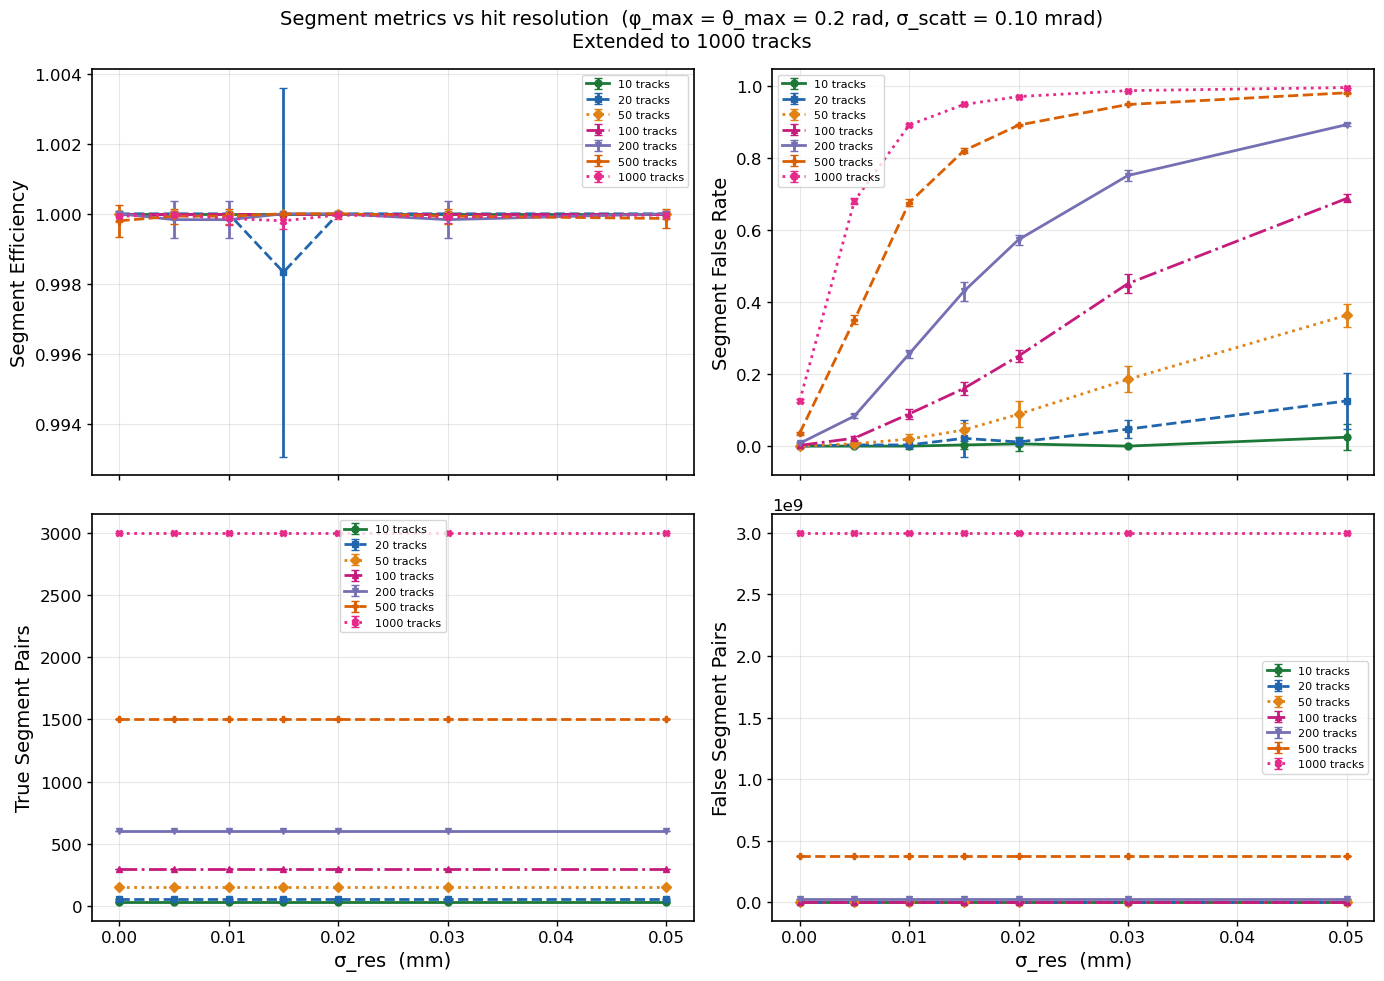

In [31]:
# ============================================================================
# 12c. Extended Resolution Sweep Plots
# ============================================================================
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_res_ext[df_seg_res_ext["phi_max"] == phi_max]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Segment metrics vs hit resolution  (φ_max = θ_max = {phi_max} rad, "
                 f"σ_scatt = {SIGMA_SCATT_FIXED*1e3:.2f} mrad)"
                 f"\nExtended to 1000 tracks", fontsize=14)

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",            "True Segment Pairs"),
               ("n_false",           "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS_EXT:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_res_mm")[col]
            mean = d.mean()
            std  = d.std()
            ax.errorbar(mean.index, mean.values, yerr=std.values,
                        fmt=TRACK_FMTS_EXT[n_trk], color=TRACK_COLORS_EXT[n_trk],
                        label=f"{n_trk} tracks", capsize=3, ms=5)
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    for ax in axes[1]:
        ax.set_xlabel("σ_res  (mm)")

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'resolution_sweep_ext_phi{phi_max}.png', dpi=150, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'resolution_sweep_ext_phi{phi_max}.pdf', bbox_inches='tight')
    plt.show()

### 12d. Extended Density Scan (extends §7)

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks |
| n_tracks | 5–100 (step 5), **150–1000 (step 50)** |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.0 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Formula** |
| Events per point | 5 |

In [32]:
# ============================================================================
# 12d. Extended Density Scan Data Collection
# ============================================================================
DENSITY_TRACKS_EXT = list(range(5, 105, 5)) + list(range(150, 1050, 50))
N_EVENTS_DENSITY_EXT = 5

epsilon_dens_ext = compute_epsilon(SIGMA_RES_DENS, SIGMA_SCATT_DENS)

_cache_file = CACHE_DIR / "df_density_ext.csv"
if _cache_file.exists():
    df_density_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_density_ext from cache: {len(df_density_ext)} rows")
else:
    density_rows_ext = []
    t_start = _time.time()

    for n_trk in DENSITY_TRACKS_EXT:
        t0 = _time.time()
        for rep in range(N_EVENTS_DENSITY_EXT):
            np.random.seed(rep + n_trk * 100 + 700000)
            event = safe_generate(n_trk, measurement_error=SIGMA_RES_DENS,
                                  collision_noise=SIGMA_SCATT_DENS,
                                  phi_max=PHI_MAX_DENS, theta_max=PHI_MAX_DENS)
            m = fast_segment_metrics(event, epsilon_dens_ext)
            density_rows_ext.append({
                "n_tracks": n_trk,
                "repeat": rep,
                "epsilon": epsilon_dens_ext,
                **m,
            })
        dt = _time.time() - t0
        print(f"  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_density_ext = pd.DataFrame(density_rows_ext)
    df_density_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_density_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Loaded df_density_ext from cache: 190 rows


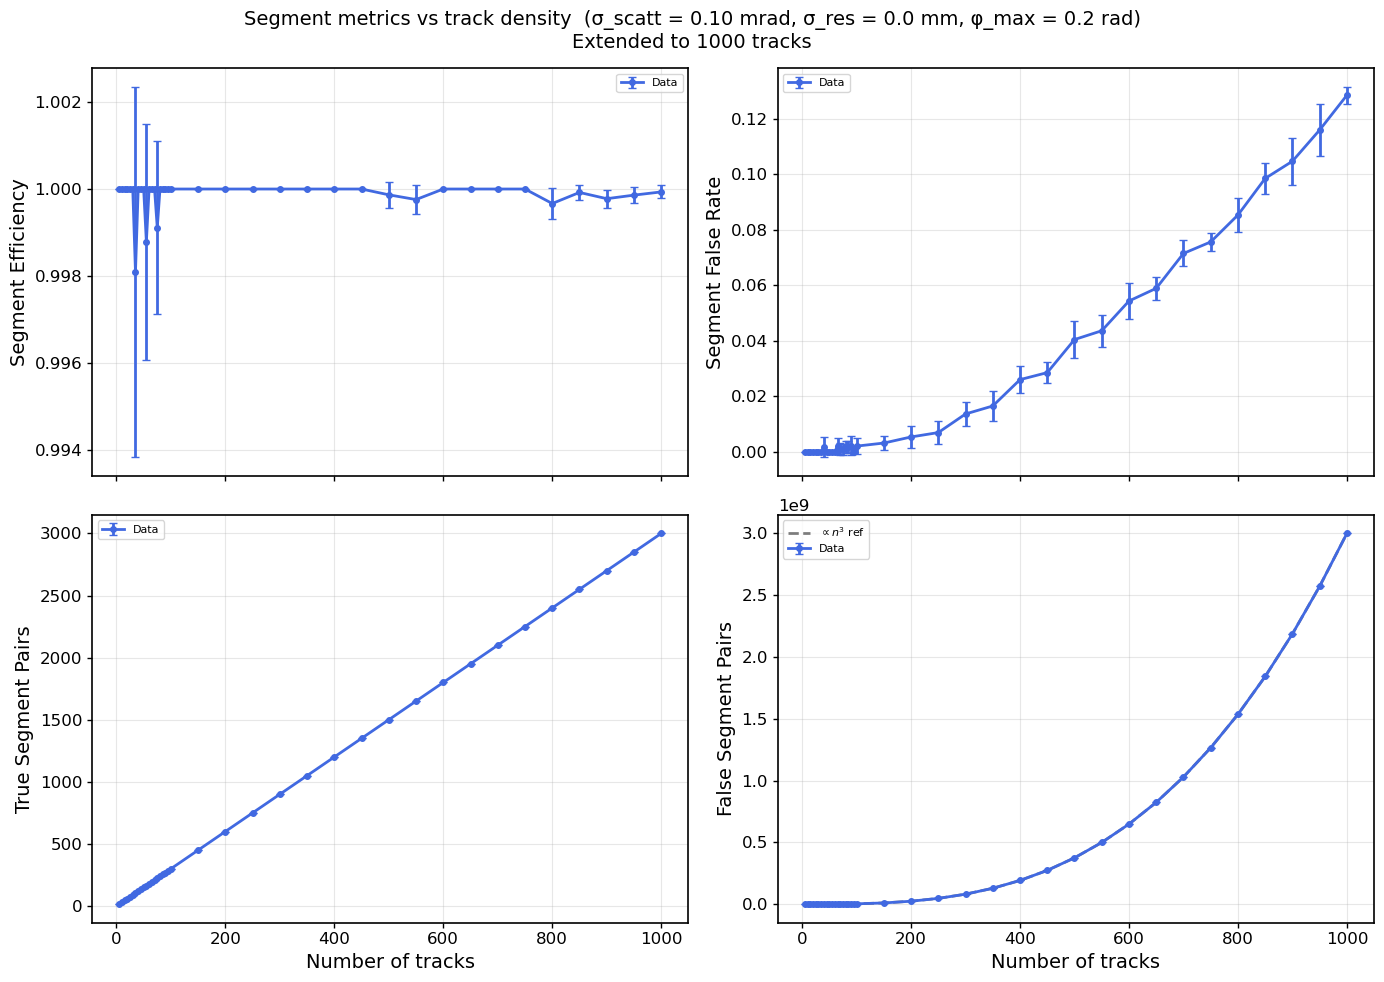

In [33]:
# ============================================================================
# 12d. Extended Density Scan Plots
# ============================================================================
grp_ext = df_density_ext.groupby("n_tracks")

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fig.suptitle(f"Segment metrics vs track density  (σ_scatt = {SIGMA_SCATT_DENS*1e3:.2f} mrad, "
             f"σ_res = {SIGMA_RES_DENS} mm, φ_max = {PHI_MAX_DENS} rad)"
             f"\nExtended to 1000 tracks", fontsize=14)

metrics = [("segment_efficiency", "Segment Efficiency"),
           ("segment_false_rate", "Segment False Rate"),
           ("n_true",            "True Segment Pairs"),
           ("n_false",           "False Segment Pairs")]

for ax, (col, label) in zip(axes.flat, metrics):
    mean = grp_ext[col].mean()
    std  = grp_ext[col].std()
    ax.errorbar(mean.index, mean.values, yerr=std.values,
                fmt="o-", color="royalblue", capsize=3, ms=4, label="Data")

    # Reference line for n_false: n^3 scaling (triplet combinatorics)
    if col == "n_false":
        n_arr = mean.index.values.astype(float)
        c = mean.values[-1] / n_arr[-1]**3 if n_arr[-1] > 0 else 1
        ax.plot(n_arr, c * n_arr**3, "k--", alpha=0.5, label=r"$\propto n^3$ ref")

    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Number of tracks")

fig.tight_layout()
fig.savefig(OUT_DIR / 'density_scan_ext.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'density_scan_ext.pdf', bbox_inches='tight')
plt.show()

### 12e. Extended Fixed-Epsilon (single-event generation)

> **Note**: This experiment uses `safe_generate` (single-event, pion, 80 mm modules,
> PV σ = (0, 0, 1)) and is therefore **not directly comparable** to §10, which uses
> multi-event MIP generation with 160 mm modules and PV σ = (1, 1, 1). It serves as
> a complementary check of the triplet method under simpler generation conditions.

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks |
| n_tracks | [20–180 step 20], **[200–1000 step 100]** |
| σ_scatt | 1 × 10⁻⁴ rad (0.1 mrad) |
| σ_res | 0.005 mm |
| φ_max = θ_max | 0.2 rad |
| ε mode | **Fixed = 2.0 mrad** |
| Module half-width | 40 mm (80 mm full module) |
| PV sigma | x = 0, y = 0, z = 1 mm |
| Particle | Pion (mass = 139.6, q = 1) |
| Events per point | 1 (single-event via `safe_generate`) |
| Repeats per point | 20 |

In [34]:
# ============================================================================
# 12e. Extended Fixed-Epsilon Data Collection
# ============================================================================
FIXED_TRACK_COUNTS_EXT = [20, 40, 60, 80, 100, 120, 140, 160, 180,
                          200, 300, 400, 500, 600, 700, 800, 900, 1000]
N_REPEATS_FIXED_EXT = 20

print("=" * 80)
print("SEGMENT-LEVEL EFFICIENCY (fixed eps = 2 mrad) — EXTENDED")
print("=" * 80)

_cache_file = CACHE_DIR / "segment_efficiency_results_ext.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        seg_eff_results_ext = pickle.load(f)
    print(f"Loaded seg_eff_results_ext from cache: {len(seg_eff_results_ext)} entries")
else:
    seg_eff_results_ext = []
    t_start = _time.time()

    for n_trk in FIXED_TRACK_COUNTS_EXT:
        t0 = _time.time()
        per_repeat_data = []

        for rep in range(N_REPEATS_FIXED_EXT):
            np.random.seed(rep + n_trk * 100 + 800000)
            event = safe_generate(n_trk, measurement_error=FIXED_RESOLUTION,
                                  collision_noise=FIXED_SCATTERING,
                                  phi_max=0.2, theta_max=0.2)
            m = fast_segment_metrics(event, FIXED_EPSILON)
            per_repeat_data.append(m)

        eff_per = np.array([r['segment_efficiency'] for r in per_repeat_data])
        fr_per  = np.array([r['segment_false_rate'] for r in per_repeat_data])
        nt_per  = np.array([r['n_true'] for r in per_repeat_data])
        nf_per  = np.array([r['n_false'] for r in per_repeat_data])
        ta_per  = np.array([r['true_accepted'] for r in per_repeat_data])
        fa_per  = np.array([r['false_accepted'] for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_results_ext.append({
            'total_tracks': n_trk,
            'n_repeats': nr,
            'seg_efficiency_mean': np.mean(eff_per),
            'seg_efficiency_se': np.std(eff_per, ddof=1) / np.sqrt(nr),
            'seg_false_rate_mean': np.mean(fr_per),
            'seg_false_rate_se': np.std(fr_per, ddof=1) / np.sqrt(nr),
            'n_true_mean': np.mean(nt_per),
            'n_true_se': np.std(nt_per, ddof=1) / np.sqrt(nr),
            'n_false_mean': np.mean(nf_per),
            'n_false_se': np.std(nf_per, ddof=1) / np.sqrt(nr),
            'true_acc_mean': np.mean(ta_per),
            'true_acc_se': np.std(ta_per, ddof=1) / np.sqrt(nr),
            'false_acc_mean': np.mean(fa_per),
            'false_acc_se': np.std(fa_per, ddof=1) / np.sqrt(nr),
            'per_repeat': per_repeat_data,
        })

        dt = _time.time() - t0
        print(f"  [{n_trk:4d} tracks]  eff={np.mean(eff_per)*100:.2f}%  "
              f"fr={np.mean(fr_per)*100:.2f}%  ({dt:.1f}s)")

    with open(_cache_file, "wb") as f:
        pickle.dump(seg_eff_results_ext, f)
    print(f"\nDone in {_time.time() - t_start:.0f}s")

SEGMENT-LEVEL EFFICIENCY (fixed eps = 2 mrad) — EXTENDED
Loaded seg_eff_results_ext from cache: 18 entries


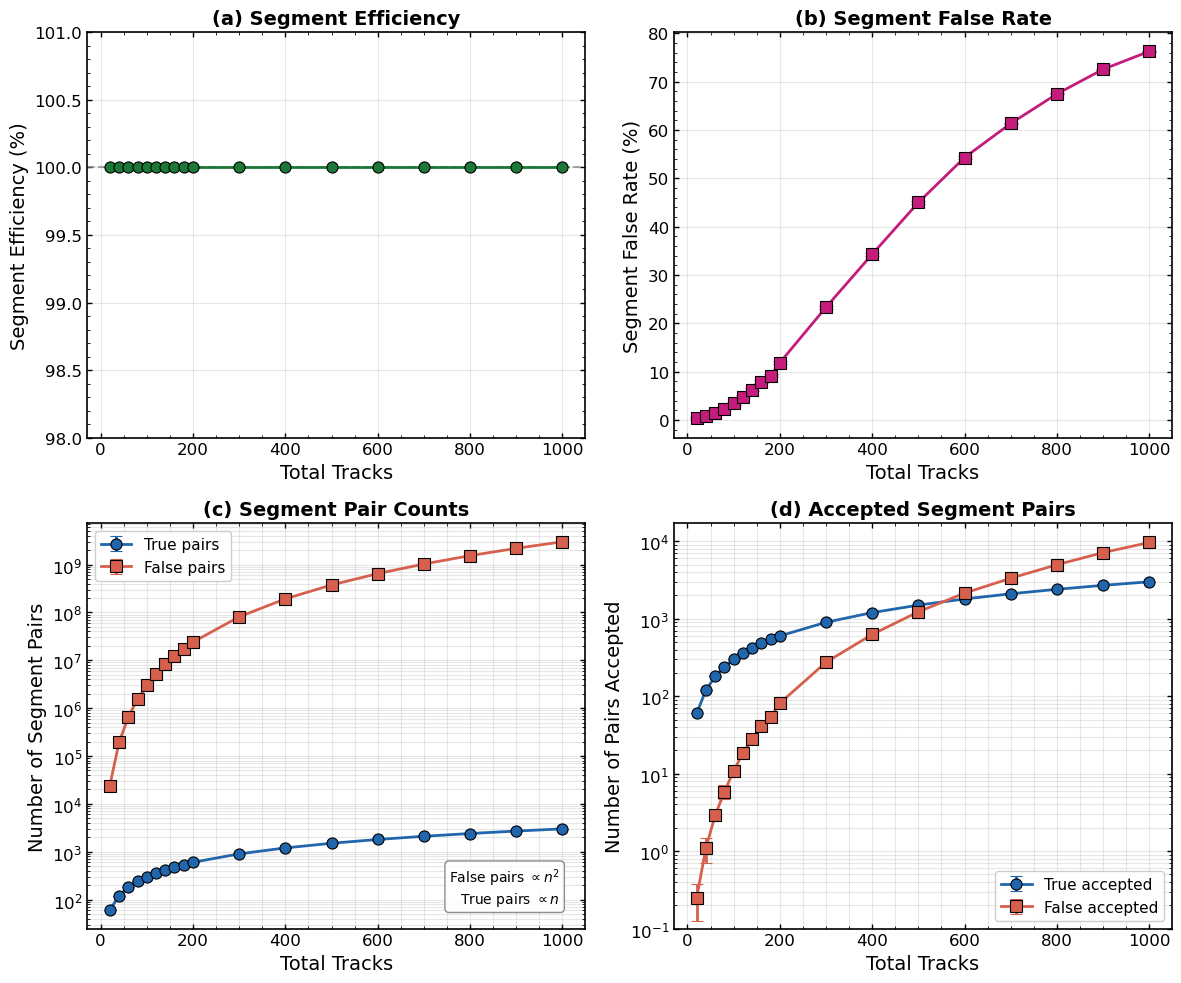


EXTENDED SEGMENT-LEVEL EFFICIENCY SUMMARY (per-repeat mean +/- SE)
Tracks     Reps   Seg Eff          False Rate       True Pairs         False Pairs        True Acc         False Acc       
----------------------------------------------------------------------------------------------------------------------------------
20         20     100.00% +/- 0.00% 0.41% +/- 0.20%  60 +/- 0.0         23940 +/- 0.0      60 +/- 0.0       0.2 +/- 0.1     
40         20     100.00% +/- 0.00% 0.89% +/- 0.32%  120 +/- 0.0        191880 +/- 0.0     120 +/- 0.0      1.1 +/- 0.4     
60         20     100.00% +/- 0.00% 1.58% +/- 0.22%  180 +/- 0.0        647820 +/- 0.0     180 +/- 0.0      2.9 +/- 0.4     
80         20     100.00% +/- 0.00% 2.34% +/- 0.45%  240 +/- 0.0        1535760 +/- 0.0    240 +/- 0.0      5.8 +/- 1.2     
100        20     100.00% +/- 0.00% 3.46% +/- 0.31%  300 +/- 0.0        2999700 +/- 0.0    300 +/- 0.0      10.8 +/- 1.0    
120        20     100.00% +/- 0.00% 4.88% +/- 0.23% 

In [35]:
# ============================================================================
# 12e. Extended Fixed-Epsilon Plots  (Paper-Ready)
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

if len(seg_eff_results_ext) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    color_true = '#2166ac'
    color_false = '#d6604d'
    color_eff = '#1b7837'
    color_false_rate = '#c51b7d'

    tc  = np.array([r['total_tracks'] for r in seg_eff_results_ext])
    se_ = np.array([r['seg_efficiency_mean'] * 100 for r in seg_eff_results_ext])
    see = np.array([r['seg_efficiency_se'] * 100 for r in seg_eff_results_ext])
    fr_ = np.array([r['seg_false_rate_mean'] * 100 for r in seg_eff_results_ext])
    fre = np.array([r['seg_false_rate_se'] * 100 for r in seg_eff_results_ext])
    ntm = np.array([r['n_true_mean'] for r in seg_eff_results_ext])
    nts = np.array([r['n_true_se'] for r in seg_eff_results_ext])
    nfm = np.array([r['n_false_mean'] for r in seg_eff_results_ext])
    nfs = np.array([r['n_false_se'] for r in seg_eff_results_ext])
    tam = np.array([r['true_acc_mean'] for r in seg_eff_results_ext])
    tas = np.array([r['true_acc_se'] for r in seg_eff_results_ext])
    fam = np.array([r['false_acc_mean'] for r in seg_eff_results_ext])
    fas = np.array([r['false_acc_se'] for r in seg_eff_results_ext])

    # (a) Segment Efficiency
    ax1 = axes[0, 0]
    ax1.errorbar(tc, se_, yerr=see, fmt='o-', color=color_eff, capsize=5,
                 capthick=1.5, markersize=8, markeredgecolor='black', markeredgewidth=0.8)
    ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.set_xlabel('Total Tracks')
    ax1.set_ylabel('Segment Efficiency (%)')
    ax1.set_title('(a) Segment Efficiency', fontweight='bold')
    ax1.set_ylim(min(se_) - 2, 101)
    ax1.grid(True, alpha=0.3)
    ax1.minorticks_on()
    ax1.tick_params(which='both', direction='in', top=True, right=True)

    # (b) False Rate
    ax2 = axes[0, 1]
    ax2.errorbar(tc, fr_, yerr=fre, fmt='s-', color=color_false_rate, capsize=5,
                 capthick=1.5, markersize=8, markeredgecolor='black', markeredgewidth=0.8)
    ax2.set_xlabel('Total Tracks')
    ax2.set_ylabel('Segment False Rate (%)')
    ax2.set_title('(b) Segment False Rate', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.minorticks_on()
    ax2.tick_params(which='both', direction='in', top=True, right=True)

    # (c) Pair counts
    ax3 = axes[1, 0]
    ax3.errorbar(tc, ntm, yerr=nts, fmt='o-', color=color_true, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='True pairs')
    ax3.errorbar(tc, nfm, yerr=nfs, fmt='s-', color=color_false, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='False pairs')
    ax3.set_yscale('log')
    ax3.set_xlabel('Total Tracks')
    ax3.set_ylabel('Number of Segment Pairs')
    ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
    ax3.legend(loc='upper left', framealpha=0.95)
    ax3.grid(True, alpha=0.3, which='both')
    ax3.minorticks_on()
    ax3.tick_params(which='both', direction='in', top=True, right=True)
    ax3.text(0.95, 0.05, r'False pairs $\propto n^2$' + '\n' + r'True pairs $\propto n$',
             transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # (d) Accepted pairs
    ax4 = axes[1, 1]
    fa_plot = np.where(fam > 0, fam, 0.5)
    fa_se_plot = np.where(fam > 0, fas, 0)
    ax4.errorbar(tc, tam, yerr=tas, fmt='o-', color=color_true, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='True accepted')
    ax4.errorbar(tc, fa_plot, yerr=fa_se_plot, fmt='s-', color=color_false, capsize=4,
                 capthick=1.2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label='False accepted')
    ax4.set_yscale('log')
    ax4.set_xlabel('Total Tracks')
    ax4.set_ylabel('Number of Pairs Accepted')
    ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
    ax4.legend(loc='lower right', framealpha=0.95)
    ax4.grid(True, alpha=0.3, which='both')
    ax4.minorticks_on()
    ax4.tick_params(which='both', direction='in', top=True, right=True)
    ax4.set_ylim(0.1, None)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency_ext.png', dpi=300,
                bbox_inches='tight', facecolor='white')
    fig.savefig(OUT_DIR / 'fixed_epsilon_segment_efficiency_ext.pdf',
                format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()

    # Summary table
    print("\n" + "=" * 130)
    print("EXTENDED SEGMENT-LEVEL EFFICIENCY SUMMARY (per-repeat mean +/- SE)")
    print("=" * 130)
    print(f"{'Tracks':<10} {'Reps':<6} {'Seg Eff':<16} {'False Rate':<16} "
          f"{'True Pairs':<18} {'False Pairs':<18} {'True Acc':<16} {'False Acc':<16}")
    print("-" * 130)
    for r in seg_eff_results_ext:
        eff_str = f"{r['seg_efficiency_mean']*100:.2f}% +/- {r['seg_efficiency_se']*100:.2f}%"
        fr_str = f"{r['seg_false_rate_mean']*100:.2f}% +/- {r['seg_false_rate_se']*100:.2f}%"
        true_p_str = f"{r['n_true_mean']:.0f} +/- {r['n_true_se']:.1f}"
        false_p_str = f"{r['n_false_mean']:.0f} +/- {r['n_false_se']:.1f}"
        true_a_str = f"{r['true_acc_mean']:.0f} +/- {r['true_acc_se']:.1f}"
        false_a_str = f"{r['false_acc_mean']:.1f} +/- {r['false_acc_se']:.1f}"
        print(f"{r['total_tracks']:<10} {r['n_repeats']:<6} {eff_str:<16} {fr_str:<16} "
              f"{true_p_str:<18} {false_p_str:<18} {true_a_str:<16} {false_a_str:<16}")

### 12f. Extended Zero-Noise Benchmark (extends §11)

| Parameter | Value |
|-----------|-------|
| Swept | n_tracks × regime |
| n_tracks | 5–100 (step 5), **150–1000 (step 50)** |
| σ_scatt | ≈ 0 (1 × 10⁻⁸ rad) |
| σ_res | 0.0 mm |
| Dense (φ_max) | 0.02 rad |
| Non-dense (φ_max) | 0.2 rad |
| ε mode | **Formula** (≈ √2·θ_min ≈ 0.064 mrad) |
| Repeats per point | 20 |

In [36]:
# ============================================================================
# 12f. Extended Zero-Noise Benchmark Data Collection
# ============================================================================
ZERO_TRACK_COUNTS_EXT = list(range(5, 105, 5)) + list(range(150, 1050, 50))
ZERO_N_REPEATS_EXT    = 20
ZERO_SIGMA_RES_EXT    = 0.0
ZERO_SIGMA_SCATT_EXT  = 1e-8

epsilon_zero_ext = compute_epsilon(ZERO_SIGMA_RES_EXT, ZERO_SIGMA_SCATT_EXT)
print(f"Zero-noise eps = {epsilon_zero_ext*1e3:.4f} mrad")
print(f"Track counts: {ZERO_TRACK_COUNTS_EXT[0]}-{ZERO_TRACK_COUNTS_EXT[-1]}, "
      f"{ZERO_N_REPEATS_EXT} repeats/point")

_cache_file = CACHE_DIR / "df_zero_noise_ext.csv"
if _cache_file.exists():
    df_zero_ext = pd.read_csv(_cache_file)
    print(f"Loaded df_zero_ext from cache: {len(df_zero_ext)} rows")
else:
    rows_ext = []
    t_start = _time.time()
    for label, phi_max in ZERO_CONE_SETTINGS.items():
        print(f"\n-- {label} (phi_max = {phi_max}) --")
        for n_trk in ZERO_TRACK_COUNTS_EXT:
            t0 = _time.time()
            for rep in range(ZERO_N_REPEATS_EXT):
                np.random.seed(rep + n_trk * 100 + hash(label) % 10**6 + 900000)
                event = safe_generate(n_trk, measurement_error=ZERO_SIGMA_RES_EXT,
                                      collision_noise=ZERO_SIGMA_SCATT_EXT,
                                      phi_max=phi_max, theta_max=phi_max)
                m = fast_segment_metrics(event, epsilon_zero_ext)
                rows_ext.append({
                    "regime": label,
                    "phi_max": phi_max,
                    "n_tracks": n_trk,
                    "repeat": rep,
                    "epsilon": epsilon_zero_ext,
                    **m,
                })
            dt = _time.time() - t0
            print(f"  n_tracks={n_trk:4d}  done  ({dt:.1f}s)")

    df_zero_ext = pd.DataFrame(rows_ext)
    df_zero_ext.to_csv(_cache_file, index=False)
    print(f"\n{len(df_zero_ext)} rows collected & saved  "
          f"(total {_time.time() - t_start:.0f}s)")

Zero-noise eps = 0.0212 mrad
Track counts: 5-1000, 20 repeats/point
Loaded df_zero_ext from cache: 1520 rows


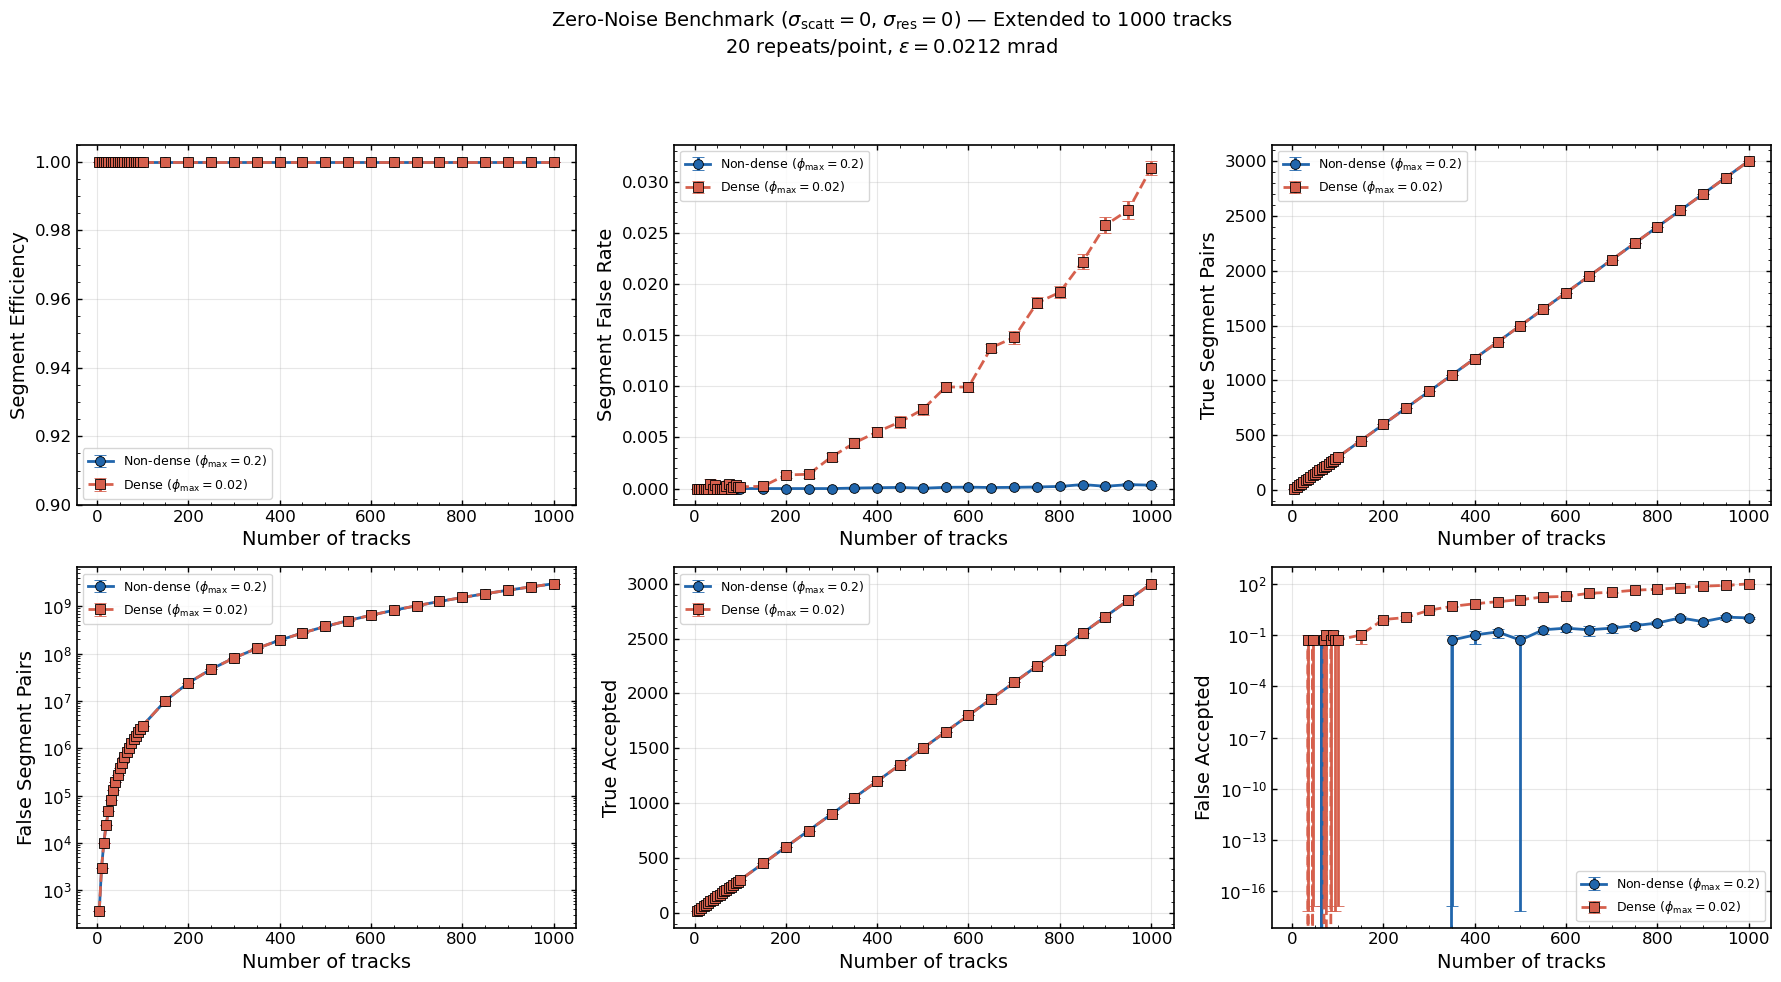

In [37]:
# ============================================================================
# 12f. Extended Zero-Noise Benchmark — 6-panel plot
# ============================================================================
regime_colors = {"non_dense": "#2166ac", "dense": "#d6604d"}
regime_labels_ext = {"non_dense": r"Non-dense ($\phi_{\max}=0.2$)",
                     "dense":     r"Dense ($\phi_{\max}=0.02$)"}
regime_fmts   = {"non_dense": "o-", "dense": "s--"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(r"Zero-Noise Benchmark ($\sigma_{\mathrm{scatt}} = 0$, $\sigma_{\mathrm{res}} = 0$)"
             f" — Extended to 1000 tracks\n{ZERO_N_REPEATS_EXT} repeats/point, "
             rf"$\varepsilon = {epsilon_zero_ext*1e3:.4f}$ mrad", fontsize=14)

metrics_6 = [
    ("segment_efficiency", "Segment Efficiency", True),
    ("segment_false_rate", "Segment False Rate", True),
    ("n_true",         "True Segment Pairs", False),
    ("n_false",        "False Segment Pairs", False),
    ("true_accepted",  "True Accepted",       False),
    ("false_accepted", "False Accepted",       False),
]

for ax, (col, ylabel, is_frac) in zip(axes.flat, metrics_6):
    for regime in ["non_dense", "dense"]:
        sub = df_zero_ext[df_zero_ext["regime"] == regime]
        grp = sub.groupby("n_tracks")[col]
        mean = grp.mean()
        se_  = grp.std(ddof=1) / np.sqrt(grp.count())
        ax.errorbar(mean.index, mean.values, yerr=se_.values,
                    fmt=regime_fmts[regime], color=regime_colors[regime],
                    capsize=4, capthick=1.2, linewidth=2, markersize=7,
                    markeredgecolor='black', markeredgewidth=0.6,
                    label=regime_labels_ext[regime])
    ax.set_xlabel("Number of tracks")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, loc="best")
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    if col == "segment_efficiency":
        ax.set_ylim(0.90, 1.005)
    if col in ("n_false", "false_accepted"):
        ax.set_yscale("log")

fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext.png', dpi=150, bbox_inches='tight')
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext.pdf', bbox_inches='tight')
plt.show()

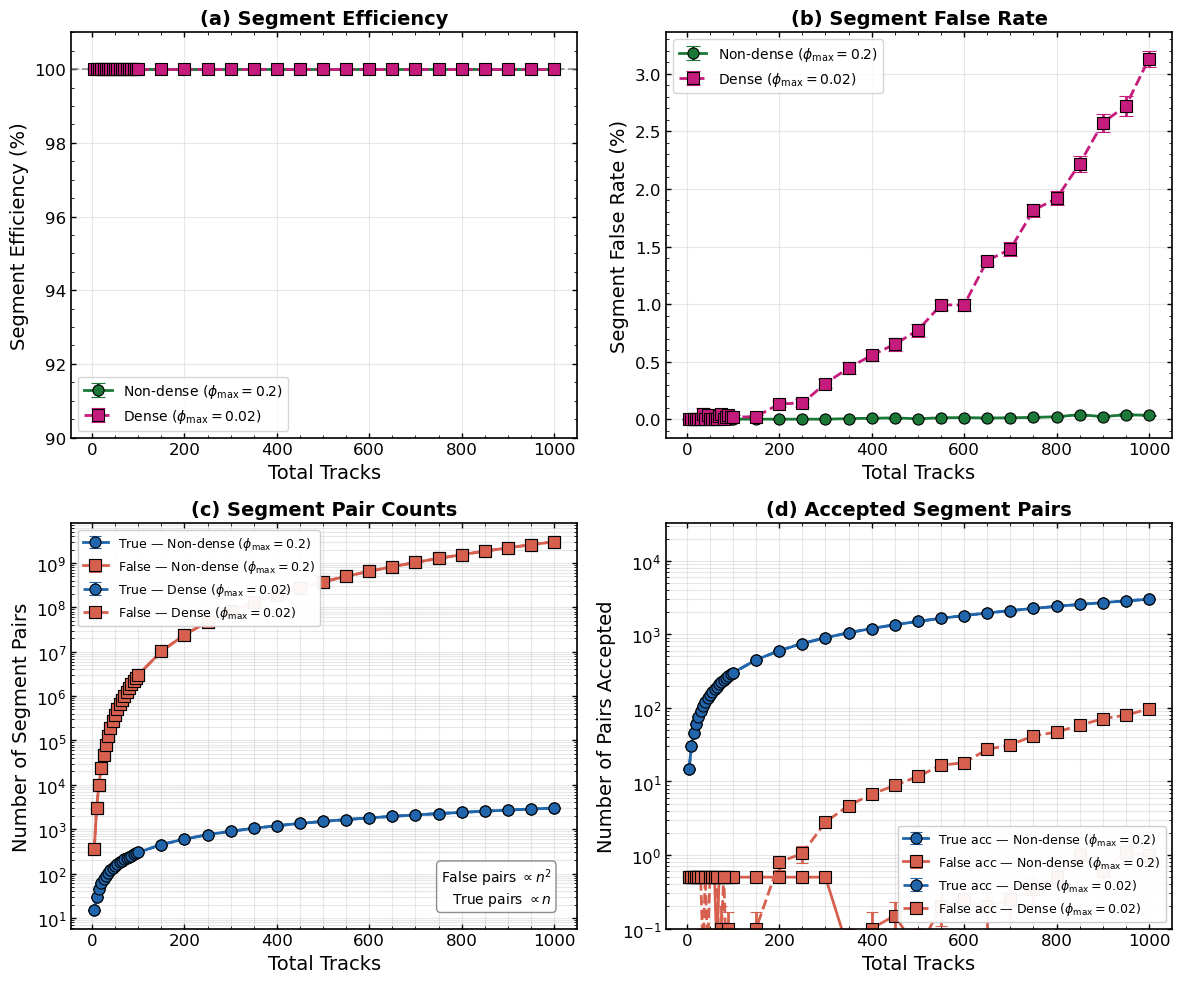

In [38]:
# ============================================================================
# 12f. Extended Zero-Noise Benchmark — Paper-Ready 2x2
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'lines.linewidth': 2, 'lines.markersize': 8,
})

zero_plot_ext = {}
for regime in ["non_dense", "dense"]:
    sub = df_zero_ext[df_zero_ext["regime"] == regime]
    agg = sub.groupby("n_tracks").agg(
        seg_eff_mean=("segment_efficiency", "mean"),
        seg_eff_se=("segment_efficiency", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_rate_mean=("segment_false_rate", "mean"),
        false_rate_se=("segment_false_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_true_mean=("n_true", "mean"),
        n_true_se=("n_true", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n_false_mean=("n_false", "mean"),
        n_false_se=("n_false", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        true_acc_mean=("true_accepted", "mean"),
        true_acc_se=("true_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        false_acc_mean=("false_accepted", "mean"),
        false_acc_se=("false_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    zero_plot_ext[regime] = agg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors_zn = {"non_dense": '#1b7837', "dense": '#c51b7d'}
fmts_zn   = {"non_dense": 'o-',     "dense": 's--'}
labels_zn = {"non_dense": r'Non-dense ($\phi_{\max}=0.2$)',
             "dense":     r'Dense ($\phi_{\max}=0.02$)'}

# (a) Segment Efficiency
ax1 = axes[0, 0]
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    ax1.errorbar(d.index, d["seg_eff_mean"] * 100, yerr=d["seg_eff_se"] * 100,
                 fmt=fmts_zn[regime], color=colors_zn[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels_zn[regime])
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_xlabel('Total Tracks')
ax1.set_ylabel('Segment Efficiency (%)')
ax1.set_title('(a) Segment Efficiency', fontweight='bold')
ax1.set_ylim(90, 101)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)

# (b) Segment False Rate
ax2 = axes[0, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    ax2.errorbar(d.index, d["false_rate_mean"] * 100, yerr=d["false_rate_se"] * 100,
                 fmt=fmts_zn[regime], color=colors_zn[regime], capsize=5, capthick=1.5,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8, label=labels_zn[regime])
ax2.set_xlabel('Total Tracks')
ax2.set_ylabel('Segment False Rate (%)')
ax2.set_title('(b) Segment False Rate', fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)

# (c) Segment Pair Counts
ax3 = axes[1, 0]
color_true_zn = '#2166ac'
color_false_zn = '#d6604d'
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    style = '-' if regime == "non_dense" else '--'
    ax3.errorbar(d.index, d["n_true_mean"], yerr=d["n_true_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True — {labels_zn[regime]}')
    ax3.errorbar(d.index, d["n_false_mean"], yerr=d["n_false_se"],
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False — {labels_zn[regime]}')
ax3.set_yscale('log')
ax3.set_xlabel('Total Tracks')
ax3.set_ylabel('Number of Segment Pairs')
ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)
ax3.text(0.95, 0.05, r'False pairs $\propto n^2$' + '\n' + r'True pairs $\propto n$',
         transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# (d) Accepted Segment Pairs
ax4 = axes[1, 1]
for regime in ["non_dense", "dense"]:
    d = zero_plot_ext[regime]
    style = '-' if regime == "non_dense" else '--'
    ax4.errorbar(d.index, d["true_acc_mean"], yerr=d["true_acc_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'True acc — {labels_zn[regime]}')
    fa_p = np.where(d["false_acc_mean"] > 0, d["false_acc_mean"], 0.5)
    fa_s = np.where(d["false_acc_mean"] > 0, d["false_acc_se"], 0)
    ax4.errorbar(d.index, fa_p, yerr=fa_s,
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 linewidth=2, markersize=8, markeredgecolor='black',
                 markeredgewidth=0.8,
                 label=f'False acc — {labels_zn[regime]}')
ax4.set_yscale('log')
ax4.set_xlabel('Total Tracks')
ax4.set_ylabel('Number of Pairs Accepted')
ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_ylim(0.1, None)

plt.tight_layout()
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext_paper.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(OUT_DIR / 'zero_noise_benchmark_ext_paper.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

In [39]:
# ============================================================================
# 12g. Extended Summary Tables & CSV Export
# ============================================================================
agg_cols = ["segment_efficiency", "segment_false_rate", "n_true", "n_false"]

print("=" * 80)
print("EXTENDED SCATTERING SWEEP SUMMARY")
print("=" * 80)
summary_scatt_ext = (df_seg_scatt_ext
    .groupby(["phi_max", "n_tracks", "sigma_scatt_mrad"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_scatt_ext.round(4))

print("\n" + "=" * 80)
print("EXTENDED RESOLUTION SWEEP SUMMARY")
print("=" * 80)
summary_res_ext = (df_seg_res_ext
    .groupby(["phi_max", "n_tracks", "sigma_res_mm"])[agg_cols]
    .agg(["mean", "std"])
)
display(summary_res_ext.round(4))

print("\n" + "=" * 80)
print("EXTENDED DENSITY SCAN SUMMARY")
print("=" * 80)
summary_dens_ext = (df_density_ext
    .groupby("n_tracks")[agg_cols]
    .agg(["mean", "std"])
)
display(summary_dens_ext.round(4))

# Save CSVs
df_seg_scatt_ext.to_csv(OUT_DIR / "segment_scattering_sweep_ext.csv", index=False)
df_seg_res_ext.to_csv(OUT_DIR / "segment_resolution_sweep_ext.csv", index=False)
df_density_ext.to_csv(OUT_DIR / "segment_density_scan_ext.csv", index=False)
df_zero_ext.to_csv(OUT_DIR / "segment_zero_noise_ext.csv", index=False)

print(f"\nSaved extended CSVs to {OUT_DIR}/")
for f in sorted(OUT_DIR.glob("*_ext*.csv")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

EXTENDED SCATTERING SWEEP SUMMARY


segment_efficiency          \
                                                mean     std   
phi_max n_tracks sigma_scatt_mrad                              
0.02    10       0.05                         1.0000  0.0000   
                 0.10                         1.0000  0.0000   
                 0.20                         1.0000  0.0000   
                 0.40                         1.0000  0.0000   
                 0.60                         1.0000  0.0000   
...                                              ...     ...   
0.20    1000     0.20                         0.9998  0.0002   
                 0.40                         0.9999  0.0003   
                 0.60                         0.9999  0.0001   
                 0.80                         0.9999  0.0002   
                 1.00                         0.9999  0.0001   

                                  segment_false_rate          n_true       \
                                                mean     std    mean  std   
phi_max n_tracks sigma_scatt_mrad                                           
0.02    10       0.05                         0.0000  0.0000    30.0  0.0   
                 0.10                         0.0000  0.0000    30.0  0.0   
                 0.20                         0.0277  0.0383    30.0  0.0   
                 0.40                         0.0365  0.0448    30.0  0.0   
                 0.60                         0.0860  0.0712    30.0  0.0   
...                                              ...     ...     ...  ...   
0.20    1000     0.20                         0.3690  0.0096  3000.0  0.0   
                 0.40                         0.7051  0.0074  3000.0  0.0   
                 0.60                         0.8385  0.0038  3000.0  0.0   
                 0.80                         0.9020  0.0030  3000.0  0.0   
                 1.00                         0.9355  0.0024  3000.0  0.0   

                                        n_false       
                                           mean  std  
phi_max n_tracks sigma_scatt_mrad                     
0.02    10       0.05              2.970000e+03  0.0  
                 0.10              2.970000e+03  0.0  
                 0.20              2.970000e+03  0.0  
                 0.40              2.970000e+03  0.0  
                 0.60              2.970000e+03  0.0  
...                                         ...  ...  
0.20    1000     0.20              2.999997e+09  0.0  
                 0.40              2.999997e+09  0.0  
                 0.60              2.999997e+09  0.0  
                 0.80              2.999997e+09  0.0  
                 1.00              2.999997e+09  0.0  

[98 rows x 8 columns]


EXTENDED RESOLUTION SWEEP SUMMARY


segment_efficiency         segment_false_rate  \
                                            mean     std               mean   
phi_max n_tracks sigma_res_mm                                                 
0.02    10       0.000                    1.0000  0.0000             0.0062   
                 0.005                    1.0000  0.0000             0.0097   
                 0.010                    1.0000  0.0000             0.1009   
                 0.015                    1.0000  0.0000             0.1705   
                 0.020                    1.0000  0.0000             0.3367   
...                                          ...     ...                ...   
0.20    1000     0.010                    0.9999  0.0002             0.8909   
                 0.015                    0.9998  0.0002             0.9481   
                 0.020                    1.0000  0.0001             0.9701   
                 0.030                    0.9999  0.0002             0.9866   
                 0.050                    1.0000  0.0001             0.9950   

                                       n_true            n_false       
                                  std    mean  std          mean  std  
phi_max n_tracks sigma_res_mm                                          
0.02    10       0.000         0.0198    30.0  0.0  2.970000e+03  0.0  
                 0.005         0.0156    30.0  0.0  2.970000e+03  0.0  
                 0.010         0.0586    30.0  0.0  2.970000e+03  0.0  
                 0.015         0.0968    30.0  0.0  2.970000e+03  0.0  
                 0.020         0.1250    30.0  0.0  2.970000e+03  0.0  
...                               ...     ...  ...           ...  ...  
0.20    1000     0.010         0.0030  3000.0  0.0  2.999997e+09  0.0  
                 0.015         0.0011  3000.0  0.0  2.999997e+09  0.0  
                 0.020         0.0007  3000.0  0.0  2.999997e+09  0.0  
                 0.030         0.0003  3000.0  0.0  2.999997e+09  0.0  
                 0.050         0.0001  3000.0  0.0  2.999997e+09  0.0  

[98 rows x 8 columns]


EXTENDED DENSITY SCAN SUMMARY


segment_efficiency         segment_false_rate          n_true       \
                       mean     std               mean     std    mean  std   
n_tracks                                                                      
5                    1.0000  0.0000             0.0000  0.0000    15.0  0.0   
10                   1.0000  0.0000             0.0000  0.0000    30.0  0.0   
15                   1.0000  0.0000             0.0000  0.0000    45.0  0.0   
20                   1.0000  0.0000             0.0000  0.0000    60.0  0.0   
25                   1.0000  0.0000             0.0000  0.0000    75.0  0.0   
30                   1.0000  0.0000             0.0000  0.0000    90.0  0.0   
35                   0.9981  0.0043             0.0000  0.0000   105.0  0.0   
40                   1.0000  0.0000             0.0017  0.0037   120.0  0.0   
45                   1.0000  0.0000             0.0000  0.0000   135.0  0.0   
50                   1.0000  0.0000             0.0000  0.0000   150.0  0.0   
55                   0.9988  0.0027             0.0000  0.0000   165.0  0.0   
60                   1.0000  0.0000             0.0000  0.0000   180.0  0.0   
65                   1.0000  0.0000             0.0020  0.0028   195.0  0.0   
70                   1.0000  0.0000             0.0009  0.0021   210.0  0.0   
75                   0.9991  0.0020             0.0009  0.0020   225.0  0.0   
80                   1.0000  0.0000             0.0017  0.0023   240.0  0.0   
85                   1.0000  0.0000             0.0016  0.0021   255.0  0.0   
90                   1.0000  0.0000             0.0022  0.0033   270.0  0.0   
95                   1.0000  0.0000             0.0000  0.0000   285.0  0.0   
100                  1.0000  0.0000             0.0020  0.0030   300.0  0.0   
150                  1.0000  0.0000             0.0031  0.0025   450.0  0.0   
200                  1.0000  0.0000             0.0053  0.0039   600.0  0.0   
250                  1.0000  0.0000             0.0069  0.0040   750.0  0.0   
300                  1.0000  0.0000             0.0136  0.0044   900.0  0.0   
350                  1.0000  0.0000             0.0165  0.0055  1050.0  0.0   
400                  1.0000  0.0000             0.0260  0.0049  1200.0  0.0   
450                  1.0000  0.0000             0.0285  0.0037  1350.0  0.0   
500                  0.9999  0.0003             0.0404  0.0067  1500.0  0.0   
550                  0.9998  0.0003             0.0436  0.0057  1650.0  0.0   
600                  1.0000  0.0000             0.0543  0.0064  1800.0  0.0   
650                  1.0000  0.0000             0.0589  0.0041  1950.0  0.0   
700                  1.0000  0.0000             0.0714  0.0047  2100.0  0.0   
750                  1.0000  0.0000             0.0756  0.0032  2250.0  0.0   
800                  0.9997  0.0003             0.0853  0.0060  2400.0  0.0   
850                  0.9999  0.0002             0.0985  0.0057  2550.0  0.0   
900                  0.9998  0.0002             0.1047  0.0085  2700.0  0.0   
950                  0.9999  0.0002             0.1159  0.0094  2850.0  0.0   
1000                 0.9999  0.0001             0.1285  0.0031  3000.0  0.0   

               n_false       
                  mean  std  
n_tracks                     
5         3.600000e+02  0.0  
10        2.970000e+03  0.0  
15        1.008000e+04  0.0  
20        2.394000e+04  0.0  
25        4.680000e+04  0.0  
30        8.091000e+04  0.0  
35        1.285200e+05  0.0  
40        1.918800e+05  0.0  
45        2.732400e+05  0.0  
50        3.748500e+05  0.0  
55        4.989600e+05  0.0  
60        6.478200e+05  0.0  
65        8.236800e+05  0.0  
70        1.028790e+06  0.0  
75        1.265400e+06  0.0  
80        1.535760e+06  0.0  
85        1.842120e+06  0.0  
90        2.186730e+06  0.0  
95        2.571840e+06  0.0  
100       2.999700e+06  0.0  
150       1.012455e+07  0.0  
200       2.399940e+07  0.0  
250       4.687425e


Saved extended CSVs to outputs/segment_analysis/
  segment_density_scan_ext.csv  (11.4 KB)
  segment_resolution_sweep_ext.csv  (77.9 KB)
  segment_scattering_sweep_ext.csv  (76.5 KB)
  segment_zero_noise_ext.csv  (106.4 KB)


---

## 13. Paper-Ready Figures (Up to 1000 Tracks)

Standalone section collecting the key results from the extended analysis (§12) into
publication-quality figures. All plots use the same underlying data generated
with the **shared-middle-hit segment matcher** (`fast_segment_metrics`), which
reproduces the original paper's segment-pairing logic:

- Segments are formed between consecutive detector modules
- Segment *pairs* are formed only when two segments share a common middle hit
- The angle between direction vectors of a pair is compared to ε

This is the same method used in the original OBQF paper. The Numba-accelerated
implementation (`fast_segment_metrics`) is a validated drop-in replacement.

| Figure | Sweep variable | Track range | Repeats/point |
|--------|---------------|-------------|---------------|
| 13a | σ_scatt | 10 – 1000 | 10 |
| 13b | σ_res | 10 – 1000 | 10 |
| 13c | n_tracks (density) | 5 – 1000 | 5 |
| 13d | n_tracks (fixed ε) | 20 – 1000 | 20 |
| 13e | n_tracks (zero noise) | 5 – 1000 | 20 |

In [57]:
# ============================================================================
# 13. Paper-Ready Plot Settings
# ============================================================================
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 10,
    'figure.titlesize': 16, 'axes.linewidth': 1.2,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'xtick.minor.width': 0.6, 'ytick.minor.width': 0.6,
    'lines.linewidth': 2, 'lines.markersize': 7,
})

# Shared palette for track counts
_tc_colors = {
    10: "#1b7837", 20: "#2166ac", 50: "#e08214", 100: "#c51b7d",
    200: "#7570b3", 500: "#d95f02", 1000: "#e7298a",
}
_tc_fmts = {
    10: "o-", 20: "s-", 50: "D-", 100: "^-",
    200: "v-", 500: "P-", 1000: "X-",
}

PAPER_DIR = OUT_DIR / "paper"
PAPER_DIR.mkdir(exist_ok=True)
print(f"Paper figures → {PAPER_DIR}/")
print(f"Segment matcher: fast_segment_metrics (shared-middle-hit, Numba-accelerated)")

Paper figures → outputs/segment_analysis/paper/
Segment matcher: fast_segment_metrics (shared-middle-hit, Numba-accelerated)


In [ ]:
# ============================================================================
# 13a. Segment Metrics vs Multiple Scattering (up to 1000 tracks)
# ============================================================================
_cache_file = CACHE_DIR / "df_seg_scatt_ext.csv"
if _cache_file.exists():
    df_seg_scatt_ext = pd.read_csv(_cache_file)
    print(f"Loaded scattering cache: {len(df_seg_scatt_ext)} rows")
else:
    import time as _time
    rows = []
    _t0 = _time.time()
    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS_EXT:
            for si_ext, sigma_s in enumerate(SIGMA_SCATT_VALUES):
                epsilon = compute_epsilon(0.0, sigma_s)
                for rep in range(N_EVENTS_STATS_EXT):
                    np.random.seed(rep + n_trk * 100 + si_ext * 10000 + 500000)
                    event = safe_generate(n_trk, measurement_error=0.0,
                                          collision_noise=sigma_s,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    rows.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_scatt": sigma_s,
                        "sigma_scatt_mrad": sigma_s * 1e3,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })
            print(f"  scatt sweep: phi={phi_max}, n_trk={n_trk} done "
                  f"({_time.time()-_t0:.0f}s)")
    df_seg_scatt_ext = pd.DataFrame(rows)
    df_seg_scatt_ext.to_csv(_cache_file, index=False)
    print(f"Saved scattering cache: {len(df_seg_scatt_ext)} rows "
          f"({_time.time()-_t0:.0f}s)")

# ── Plot ──
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_scatt_ext[df_seg_scatt_ext["phi_max"] == phi_max]
    regime = "non-dense" if phi_max >= 0.1 else "dense"

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",            "True Segment Pairs"),
               ("n_false",           "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS_EXT:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_scatt_mrad")[col]
            mean, sem = d.mean(), d.std(ddof=1) / np.sqrt(d.count())
            ax.errorbar(mean.index, mean.values, yerr=sem.values,
                        fmt=_tc_fmts[n_trk], color=_tc_colors[n_trk],
                        label=f"{n_trk} tracks", capsize=3,
                        markeredgecolor='black', markeredgewidth=0.5)
        ax.set_ylabel(label)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
        ax.minorticks_on()
        ax.tick_params(which='both', direction='in', top=True, right=True)
        if col in ("n_true", "n_false"):
            ax.set_yscale("log")

    for ax in axes[1]:
        ax.set_xlabel(r"$\sigma_{\mathrm{scatt}}$ (mrad)")

    regime_str = rf"$\phi_{{\max}} = {phi_max}$ rad ({regime})"
    fig.suptitle(rf"Segment Metrics vs Multiple Scattering — {regime_str}",
                 fontsize=14, fontweight='bold', y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    tag = f"phi{phi_max}".replace(".", "p")
    fig.savefig(PAPER_DIR / f'fig13a_scattering_sweep_{tag}.pdf',
                format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(PAPER_DIR / f'fig13a_scattering_sweep_{tag}.png',
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved fig13a scattering sweep ({regime})")

Loaded scattering cache: 980 rows


Loaded resolution cache: 980 rows


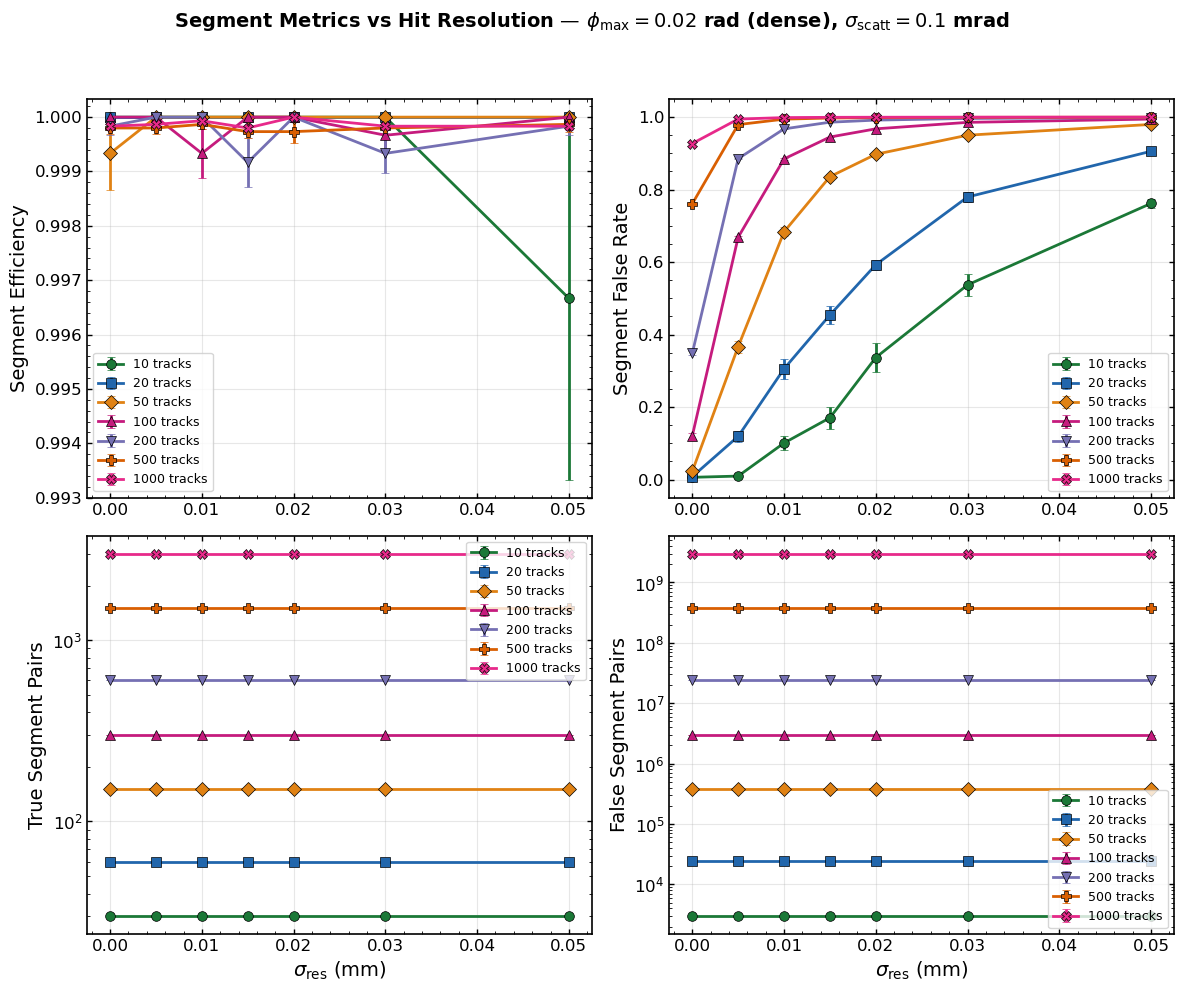

Saved fig13b resolution sweep (dense)


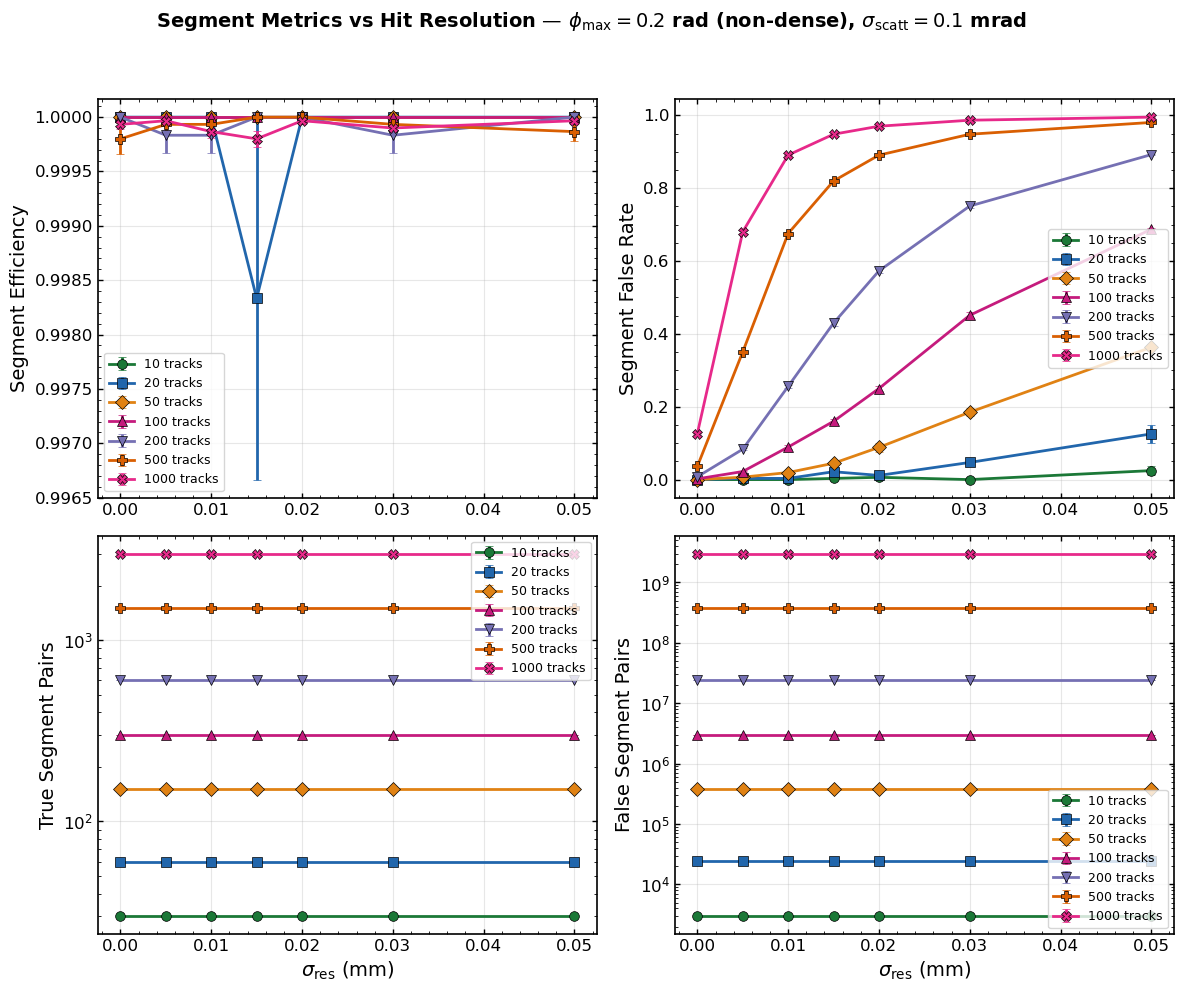

Saved fig13b resolution sweep (non-dense)


In [ ]:
# ============================================================================
# 13b. Segment Metrics vs Hit Resolution (up to 1000 tracks)
# ============================================================================
_cache_file = CACHE_DIR / "df_seg_res_ext.csv"
if _cache_file.exists():
    df_seg_res_ext = pd.read_csv(_cache_file)
    print(f"Loaded resolution cache: {len(df_seg_res_ext)} rows")
else:
    import time as _time
    rows = []
    _t0 = _time.time()
    for phi_max in ANGLE_SETTINGS:
        for n_trk in TRACK_COUNTS_EXT:
            for ri_ext, sigma_r in enumerate(SIGMA_RES_VALUES):
                epsilon = compute_epsilon(sigma_r, SIGMA_SCATT_FIXED)
                for rep in range(N_EVENTS_STATS_EXT):
                    np.random.seed(rep + n_trk * 100 + ri_ext * 10000 + 600000)
                    event = safe_generate(n_trk, measurement_error=sigma_r,
                                          collision_noise=SIGMA_SCATT_FIXED,
                                          phi_max=phi_max, theta_max=phi_max)
                    m = fast_segment_metrics(event, epsilon)
                    rows.append({
                        "phi_max": phi_max,
                        "n_tracks": n_trk,
                        "sigma_res_mm": sigma_r,
                        "sigma_scatt": SIGMA_SCATT_FIXED,
                        "epsilon": epsilon,
                        "repeat": rep,
                        **m,
                    })
            print(f"  res sweep: phi={phi_max}, n_trk={n_trk} done "
                  f"({_time.time()-_t0:.0f}s)")
    df_seg_res_ext = pd.DataFrame(rows)
    df_seg_res_ext.to_csv(_cache_file, index=False)
    print(f"Saved resolution cache: {len(df_seg_res_ext)} rows "
          f"({_time.time()-_t0:.0f}s)")

# ── Plot ──
for phi_max in ANGLE_SETTINGS:
    sub = df_seg_res_ext[df_seg_res_ext["phi_max"] == phi_max]
    regime = "non-dense" if phi_max >= 0.1 else "dense"

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    metrics = [("segment_efficiency", "Segment Efficiency"),
               ("segment_false_rate", "Segment False Rate"),
               ("n_true",            "True Segment Pairs"),
               ("n_false",           "False Segment Pairs")]

    for ax, (col, label) in zip(axes.flat, metrics):
        for n_trk in TRACK_COUNTS_EXT:
            d = sub[sub["n_tracks"] == n_trk].groupby("sigma_res_mm")[col]
            mean, sem = d.mean(), d.std(ddof=1) / np.sqrt(d.count())
            ax.errorbar(mean.index, mean.values, yerr=sem.values,
                        fmt=_tc_fmts[n_trk], color=_tc_colors[n_trk],
                        label=f"{n_trk} tracks", capsize=3,
                        markeredgecolor='black', markeredgewidth=0.5)
        ax.set_ylabel(label)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
        ax.minorticks_on()
        ax.tick_params(which='both', direction='in', top=True, right=True)
        if col in ("n_true", "n_false"):
            ax.set_yscale("log")

    for ax in axes[1]:
        ax.set_xlabel(r"$\sigma_{\mathrm{res}}$ (mm)")

    regime_str = rf"$\phi_{{\max}} = {phi_max}$ rad ({regime})"
    fig.suptitle(rf"Segment Metrics vs Hit Resolution — {regime_str}"
                 rf", $\sigma_{{\mathrm{{scatt}}}} = {SIGMA_SCATT_FIXED*1e3:.1f}$ mrad",
                 fontsize=14, fontweight='bold', y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    tag = f"phi{phi_max}".replace(".", "p")
    fig.savefig(PAPER_DIR / f'fig13b_resolution_sweep_{tag}.pdf',
                format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
    fig.savefig(PAPER_DIR / f'fig13b_resolution_sweep_{tag}.png',
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved fig13b resolution sweep ({regime})")

Loaded density cache: 190 rows


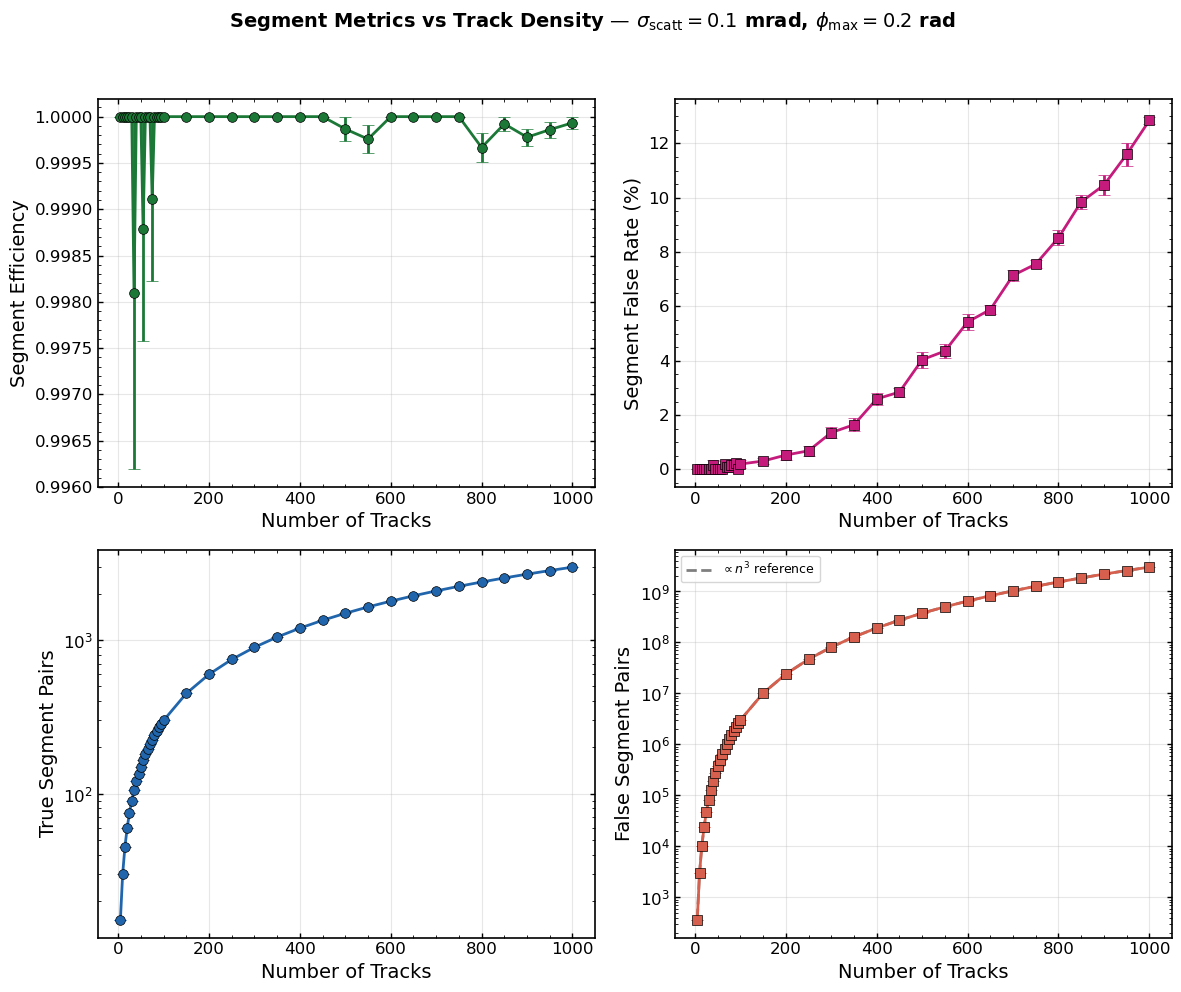

Saved fig13c density scan


In [ ]:
# ============================================================================
# 13c. Segment Metrics vs Track Density (up to 1000 tracks)
# ============================================================================
_cache_file = CACHE_DIR / "df_density_ext.csv"
if _cache_file.exists():
    df_density_ext = pd.read_csv(_cache_file)
    print(f"Loaded density cache: {len(df_density_ext)} rows")
else:
    import time as _time
    rows = []
    _t0 = _time.time()
    epsilon_dens_ext = compute_epsilon(SIGMA_RES_DENS, SIGMA_SCATT_DENS)
    for n_trk in DENSITY_TRACKS_EXT:
        for rep in range(N_EVENTS_DENSITY_EXT):
            np.random.seed(rep + n_trk * 100 + 700000)
            event = safe_generate(n_trk, measurement_error=SIGMA_RES_DENS,
                                  collision_noise=SIGMA_SCATT_DENS,
                                  phi_max=PHI_MAX_DENS, theta_max=PHI_MAX_DENS)
            m = fast_segment_metrics(event, epsilon_dens_ext)
            rows.append({
                "n_tracks": n_trk,
                "repeat": rep,
                "epsilon": epsilon_dens_ext,
                **m,
            })
        if n_trk % 100 == 0:
            print(f"  density: n_trk={n_trk} ({_time.time()-_t0:.0f}s)")
    df_density_ext = pd.DataFrame(rows)
    df_density_ext.to_csv(_cache_file, index=False)
    print(f"Saved density cache: {len(df_density_ext)} rows ({_time.time()-_t0:.0f}s)")

grp = df_density_ext.groupby("n_tracks")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

color_eff = "#1b7837"
color_fr = "#c51b7d"
color_true = "#2166ac"
color_false = "#d6604d"

panels = [
    ("segment_efficiency", "Segment Efficiency", color_eff, "o-"),
    ("segment_false_rate", "Segment False Rate (%)", color_fr, "s-"),
    ("n_true", "True Segment Pairs", color_true, "o-"),
    ("n_false", "False Segment Pairs", color_false, "s-"),
]

for ax, (col, ylabel, clr, fmt) in zip(axes.flat, panels):
    mean = grp[col].mean()
    sem = grp[col].std(ddof=1) / np.sqrt(grp[col].count())
    vals = mean.values * 100 if "rate" in col.lower() else mean.values
    errs = sem.values * 100 if "rate" in col.lower() else sem.values

    ax.errorbar(mean.index, vals, yerr=errs,
                fmt=fmt, color=clr, capsize=4, capthick=1.2,
                markeredgecolor='black', markeredgewidth=0.5)

    if col == "n_false":
        n_arr = mean.index.values.astype(float)
        c = mean.values[-1] / n_arr[-1]**3 if n_arr[-1] > 0 else 1
        ax.plot(n_arr, c * n_arr**3, 'k--', alpha=0.5, label=r"$\propto n^3$ reference")
        ax.legend(fontsize=9)

    ax.set_xlabel("Number of Tracks")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    if col in ("n_true", "n_false"):
        ax.set_yscale("log")

fig.suptitle(rf"Segment Metrics vs Track Density — "
             rf"$\sigma_{{\mathrm{{scatt}}}} = {SIGMA_SCATT_DENS*1e3:.1f}$ mrad, "
             rf"$\phi_{{\max}} = {PHI_MAX_DENS}$ rad",
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(PAPER_DIR / 'fig13c_density_scan.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13c_density_scan.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig13c density scan")

Pairwise JIT compiled: 60 true, 720 false
  n_true              :     60  OK
  n_false             :    720  OK
  true_accepted       :     60  OK
  false_accepted      :      0  OK
  fixed-eps: n_trk=  20  eff=100.00%  fr=0.59%  n_false=3040  (0s)
  fixed-eps: n_trk=  40  eff=100.00%  fr=0.55%  n_false=12480  (0s)
  fixed-eps: n_trk=  60  eff=100.00%  fr=0.90%  n_false=28320  (0s)
  fixed-eps: n_trk=  80  eff=100.00%  fr=1.23%  n_false=50560  (1s)
  fixed-eps: n_trk= 100  eff=100.00%  fr=1.46%  n_false=79200  (1s)
  fixed-eps: n_trk= 120  eff=100.00%  fr=1.61%  n_false=114240  (1s)
  fixed-eps: n_trk= 140  eff=100.00%  fr=0.83%  n_false=155680  (1s)
  fixed-eps: n_trk= 160  eff=100.00%  fr=1.77%  n_false=203520  (2s)
  fixed-eps: n_trk= 180  eff=100.00%  fr=1.88%  n_false=257760  (2s)
  fixed-eps: n_trk= 200  eff=100.00%  fr=2.06%  n_false=318400  (3s)
  fixed-eps: n_trk= 300  eff=100.00%  fr=2.95%  n_false=717600  (4s)
  fixed-eps: n_trk= 400  eff=100.00%  fr=4.35%  n_false=1276800  

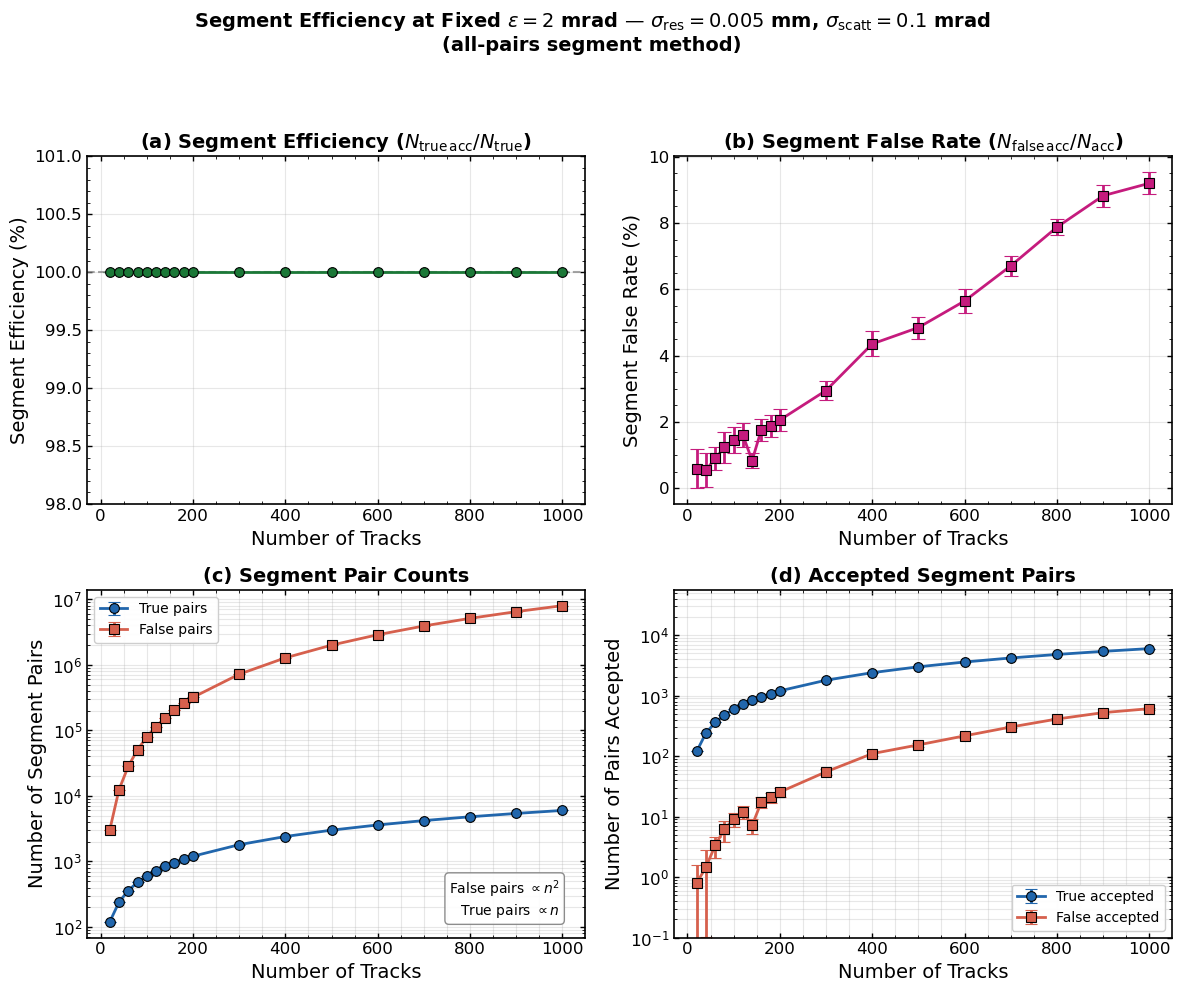

Saved fig13d fixed-epsilon efficiency


In [ ]:
# ============================================================================
# 13d. Segment Efficiency at Fixed ε (up to 1000 tracks)
#      ALL-PAIRS segment direction comparison (matches original paper method)
# ============================================================================
import math
from numba import njit, prange

# ── Numba kernel: all pairs (i<j) of segment direction vectors ──
@njit(parallel=True)
def _pairwise_seg_counts(vx, vy, vz, norms, tids, cos_eps):
    """Count true/false/accepted for every (i<j) pair of segments."""
    n = len(vx)
    nt_arr = np.zeros(n, dtype=np.int64)
    nf_arr = np.zeros(n, dtype=np.int64)
    ta_arr = np.zeros(n, dtype=np.int64)
    fa_arr = np.zeros(n, dtype=np.int64)

    for i in prange(n):
        ni = norms[i]
        if ni == 0.0:
            continue
        uix = vx[i] / ni
        uiy = vy[i] / ni
        uiz = vz[i] / ni
        tid_i = tids[i]
        for j in range(i + 1, n):
            nj = norms[j]
            if nj == 0.0:
                continue
            cos_a = uix * (vx[j] / nj) + uiy * (vy[j] / nj) + uiz * (vz[j] / nj)
            if cos_a > 1.0:
                cos_a = 1.0
            elif cos_a < -1.0:
                cos_a = -1.0

            is_true = (tid_i >= 0) and (tid_i == tids[j])
            if is_true:
                nt_arr[i] += 1
                if cos_a >= cos_eps:
                    ta_arr[i] += 1
            else:
                nf_arr[i] += 1
                if cos_a >= cos_eps:
                    fa_arr[i] += 1

    return nt_arr.sum(), nf_arr.sum(), ta_arr.sum(), fa_arr.sum()


def fast_pairwise_metrics(event, epsilon):
    """All-pairs segment direction comparison (original paper method).

    Extracts truth-track segments (consecutive hit pairs), compares every
    pair (i<j). A pair is 'true' if both segments belong to the same track.
    n_false scales as n^2 (NOT n^3 like the shared-middle-hit method).
    """
    cos_eps = math.cos(epsilon)
    hit_lookup = {h.hit_id: h for h in event.hits}

    svx, svy, svz, snorm, stid = [], [], [], [], []
    for track in event.tracks:
        hids = track.hit_ids
        tid = track.track_id if track.track_id is not None else -1
        for k in range(len(hids) - 1):
            hf, ht = hit_lookup[hids[k]], hit_lookup[hids[k + 1]]
            dx, dy, dz = ht.x - hf.x, ht.y - hf.y, ht.z - hf.z
            svx.append(dx); svy.append(dy); svz.append(dz)
            snorm.append(math.sqrt(dx*dx + dy*dy + dz*dz))
            stid.append(tid)

    vx = np.array(svx, dtype=np.float64)
    vy = np.array(svy, dtype=np.float64)
    vz = np.array(svz, dtype=np.float64)
    nrm = np.array(snorm, dtype=np.float64)
    tid = np.array(stid, dtype=np.int64)

    nt, nf, ta, fa = _pairwise_seg_counts(vx, vy, vz, nrm, tid, cos_eps)
    nt, nf, ta, fa = int(nt), int(nf), int(ta), int(fa)
    total_acc = ta + fa
    return {
        "n_true": nt, "n_false": nf,
        "true_accepted": ta, "false_accepted": fa,
        "segment_efficiency": ta / nt if nt > 0 else 0.0,
        "segment_false_rate": fa / total_acc if total_acc > 0 else 0.0,
    }

# ── JIT warmup ──
_warmup_evt = safe_generate(10, measurement_error=0.0, collision_noise=1e-4,
                            phi_max=0.2, theta_max=0.2)
_m_pw = fast_pairwise_metrics(_warmup_evt, 0.002)
print(f"Pairwise JIT compiled: {_m_pw['n_true']} true, {_m_pw['n_false']} false")

# ── Validate against pure-Python compute_segment_angles_old ──
_ta_old, _fa_old = compute_segment_angles_old(_warmup_evt)
_m_old = compute_segment_metrics_old(_ta_old, _fa_old, 0.002)
for _k in ["n_true", "n_false", "true_accepted", "false_accepted"]:
    _match = "OK" if _m_pw[_k] == _m_old[_k] else f"MISMATCH fast={_m_pw[_k]} old={_m_old[_k]}"
    print(f"  {_k:20s}: {_m_pw[_k]:6d}  {_match}")

# ── Data collection ──
import time as _time
_cache_file = CACHE_DIR / "segment_efficiency_pairwise_ext.pkl"
if _cache_file.exists():
    with open(_cache_file, "rb") as f:
        seg_eff_results_ext = pickle.load(f)
    print(f"Loaded pairwise fixed-epsilon cache: {len(seg_eff_results_ext)} entries")
else:
    seg_eff_results_ext = []
    _t0 = _time.time()
    for n_trk in FIXED_TRACK_COUNTS_EXT:
        per_repeat_data = []
        for rep in range(N_REPEATS_FIXED_EXT):
            np.random.seed(rep + n_trk * 100 + 800000)
            event = safe_generate(n_trk, measurement_error=FIXED_RESOLUTION,
                                  collision_noise=FIXED_SCATTERING,
                                  phi_max=0.2, theta_max=0.2)
            m = fast_pairwise_metrics(event, FIXED_EPSILON)
            per_repeat_data.append(m)

        eff_per = np.array([r["segment_efficiency"] for r in per_repeat_data])
        fr_per  = np.array([r["segment_false_rate"]  for r in per_repeat_data])
        nt_per  = np.array([r["n_true"]              for r in per_repeat_data])
        nf_per  = np.array([r["n_false"]             for r in per_repeat_data])
        ta_per  = np.array([r["true_accepted"]       for r in per_repeat_data])
        fa_per  = np.array([r["false_accepted"]      for r in per_repeat_data])
        nr = len(per_repeat_data)

        seg_eff_results_ext.append({
            "total_tracks": n_trk,
            "n_repeats": nr,
            "seg_efficiency_mean": np.mean(eff_per),
            "seg_efficiency_se":   np.std(eff_per, ddof=1) / np.sqrt(nr),
            "seg_false_rate_mean": np.mean(fr_per),
            "seg_false_rate_se":   np.std(fr_per, ddof=1) / np.sqrt(nr),
            "n_true_mean":    np.mean(nt_per),
            "n_true_se":      np.std(nt_per, ddof=1) / np.sqrt(nr),
            "n_false_mean":   np.mean(nf_per),
            "n_false_se":     np.std(nf_per, ddof=1) / np.sqrt(nr),
            "true_acc_mean":  np.mean(ta_per),
            "true_acc_se":    np.std(ta_per, ddof=1) / np.sqrt(nr),
            "false_acc_mean": np.mean(fa_per),
            "false_acc_se":   np.std(fa_per, ddof=1) / np.sqrt(nr),
            "per_repeat": per_repeat_data,
        })
        print(f"  fixed-eps: n_trk={n_trk:4d}  eff={np.mean(eff_per)*100:.2f}%  "
              f"fr={np.mean(fr_per)*100:.2f}%  n_false={np.mean(nf_per):.0f}  "
              f"({_time.time()-_t0:.0f}s)")

    with open(_cache_file, "wb") as f:
        pickle.dump(seg_eff_results_ext, f)
    print(f"Saved pairwise fixed-epsilon cache: {len(seg_eff_results_ext)} entries "
          f"({_time.time()-_t0:.0f}s)")

# ── Plot ──
color_eff   = '#1b7837'
color_fr    = '#c51b7d'
color_true  = '#2166ac'
color_false = '#d6604d'

tc  = np.array([r['total_tracks']            for r in seg_eff_results_ext])
se_ = np.array([r['seg_efficiency_mean']*100 for r in seg_eff_results_ext])
see = np.array([r['seg_efficiency_se']*100   for r in seg_eff_results_ext])
fr_ = np.array([r['seg_false_rate_mean']*100 for r in seg_eff_results_ext])
fre = np.array([r['seg_false_rate_se']*100   for r in seg_eff_results_ext])
ntm = np.array([r['n_true_mean']             for r in seg_eff_results_ext])
nts = np.array([r['n_true_se']               for r in seg_eff_results_ext])
nfm = np.array([r['n_false_mean']            for r in seg_eff_results_ext])
nfs = np.array([r['n_false_se']              for r in seg_eff_results_ext])
tam = np.array([r['true_acc_mean']           for r in seg_eff_results_ext])
tas = np.array([r['true_acc_se']             for r in seg_eff_results_ext])
fam = np.array([r['false_acc_mean']          for r in seg_eff_results_ext])
fas = np.array([r['false_acc_se']            for r in seg_eff_results_ext])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax1.errorbar(tc, se_, yerr=see, fmt='o-', color=color_eff, capsize=5,
             capthick=1.5, markeredgecolor='black', markeredgewidth=0.8)
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_ylabel('Segment Efficiency (%)')
ax1.set_title(r'(a) Segment Efficiency ($N_{\mathrm{true\,acc}} / N_{\mathrm{true}}$)',
              fontweight='bold')
ax1.set_ylim(min(se_) - 2, 101)
ax1.grid(True, alpha=0.3)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)

ax2 = axes[0, 1]
ax2.errorbar(tc, fr_, yerr=fre, fmt='s-', color=color_fr, capsize=5,
             capthick=1.5, markeredgecolor='black', markeredgewidth=0.8)
ax2.set_ylabel('Segment False Rate (%)')
ax2.set_title(r'(b) Segment False Rate ($N_{\mathrm{false\,acc}} / N_{\mathrm{acc}}$)',
              fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)

ax3 = axes[1, 0]
ax3.errorbar(tc, ntm, yerr=nts, fmt='o-', color=color_true, capsize=4,
             capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
             label='True pairs')
ax3.errorbar(tc, nfm, yerr=nfs, fmt='s-', color=color_false, capsize=4,
             capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
             label='False pairs')
ax3.set_yscale('log')
ax3.set_ylabel('Number of Segment Pairs')
ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95)
ax3.grid(True, alpha=0.3, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)
ax3.text(0.95, 0.05, r'False pairs $\propto n^2$' + '\n' + r'True pairs $\propto n$',
         transform=ax3.transAxes, fontsize=10, ha='right', va='bottom',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

ax4 = axes[1, 1]
fa_plot = np.where(fam > 0, fam, 0.5)
fa_se_plot = np.where(fam > 0, fas, 0)
ax4.errorbar(tc, tam, yerr=tas, fmt='o-', color=color_true, capsize=4,
             capthick=1.2, markeredgecolor='black', markeredgewidth=0.8,
             label='True accepted')
ax4.errorbar(tc, fa_plot, yerr=fa_se_plot, fmt='s-', color=color_false,
             capsize=4, capthick=1.2, markeredgecolor='black',
             markeredgewidth=0.8, label='False accepted')
ax4.set_yscale('log')
ax4.set_ylabel('Number of Pairs Accepted')
ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95)
ax4.grid(True, alpha=0.3, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_ylim(0.1, None)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks')

fig.suptitle(rf"Segment Efficiency at Fixed $\varepsilon = {FIXED_EPSILON*1e3:.0f}$ mrad — "
             rf"$\sigma_{{\mathrm{{res}}}} = {FIXED_RESOLUTION}$ mm, "
             rf"$\sigma_{{\mathrm{{scatt}}}} = {FIXED_SCATTERING*1e3:.1f}$ mrad"
             "\n(all-pairs segment method)",
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13d_fixed_epsilon.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig13d fixed-epsilon efficiency")

Loaded zero-noise cache: 1520 rows


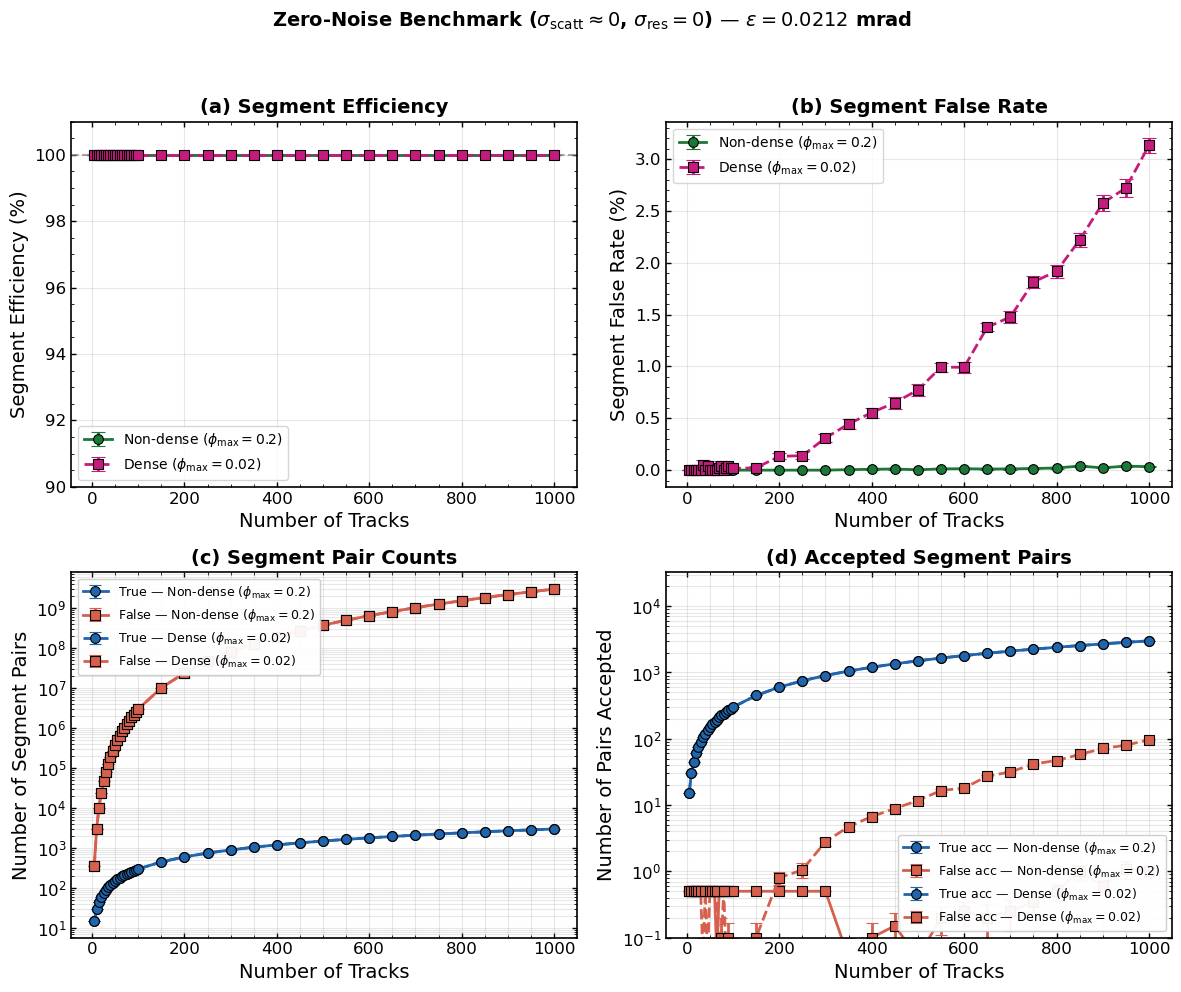

Saved fig13e zero-noise benchmark


In [ ]:
# ============================================================================
# 13e. Zero-Noise Benchmark (up to 1000 tracks)
# ============================================================================
_cache_file = CACHE_DIR / "df_zero_noise_ext.csv"
if _cache_file.exists():
    df_zero_ext = pd.read_csv(_cache_file)
    print(f"Loaded zero-noise cache: {len(df_zero_ext)} rows")
else:
    import time as _time
    rows = []
    _t0 = _time.time()
    label_seed_offset = {"dense": 0, "non_dense": 1}
    for label, phi_max in ZERO_CONE_SETTINGS.items():
        for n_trk in ZERO_TRACK_COUNTS_EXT:
            for rep in range(ZERO_N_REPEATS_EXT):
                np.random.seed(rep + n_trk * 100
                               + label_seed_offset[label] * 10000 + 900000)
                event = safe_generate(n_trk, measurement_error=ZERO_SIGMA_RES_EXT,
                                      collision_noise=ZERO_SIGMA_SCATT_EXT,
                                      phi_max=phi_max, theta_max=phi_max)
                m = fast_segment_metrics(event, epsilon_zero_ext)
                rows.append({
                    "regime": label,
                    "phi_max": phi_max,
                    "n_tracks": n_trk,
                    "repeat": rep,
                    "epsilon": epsilon_zero_ext,
                    **m,
                })
            if n_trk % 100 == 0:
                print(f"  zero-noise: {label}, n_trk={n_trk} done "
                      f"({_time.time()-_t0:.0f}s)")
    df_zero_ext = pd.DataFrame(rows)
    df_zero_ext.to_csv(_cache_file, index=False)
    print(f"Saved zero-noise cache: {len(df_zero_ext)} rows "
          f"({_time.time()-_t0:.0f}s)")

# ── Plot ──
zn_colors = {"non_dense": '#1b7837', "dense": '#c51b7d'}
zn_fmts   = {"non_dense": 'o-',     "dense": 's--'}
zn_labels = {"non_dense": r'Non-dense ($\phi_{\max}=0.2$)',
             "dense":     r'Dense ($\phi_{\max}=0.02$)'}

zn_agg = {}
for regime in ["non_dense", "dense"]:
    sub = df_zero_ext[df_zero_ext["regime"] == regime]
    agg = sub.groupby("n_tracks").agg(
        eff_mean=("segment_efficiency", "mean"),
        eff_se=("segment_efficiency", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        fr_mean=("segment_false_rate", "mean"),
        fr_se=("segment_false_rate", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        nt_mean=("n_true", "mean"),
        nt_se=("n_true", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        nf_mean=("n_false", "mean"),
        nf_se=("n_false", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        ta_mean=("true_accepted", "mean"),
        ta_se=("true_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        fa_mean=("false_accepted", "mean"),
        fa_se=("false_accepted", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    zn_agg[regime] = agg

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

color_true_zn  = '#2166ac'
color_false_zn = '#d6604d'

ax1 = axes[0, 0]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    ax1.errorbar(d.index, d["eff_mean"] * 100, yerr=d["eff_se"] * 100,
                 fmt=zn_fmts[regime], color=zn_colors[regime], capsize=5,
                 capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                 label=zn_labels[regime])
ax1.axhline(100, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.set_ylabel('Segment Efficiency (%)')
ax1.set_title('(a) Segment Efficiency', fontweight='bold')
ax1.set_ylim(90, 101)
ax1.legend(fontsize=10, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)

ax2 = axes[0, 1]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    ax2.errorbar(d.index, d["fr_mean"] * 100, yerr=d["fr_se"] * 100,
                 fmt=zn_fmts[regime], color=zn_colors[regime], capsize=5,
                 capthick=1.5, markeredgecolor='black', markeredgewidth=0.8,
                 label=zn_labels[regime])
ax2.set_ylabel('Segment False Rate (%)')
ax2.set_title('(b) Segment False Rate', fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)

ax3 = axes[1, 0]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    style = '-' if regime == "non_dense" else '--'
    ax3.errorbar(d.index, d["nt_mean"], yerr=d["nt_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'True — {zn_labels[regime]}')
    ax3.errorbar(d.index, d["nf_mean"], yerr=d["nf_se"],
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'False — {zn_labels[regime]}')
ax3.set_yscale('log')
ax3.set_ylabel('Number of Segment Pairs')
ax3.set_title('(c) Segment Pair Counts', fontweight='bold')
ax3.legend(loc='upper left', framealpha=0.95, fontsize=9)
ax3.grid(True, alpha=0.3, which='both')
ax3.minorticks_on()
ax3.tick_params(which='both', direction='in', top=True, right=True)

ax4 = axes[1, 1]
for regime in ["non_dense", "dense"]:
    d = zn_agg[regime]
    style = '-' if regime == "non_dense" else '--'
    ax4.errorbar(d.index, d["ta_mean"], yerr=d["ta_se"],
                 fmt='o' + style, color=color_true_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'True acc — {zn_labels[regime]}')
    fa_p = np.where(d["fa_mean"] > 0, d["fa_mean"], 0.5)
    fa_s = np.where(d["fa_mean"] > 0, d["fa_se"], 0)
    ax4.errorbar(d.index, fa_p, yerr=fa_s,
                 fmt='s' + style, color=color_false_zn, capsize=4, capthick=1.2,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label=f'False acc — {zn_labels[regime]}')
ax4.set_yscale('log')
ax4.set_ylabel('Number of Pairs Accepted')
ax4.set_title('(d) Accepted Segment Pairs', fontweight='bold')
ax4.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax4.grid(True, alpha=0.3, which='both')
ax4.minorticks_on()
ax4.tick_params(which='both', direction='in', top=True, right=True)
ax4.set_ylim(0.1, None)

for ax in axes.flat:
    ax.set_xlabel('Number of Tracks')

fig.suptitle(r"Zero-Noise Benchmark ($\sigma_{\mathrm{scatt}} \approx 0$, "
             r"$\sigma_{\mathrm{res}} = 0$)"
             rf" — $\varepsilon = {epsilon_zero_ext*1e3:.4f}$ mrad",
             fontsize=14, fontweight='bold', y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(PAPER_DIR / 'fig13e_zero_noise.pdf',
            format='pdf', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(PAPER_DIR / 'fig13e_zero_noise.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig13e zero-noise benchmark")

In [ ]:
# ============================================================================
# 13f. Paper Figures Summary
# ============================================================================
print("=" * 60)
print("PAPER FIGURES (§13)")
print("=" * 60)
for f in sorted(PAPER_DIR.glob("fig13*")):
    print(f"  {f.name:50s} ({f.stat().st_size / 1024:.1f} KB)")
print(f"\nTotal: {len(list(PAPER_DIR.glob('fig13*')))} files in {PAPER_DIR}/")

PAPER FIGURES (§13)
  fig13a_scattering_sweep_phi0p02.pdf                (58.4 KB)
  fig13a_scattering_sweep_phi0p02.png                (603.7 KB)
  fig13a_scattering_sweep_phi0p2.pdf                 (58.4 KB)
  fig13a_scattering_sweep_phi0p2.png                 (541.2 KB)
  fig13b_resolution_sweep_phi0p02.pdf                (59.8 KB)
  fig13b_resolution_sweep_phi0p02.png                (521.0 KB)
  fig13b_resolution_sweep_phi0p2.pdf                 (59.4 KB)
  fig13b_resolution_sweep_phi0p2.png                 (550.1 KB)
  fig13c_density_scan.pdf                            (42.5 KB)
  fig13c_density_scan.png                            (392.7 KB)
  fig13d_fixed_epsilon.pdf                           (50.1 KB)
  fig13d_fixed_epsilon.png                           (488.5 KB)
  fig13e_zero_noise.pdf                              (64.1 KB)
  fig13e_zero_noise.png                              (602.9 KB)

Total: 14 files in outputs/segment_analysis/paper/
